In [ ]:
# ============================================================
# MULTIMODAL HALLUCINATION FIREWALL
# CELL 1 — PROJECT SETUP & DATASET DISCOVERY
# ============================================================

import os
import sys
import json
import glob
import shutil
import warnings

warnings.filterwarnings("ignore")

print("=" * 80)
print("MULTIMODAL HALLUCINATION FIREWALL")
print("PROJECT INITIALIZATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. PROJECT DIRECTORIES
# ------------------------------------------------------------

PROJECT_DIR = "/content/Hallucination_Firewall"

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "outputs"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models"
)

for directory in [
    PROJECT_DIR,
    DATA_DIR,
    OUTPUT_DIR,
    MODEL_DIR
]:

    os.makedirs(
        directory,
        exist_ok=True
    )


# ------------------------------------------------------------
# 2. BASIC ENVIRONMENT INFORMATION
# ------------------------------------------------------------

print("\nPROJECT DIRECTORY:")
print(PROJECT_DIR)

print("\nPython version:")
print(sys.version)

try:

    import pandas as pd
    import numpy as np
    import sklearn

    print("\nInstalled packages:")
    print("✓ pandas:", pd.__version__)
    print("✓ numpy:", np.__version__)
    print("✓ scikit-learn:", sklearn.__version__)

except Exception as e:

    print("Package check error:", e)


# ------------------------------------------------------------
# 3. SEARCH / CONTENT DISCOVERY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CHECKING /content FOR EXISTING DATA")
print("=" * 80)

important_extensions = (
    ".csv",
    ".json",
    ".jsonl",
    ".zip"
)

found_files = []

for root, dirs, files in os.walk("/content"):

    # Ignore our output directory
    if PROJECT_DIR in root:
        continue

    for file in files:

        if file.lower().endswith(
            important_extensions
        ):

            full_path = os.path.join(
                root,
                file
            )

            found_files.append(
                full_path
            )


if found_files:

    print(
        f"\nFound {len(found_files)} relevant files:\n"
    )

    for path in found_files[:100]:

        size_kb = (
            os.path.getsize(path) / 1024
        )

        print(
            f"✓ {path}  "
            f"({size_kb:.1f} KB)"
        )

else:

    print(
        "\nNo existing dataset files found."
    )


# ------------------------------------------------------------
# 4. CHECK GOOGLE DRIVE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GOOGLE DRIVE")
print("=" * 80)

try:

    from google.colab import drive

    print(
        "Drive can be mounted when required."
    )

except:

    print(
        "Not running inside Google Colab."
    )


# ------------------------------------------------------------
# 5. PROJECT PLAN
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PROJECT PIPELINE")
print("=" * 80)

pipeline = [

    "01 — Dataset acquisition",
    "02 — Dataset verification",
    "03 — Ground-truth label recovery",
    "04 — Multimodal dataframe construction",
    "05 — Feature engineering",
    "06 — Feature analysis",
    "07 — ML model training",
    "08 — Model comparison",
    "09 — Best-model evaluation",
    "10 — Hallucination Firewall",
    "11 — Model saving",
    "12 — Results and visualizations",
    "13 — Project documentation"

]

for step in pipeline:

    print("→", step)


print("\n" + "=" * 80)
print("✅ CELL 1 COMPLETE")
print("=" * 80)

print("""
IMPORTANT:

We are NOT assuming any dataset path yet.

The next cell will determine exactly what dataset
we have and where it is located before we write
any feature or ML code.

This prevents the previous path/label problems.
""")

MULTIMODAL HALLUCINATION FIREWALL
PROJECT INITIALIZATION

PROJECT DIRECTORY:
/content/Hallucination_Firewall

Python version:
3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

Installed packages:
✓ pandas: 2.2.3
✓ numpy: 2.1.3
✓ scikit-learn: 1.6.1

CHECKING /content FOR EXISTING DATA

Found 6 relevant files:

✓ /content/.config/.last_update_check.json  (0.1 KB)
✓ /content/sample_data/anscombe.json  (1.7 KB)
✓ /content/sample_data/mnist_test.csv  (17860.8 KB)
✓ /content/sample_data/mnist_train_small.csv  (35667.9 KB)
✓ /content/sample_data/california_housing_train.csv  (1666.4 KB)
✓ /content/sample_data/california_housing_test.csv  (294.1 KB)

GOOGLE DRIVE
Drive can be mounted when required.

PROJECT PIPELINE
→ 01 — Dataset acquisition
→ 02 — Dataset verification
→ 03 — Ground-truth label recovery
→ 04 — Multimodal dataframe construction
→ 05 — Feature engineering
→ 06 — Feature analysis
→ 07 — ML model training
→ 08 — Model comparison
→ 09 — Best-model evaluation
→ 10 — Hallucinatio

In [ ]:
# ============================================================
# CELL 2 — DOWNLOAD POPE DATASET
# ============================================================

import os
import subprocess
import shutil

print("=" * 80)
print("DOWNLOADING POPE DATASET")
print("=" * 80)

POPE_DIR = "/content/POPE"

# Remove incomplete previous copy if one exists
if os.path.exists(POPE_DIR):
    print("\nExisting POPE folder found.")
    print("Removing it so we start clean...")
    shutil.rmtree(POPE_DIR)

# Clone the official POPE repository
repo_url = "https://github.com/RUCAIBox/POPE.git"

print("\nCloning:")
print(repo_url)

result = subprocess.run(
    [
        "git",
        "clone",
        "--depth",
        "1",
        repo_url,
        POPE_DIR
    ],
    capture_output=True,
    text=True
)

if result.returncode != 0:

    print("\n❌ DOWNLOAD FAILED")
    print(result.stderr)

    raise RuntimeError(
        "POPE repository could not be downloaded."
    )

print("\n✅ POPE repository downloaded successfully.")


# ------------------------------------------------------------
# SHOW DIRECTORY STRUCTURE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("POPE DIRECTORY CONTENTS")
print("=" * 80)

for root, dirs, files in os.walk(POPE_DIR):

    level = root.replace(
        POPE_DIR,
        ""
    ).count(os.sep)

    if level > 3:
        continue

    indent = "  " * level

    print(
        f"{indent}{os.path.basename(root)}/"
    )

    for file in files[:20]:

        print(
            f"{indent}  {file}"
        )


# ------------------------------------------------------------
# FIND DATA FILES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SEARCHING FOR DATA FILES")
print("=" * 80)

extensions = (
    ".json",
    ".jsonl",
    ".csv",
    ".zip"
)

data_files = []

for root, dirs, files in os.walk(POPE_DIR):

    for file in files:

        if file.lower().endswith(extensions):

            path = os.path.join(
                root,
                file
            )

            size_mb = (
                os.path.getsize(path)
                / (1024 * 1024)
            )

            data_files.append(path)

            print(
                f"✓ {path} "
                f"({size_mb:.2f} MB)"
            )


print("\n" + "=" * 80)
print("DOWNLOAD CHECK")
print("=" * 80)

print(
    "Files discovered:",
    len(data_files)
)

if len(data_files) == 0:

    raise RuntimeError(
        "No dataset files were found."
    )

print(
    "\n✅ CELL 2 COMPLETE"
)

print("""
IMPORTANT:
Do not create any features yet.

The next cell will inspect the downloaded files
and determine exactly which files contain:

1. Images / image identifiers
2. Questions
3. Answers
4. Genuine Yes/No ground-truth labels

We will use those actual files instead of assuming
their names or paths.
""")


DOWNLOADING POPE DATASET

Cloning:
https://github.com/RUCAIBox/POPE.git

✅ POPE repository downloaded successfully.

POPE DIRECTORY CONTENTS
POPE/
  LICENSE
  requirements.txt
  main.py
  utils.py
  evaluate.py
  README.md
  output/
    seem/
      gqa/
        gqa_pope_seem_random.json
        gqa_pope_seem_adversarial.json
        gqa_pope_seem_popular.json
      aokvqa/
        aokvqa_pope_seem_random.json
        aokvqa_pope_seem_popular.json
        aokvqa_pope_seem_adversarial.json
    coco/
      coco_pope_adversarial.json
      coco_pope_random.json
      coco_pope_popular.json
  answer/
    example.json
  seem/
    seem_focall_v1.pt
    seg.py
    interactive.py
    xdecoder/
      __init__.py
      BaseModel.py
      body/
        build.py
        xdecoder_head.py
        registry.py
        __init__.py
        transformer_blocks.py
      backbone/
        resnet.py
        focal.py
        focal_dw.py
        davit.py
        build.py
        registry.py
        __init__.py


In [ ]:
# ============================================================
# CELL 3 — POPE DATASET INSPECTION & LABEL DISCOVERY
# ============================================================

import os
import json
import pandas as pd

POPE_DIR = "/content/POPE"

print("=" * 90)
print("CELL 3 — POPE DATASET INSPECTION")
print("=" * 90)


# ------------------------------------------------------------
# 1. FIND ALL DATA FILES
# ------------------------------------------------------------

extensions = (
    ".json",
    ".jsonl",
    ".csv"
)

files = []

for root, dirs, filenames in os.walk(POPE_DIR):

    for filename in filenames:

        if filename.lower().endswith(extensions):

            files.append(
                os.path.join(root, filename)
            )


print("\nDATA FILES FOUND:", len(files))

for i, path in enumerate(files, 1):

    size_kb = os.path.getsize(path) / 1024

    print(
        f"{i}. {path} "
        f"({size_kb:.1f} KB)"
    )


# ------------------------------------------------------------
# 2. INSPECT JSON / JSONL STRUCTURE
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("JSON STRUCTURE INSPECTION")
print("=" * 90)

for path in files:

    if not path.lower().endswith(
        (".json", ".jsonl")
    ):
        continue

    print("\n" + "-" * 90)
    print("FILE:", path)
    print("-" * 90)

    try:

        if path.lower().endswith(".json"):

            with open(
                path,
                "r",
                encoding="utf-8"
            ) as f:

                obj = json.load(f)

            print(
                "Top-level type:",
                type(obj).__name__
            )

            if isinstance(obj, list):

                print(
                    "Number of records:",
                    len(obj)
                )

                if len(obj) > 0:

                    first = obj[0]

                    if isinstance(first, dict):

                        print(
                            "First record keys:",
                            list(first.keys())
                        )

                        print(
                            "First record:"
                        )

                        print(
                            json.dumps(
                                first,
                                indent=2,
                                ensure_ascii=False
                            )[:2000]
                        )

            elif isinstance(obj, dict):

                print(
                    "Top-level keys:",
                    list(obj.keys())
                )

                # Inspect nested lists
                for key, value in obj.items():

                    if isinstance(value, list):

                        print(
                            f"  {key}: list with "
                            f"{len(value)} records"
                        )

                        if value:

                            if isinstance(
                                value[0],
                                dict
                            ):

                                print(
                                    "  First record keys:",
                                    list(
                                        value[0].keys()
                                    )
                                )

        else:

            # JSONL
            records = []

            with open(
                path,
                "r",
                encoding="utf-8"
            ) as f:

                for line in f:

                    line = line.strip()

                    if line:

                        records.append(
                            json.loads(line)
                        )

                        if len(records) >= 3:
                            break

            print(
                "Sample records:",
                len(records)
            )

            for record in records:

                print(
                    json.dumps(
                        record,
                        indent=2,
                        ensure_ascii=False
                    )[:1000]
                )

    except Exception as e:

        print(
            "⚠️ Could not inspect:",
            str(e)
        )


# ------------------------------------------------------------
# 3. INSPECT CSV FILES
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("CSV STRUCTURE INSPECTION")
print("=" * 90)

for path in files:

    if not path.lower().endswith(".csv"):
        continue

    print("\n" + "-" * 90)
    print("FILE:", path)
    print("-" * 90)

    try:

        temp = pd.read_csv(
            path,
            nrows=5
        )

        print(
            "Columns:",
            list(temp.columns)
        )

        print(
            "Sample shape:",
            temp.shape
        )

        print(
            temp.head()
        )

    except Exception as e:

        print(
            "⚠️ Could not read:",
            str(e)
        )


# ------------------------------------------------------------
# 4. SEARCH FILENAMES FOR LABEL / ANNOTATION FILES
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("POTENTIAL GROUND-TRUTH FILES")
print("=" * 90)

keywords = [
    "annotation",
    "annot",
    "label",
    "pope",
    "question",
    "answer"
]

candidates = []

for path in files:

    name = os.path.basename(path).lower()

    if any(
        keyword in name
        for keyword in keywords
    ):

        candidates.append(path)

        print(
            "✓",
            path
        )


# ------------------------------------------------------------
# 5. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("✅ CELL 3 COMPLETE")
print("=" * 90)

print("""
DO NOT CREATE FEATURES OR TRAIN A MODEL YET.

We first need to confirm the actual:
• image identifier
• question
• answer
• ground-truth label

from the files that were really downloaded.

Send me the output of this cell.
""")

CELL 3 — POPE DATASET INSPECTION

DATA FILES FOUND: 22
1. /content/POPE/output/seem/gqa/gqa_pope_seem_random.json (430.9 KB)
2. /content/POPE/output/seem/gqa/gqa_pope_seem_adversarial.json (429.5 KB)
3. /content/POPE/output/seem/gqa/gqa_pope_seem_popular.json (428.1 KB)
4. /content/POPE/output/seem/aokvqa/aokvqa_pope_seem_random.json (484.2 KB)
5. /content/POPE/output/seem/aokvqa/aokvqa_pope_seem_popular.json (481.1 KB)
6. /content/POPE/output/seem/aokvqa/aokvqa_pope_seem_adversarial.json (482.5 KB)
7. /content/POPE/output/coco/coco_pope_adversarial.json (361.7 KB)
8. /content/POPE/output/coco/coco_pope_random.json (359.5 KB)
9. /content/POPE/output/coco/coco_pope_popular.json (361.5 KB)
10. /content/POPE/answer/example.json (0.1 KB)
11. /content/POPE/POPEv2/dataset/annotations.json (201.1 KB)
12. /content/POPE/caption_data/Instruction2_mplug.json (974.4 KB)
13. /content/POPE/caption_data/Instruction1_llava.json (1503.4 KB)
14. /content/POPE/caption_data/Instruction2_minigpt-4.json (45

In [ ]:
# ============================================================
# CELL 4 — BUILD CLEAN POPEv2 BASE DATASET
# ============================================================

import os
import json
import pandas as pd
import numpy as np

print("=" * 90)
print("CELL 4 — BUILDING CLEAN POPEv2 DATASET")
print("=" * 90)

# ------------------------------------------------------------
# 1. LOAD OFFICIAL POPEv2 ANNOTATIONS
# ------------------------------------------------------------

ANNOTATION_FILE = "/content/POPE/POPEv2/dataset/annotations.json"

with open(
    ANNOTATION_FILE,
    "r",
    encoding="utf-8"
) as f:
    annotations = json.load(f)

df = pd.DataFrame(annotations)

print("\nOriginal dataset shape:")
print(df.shape)

print("\nOriginal columns:")
print(list(df.columns))


# ------------------------------------------------------------
# 2. RENAME COLUMNS FOR OUR PROJECT
# ------------------------------------------------------------

df = df.rename(
    columns={
        "query": "question",
        "target_object": "target"
    }
)

# ------------------------------------------------------------
# 3. NORMALIZE LABELS
# ------------------------------------------------------------

df["label"] = (
    df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Convert:
# No  -> 0 = hallucinated/unsupported object
# Yes -> 1 = grounded/correct object

label_mapping = {
    "no": 0,
    "yes": 1
}

df["label_binary"] = df["label"].map(
    label_mapping
)


# ------------------------------------------------------------
# 4. VALIDATE LABELS
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("LABEL VALIDATION")
print("=" * 90)

print("\nOriginal labels:")
print(df["label"].value_counts())

invalid = df["label_binary"].isna().sum()

print(
    "\nInvalid labels:",
    invalid
)

if invalid > 0:

    raise ValueError(
        "Invalid/unrecognized labels detected."
    )


# ------------------------------------------------------------
# 5. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("MISSING VALUE CHECK")
print("=" * 90)

print(
    df.isna().sum()
)


# ------------------------------------------------------------
# 6. CHECK DUPLICATES
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("DUPLICATE CHECK")
print("=" * 90)

duplicates = df.duplicated().sum()

print(
    "Duplicate rows:",
    duplicates
)


# ------------------------------------------------------------
# 7. CHECK IMAGE IDS
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("IMAGE INFORMATION")
print("=" * 90)

print(
    "Total records:",
    len(df)
)

print(
    "Unique images:",
    df["image_id"].nunique()
)

print(
    "Unique target objects:",
    df["target"].nunique()
)


# ------------------------------------------------------------
# 8. CREATE IMAGE FILENAME
# ------------------------------------------------------------

df["image_filename"] = (
    df["image_id"]
    .astype(int)
    .apply(
        lambda x:
        f"COCO_val2014_{x:012d}.jpg"
    )
)


# ------------------------------------------------------------
# 9. CREATE QUESTION TEXT
# ------------------------------------------------------------

df["question_text"] = (
    df["question"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 10. SHOW SAMPLE
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("FIRST 10 RECORDS")
print("=" * 90)

print(
    df[
        [
            "image_id",
            "image_filename",
            "target",
            "question_text",
            "label"
        ]
    ].head(10).to_string(index=False)
)


# ------------------------------------------------------------
# 11. LABEL DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("FINAL LABEL DISTRIBUTION")
print("=" * 90)

distribution = (
    df["label"]
    .value_counts()
)

print(distribution)

print("\nPercentages:")

print(
    (
        df["label"]
        .value_counts(
            normalize=True
        )
        * 100
    ).round(2)
)


# ------------------------------------------------------------
# 12. SAVE CLEAN DATASET
# ------------------------------------------------------------

BASE_DATASET = (
    "/content/Hallucination_Firewall/"
    "data/popev2_clean.csv"
)

df.to_csv(
    BASE_DATASET,
    index=False
)

print("\nSaved:")
print(BASE_DATASET)


# ------------------------------------------------------------
# 13. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("✅ CELL 4 COMPLETE")
print("=" * 90)

print(
    "Dataset shape:",
    df.shape
)

print(
    "Columns:",
    list(df.columns)
)

print("""
The genuine POPEv2 Yes/No labels are now safely stored.

No artificial labels were created.

NEXT:
We need the actual images corresponding to image_id.
""")

CELL 4 — BUILDING CLEAN POPEv2 DATASET

Original dataset shape:
(1000, 5)

Original columns:
['image_id', 'image_name', 'target_object', 'query', 'label']

LABEL VALIDATION

Original labels:
label
no     500
yes    500
Name: count, dtype: int64

Invalid labels: 0

MISSING VALUE CHECK
image_id        0
image_name      0
target          0
question        0
label           0
label_binary    0
dtype: int64

DUPLICATE CHECK
Duplicate rows: 0

IMAGE INFORMATION
Total records: 1000
Unique images: 500
Unique target objects: 80

FIRST 10 RECORDS
 image_id                image_filename   target                     question_text label
    46207 COCO_val2014_000000046207.jpg   remote   Is there a remote in the image?    no
    46207 COCO_val2014_000000046207.jpg   remote   Is there a remote in the image?   yes
   489255 COCO_val2014_000000489255.jpg    pizza    Is there a pizza in the image?    no
   489255 COCO_val2014_000000489255.jpg    pizza    Is there a pizza in the image?   yes
    88567 CO

In [ ]:
# ============================================================
# CELL 5 — DATASET SANITY CHECK
# ============================================================

print("=" * 90)
print("CELL 5 — DATASET SANITY CHECK")
print("=" * 90)

print("\nDataset shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\nLabel mapping:")
print("Yes =", 1)
print("No  =", 0)

print("\nLabel counts:")
print(
    df["label_binary"]
    .value_counts()
    .sort_index()
)

print("\nUnique images:")
print(
    df["image_id"].nunique()
)

print("\nUnique target objects:")
print(
    df["target"].nunique()
)

print("\nExample records:")
print(
    df[
        [
            "image_id",
            "target",
            "question_text",
            "label"
        ]
    ].head(10)
)

# Basic assertions
assert len(df) == 1000
assert df["label_binary"].notna().all()
assert set(df["label"].unique()) <= {"yes", "no"}

print("\n" + "=" * 90)
print("✅ DATASET PASSED BASIC SANITY CHECK")
print("=" * 90)

CELL 5 — DATASET SANITY CHECK

Dataset shape: (1000, 8)

Columns:
1. image_id
2. image_name
3. target
4. question
5. label
6. label_binary
7. image_filename
8. question_text

Label mapping:
Yes = 1
No  = 0

Label counts:
label_binary
0    500
1    500
Name: count, dtype: int64

Unique images:
500

Unique target objects:
80

Example records:
   image_id    target                      question_text label
0     46207    remote    Is there a remote in the image?    no
1     46207    remote    Is there a remote in the image?   yes
2    489255     pizza     Is there a pizza in the image?    no
3    489255     pizza     Is there a pizza in the image?   yes
4     88567  umbrella  Is there a umbrella in the image?    no
5     88567  umbrella  Is there a umbrella in the image?   yes
6    311612    laptop    Is there a laptop in the image?    no
7    311612    laptop    Is there a laptop in the image?   yes
8     48900    laptop    Is there a laptop in the image?    no
9     48900    laptop    Is

In [ ]:
import os

print("=" * 80)
print("CHECKING POPE DATASET")
print("=" * 80)

paths_to_check = [
    "/content/POPE",
    "/content/POPE/POPEv2",
    "/content/POPE/POPEv2/dataset",
    "/content/POPE/POPEv2/dataset/annotations.json",
]

for path in paths_to_check:
    print(
        "✓" if os.path.exists(path) else "✗",
        path
    )

print("\nSearching /content for annotations.json...")

matches = []

for root, dirs, files in os.walk("/content"):
    if "annotations.json" in files:
        matches.append(os.path.join(root, "annotations.json"))

if matches:
    print("\nFOUND:")
    for m in matches:
        print("✓", m)
else:
    print("\n❌ annotations.json was not found anywhere under /content")

CHECKING POPE DATASET
✗ /content/POPE
✗ /content/POPE/POPEv2
✗ /content/POPE/POPEv2/dataset
✗ /content/POPE/POPEv2/dataset/annotations.json

Searching /content for annotations.json...

❌ annotations.json was not found anywhere under /content


In [ ]:
# ============================================================
# RESTORE POPE DATASET — GOOGLE DRIVE CHECK
# ============================================================

import os
import shutil

print("=" * 80)
print("POPE DATASET RESTORATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. MOUNT GOOGLE DRIVE
# ------------------------------------------------------------

from google.colab import drive

print("\nMounting Google Drive...")
drive.mount("/content/drive")

print("✓ Google Drive mounted")

# ------------------------------------------------------------
# 2. SEARCH GOOGLE DRIVE FOR POPE FILES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SEARCHING GOOGLE DRIVE")
print("=" * 80)

annotation_matches = []
image_zip_matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):

    # Avoid unnecessary hidden/system folders
    dirs[:] = [
        d for d in dirs
        if not d.startswith(".")
    ]

    for file in files:

        if file.lower() == "annotations.json":
            annotation_matches.append(
                os.path.join(root, file)
            )

        if file.lower() == "images.zip":
            image_zip_matches.append(
                os.path.join(root, file)
            )

print("\nannotations.json found:", len(annotation_matches))

for path in annotation_matches[:20]:
    print("✓", path)

print("\nimages.zip found:", len(image_zip_matches))

for path in image_zip_matches[:20]:
    print("✓", path)

# ------------------------------------------------------------
# 3. REPORT RESULT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESTORATION CHECK")
print("=" * 80)

if annotation_matches:
    print("✓ POPE annotations found in Google Drive")
else:
    print("❌ annotations.json NOT found in Google Drive")

if image_zip_matches:
    print("✓ POPE image archive found in Google Drive")
else:
    print("❌ images.zip NOT found in Google Drive")

print("\nDO NOT RUN CELL 6 YET.")
print("Send me this output.")

POPE DATASET RESTORATION

Mounting Google Drive...
Mounted at /content/drive
✓ Google Drive mounted

SEARCHING GOOGLE DRIVE

annotations.json found: 0

images.zip found: 0

RESTORATION CHECK
❌ annotations.json NOT found in Google Drive
❌ images.zip NOT found in Google Drive

DO NOT RUN CELL 6 YET.
Send me this output.


In [ ]:
# ============================================================
# STEP 1 — CHECK WHAT DATA WE ACTUALLY HAVE
# ============================================================

import os

print("=" * 70)
print("CHECKING CURRENT COLAB ENVIRONMENT")
print("=" * 70)

print("\nPOPE-related files currently available:")

found = []

for root, dirs, files in os.walk("/content"):
    # Ignore unnecessary system folders
    dirs[:] = [d for d in dirs if d not in [
        ".config", "sample_data"
    ]]

    for file in files:
        if any(x in file.lower() for x in [
            "pope",
            "annotation",
            "image"
        ]):
            path = os.path.join(root, file)
            found.append(path)

if found:
    for path in found:
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✓ {path} ({size_mb:.2f} MB)")
else:
    print("❌ No POPE/annotation/image files found.")

print("\n" + "=" * 70)
print("CHECK COMPLETE")
print("=" * 70)

CHECKING CURRENT COLAB ENVIRONMENT

POPE-related files currently available:
❌ No POPE/annotation/image files found.

CHECK COMPLETE


In [ ]:
# ============================================================
# CELL 5 — POPE DATASET NORMALIZATION
# ============================================================

import os
import json
import re
import pandas as pd

print("=" * 80)
print("CELL 5 — POPE DATASET NORMALIZATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. POPE FILE
# ------------------------------------------------------------

POPE_FILE = "/content/POPE/output/coco/coco_pope_popular.json"

if not os.path.exists(POPE_FILE):
    raise FileNotFoundError(
        f"POPE file not found:\n{POPE_FILE}"
    )

print("\n✓ POPE file found:")
print(POPE_FILE)


# ------------------------------------------------------------
# 2. READ JSONL
# ------------------------------------------------------------

records = []

with open(POPE_FILE, "r", encoding="utf-8") as f:

    for line_number, line in enumerate(f, start=1):

        line = line.strip()

        if not line:
            continue

        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            raise ValueError(
                f"Invalid JSON at line {line_number}: {e}"
            )

pope_df = pd.DataFrame(records)

print("\n✓ POPE JSONL loaded")
print("Total records:", len(pope_df))

print("\nOriginal columns:")
print(list(pope_df.columns))


# ------------------------------------------------------------
# 3. VERIFY ACTUAL POPE FORMAT
# ------------------------------------------------------------

required = [
    "question_id",
    "image",
    "text",
    "label"
]

missing = [
    col for col in required
    if col not in pope_df.columns
]

if missing:
    raise ValueError(
        f"Missing POPE columns: {missing}"
    )

print("\n✓ Required POPE columns confirmed")


# ------------------------------------------------------------
# 4. CREATE PROJECT DIRECTORY
# ------------------------------------------------------------

PROJECT_DIR = "/content/Hallucination_Firewall"

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)

os.makedirs(DATA_DIR, exist_ok=True)


# ------------------------------------------------------------
# 5. NORMALIZE IMAGE INFORMATION
# ------------------------------------------------------------

# POPE uses image names such as:
# 000000046207.jpg

pope_df["image_filename"] = (
    pope_df["image"]
    .astype(str)
    .apply(os.path.basename)
)

# Extract numeric image ID
pope_df["image_id_numeric"] = (
    pope_df["image_filename"]
    .str.extract(r"(\d+)", expand=False)
)

# Keep image ID as string so leading zeros are preserved
pope_df["image_id"] = pope_df["image_id_numeric"]


# ------------------------------------------------------------
# 6. NORMALIZE QUESTION
# ------------------------------------------------------------

pope_df["question"] = pope_df["text"].astype(str)


# ------------------------------------------------------------
# 7. EXTRACT TARGET OBJECT FROM QUESTION
# ------------------------------------------------------------

def extract_target_object(question):

    question = str(question).strip()

    patterns = [
        r"Is there a (.+?) in the image\?",
        r"Is there an (.+?) in the image\?",
        r"Are there any (.+?) in the image\?",
        r"Does the image contain (.+?)\?",
        r"Does the image have (.+?)\?"
    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            question,
            flags=re.IGNORECASE
        )

        if match:
            return match.group(1).strip()

    return "unknown"


pope_df["target_object"] = pope_df["question"].apply(
    extract_target_object
)


# ------------------------------------------------------------
# 8. ANSWER FIELD
# ------------------------------------------------------------

# For this POPE dataset, the textual object being queried
# is used as the answer/object representation required by
# our multimodal feature pipeline.

pope_df["answer"] = pope_df["target_object"]


# ------------------------------------------------------------
# 9. NORMALIZE LABEL
# ------------------------------------------------------------

pope_df["label"] = (
    pope_df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

label_mapping = {
    "no": 0,
    "yes": 1
}

pope_df["label_binary"] = pope_df["label"].map(
    label_mapping
)

if pope_df["label_binary"].isna().any():

    unknown_labels = (
        pope_df.loc[
            pope_df["label_binary"].isna(),
            "label"
        ]
        .unique()
    )

    raise ValueError(
        f"Unknown labels found: {unknown_labels}"
    )


# ------------------------------------------------------------
# 10. CREATE IMAGE PATH
# ------------------------------------------------------------

# Images will eventually be stored here.
# We are NOT pretending they exist yet.

IMAGE_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "raw_images",
    "images"
)

pope_df["image_path"] = pope_df[
    "image_filename"
].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)


# ------------------------------------------------------------
# 11. DISPLAY DATASET INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("NORMALIZED POPE DATASET")
print("=" * 80)

print("\nTotal records:")
print(len(pope_df))

print("\nUnique images:")
print(pope_df["image_id"].nunique())

print("\nLabel distribution:")
print(
    pope_df["label_binary"]
    .value_counts()
    .sort_index()
)

print("\nOriginal labels:")
print(
    pope_df["label"]
    .value_counts()
)


# ------------------------------------------------------------
# 12. CHECK DUPLICATE IMAGE / LABEL STRUCTURE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("IMAGE / LABEL STRUCTURE CHECK")
print("=" * 80)

image_counts = pope_df.groupby(
    "image_id"
).size()

print("\nRecords per image:")
print(image_counts.value_counts().sort_index())


# ------------------------------------------------------------
# 13. SAMPLE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATASET SAMPLE")
print("=" * 80)

display(
    pope_df[
        [
            "question_id",
            "image_id",
            "image_filename",
            "target_object",
            "question",
            "label",
            "label_binary"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 14. SAVE NORMALIZED DATASET
# ------------------------------------------------------------

NORMALIZED_FILE = os.path.join(
    DATA_DIR,
    "pope_normalized.csv"
)

pope_df.to_csv(
    NORMALIZED_FILE,
    index=False
)

print("\n" + "=" * 80)
print("CELL 5 COMPLETE")
print("=" * 80)

print("\nSaved:")
print(NORMALIZED_FILE)

print("\nIMPORTANT:")
print("✓ POPE annotations are now normalized.")
print("✓ Ground-truth labels come directly from POPE.")
print("✓ No labels were invented.")
print("✓ Image paths are recorded but images have NOT been downloaded yet.")
print("\nDO NOT RUN THE OLD CELL 6 OR CELL 7.")

CELL 5 — POPE DATASET NORMALIZATION

✓ POPE file found:
/content/POPE/output/coco/coco_pope_popular.json

✓ POPE JSONL loaded
Total records: 3000

Original columns:
['question_id', 'image', 'text', 'label']

✓ Required POPE columns confirmed

NORMALIZED POPE DATASET

Total records:
3000

Unique images:
1

Label distribution:
label_binary
0    1500
1    1500
Name: count, dtype: int64

Original labels:
label
yes    1500
no     1500
Name: count, dtype: int64

IMAGE / LABEL STRUCTURE CHECK

Records per image:
3000    1
Name: count, dtype: int64

DATASET SAMPLE


,question_id,image_id,image_filename,target_object,question,label,label_binary
0,1,2014,COCO_val2014_000000310196.jpg,snowboard,Is there a snowboard in the image?,yes,1
1,2,2014,COCO_val2014_000000310196.jpg,dining table,Is there a dining table in the image?,no,0
2,3,2014,COCO_val2014_000000310196.jpg,person,Is there a person in the image?,yes,1
3,4,2014,COCO_val2014_000000310196.jpg,car,Is there a car in the image?,no,0
4,5,2014,COCO_val2014_000000310196.jpg,skis,Is there a skis in the image?,yes,1
5,6,2014,COCO_val2014_000000310196.jpg,chair,Is there a chair in the image?,no,0
6,7,2014,COCO_val2014_000000210789.jpg,truck,Is there a truck in the image?,yes,1
7,8,2014,COCO_val2014_000000210789.jpg,dining table,Is there a dining table in the image?,no,0
8,9,2014,COCO_val2014_000000210789.jpg,person,Is there a person in the image?,yes,1
9,10,2014,COCO_val2014_000000210789.jpg,car,Is there a car in the image?,no,0



CELL 5 COMPLETE

Saved:
/content/Hallucination_Firewall/data/pope_normalized.csv

IMPORTANT:
✓ POPE annotations are now normalized.
✓ Ground-truth labels come directly from POPE.
✓ No labels were invented.
✓ Image paths are recorded but images have NOT been downloaded yet.

DO NOT RUN THE OLD CELL 6 OR CELL 7.


In [ ]:
# ============================================================
# CELL 6 — COCO IMAGE ACQUISITION & VERIFICATION
# ============================================================

import os
import pandas as pd
import requests
from tqdm.auto import tqdm

print("=" * 80)
print("CELL 6 — COCO IMAGE ACQUISITION & VERIFICATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

PROJECT_DIR = "/content/Hallucination_Firewall"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
IMAGE_DIR = os.path.join(DATA_DIR, "raw_images", "images")

os.makedirs(IMAGE_DIR, exist_ok=True)

POPE_FILE = os.path.join(DATA_DIR, "pope_normalized.csv")

print("\nPOPE file:")
print(POPE_FILE)

print("\nImage directory:")
print(IMAGE_DIR)

# ------------------------------------------------------------
# 2. LOAD POPE DATA
# ------------------------------------------------------------

if not os.path.exists(POPE_FILE):
    raise FileNotFoundError(
        f"POPE file not found:\n{POPE_FILE}\n"
        "Run Cell 5 first."
    )

df = pd.read_csv(POPE_FILE)

print("\nPOPE dataset loaded")
print("Shape:", df.shape)

# ------------------------------------------------------------
# 3. CHECK REQUIRED COLUMN
# ------------------------------------------------------------

if "image_filename" not in df.columns:
    raise ValueError(
        "❌ image_filename column is missing from pope_normalized.csv"
    )

print("✓ image_filename column found")

# ------------------------------------------------------------
# 4. GET UNIQUE IMAGE FILENAMES
# ------------------------------------------------------------

image_filenames = (
    df["image_filename"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

print("\nUnique images required:", len(image_filenames))

if len(image_filenames) == 0:
    raise ValueError("❌ No image filenames found.")

# ------------------------------------------------------------
# 5. DOWNLOAD COCO IMAGES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DOWNLOADING COCO VAL2014 IMAGES")
print("=" * 80)

downloaded = 0
already_exists = 0
failed = []

session = requests.Session()

for filename in tqdm(image_filenames, desc="Images"):

    output_path = os.path.join(IMAGE_DIR, filename)

    # Already downloaded
    if os.path.exists(output_path) and os.path.getsize(output_path) > 0:
        already_exists += 1
        continue

    url = (
        "http://images.cocodataset.org/val2014/"
        + filename
    )

    try:
        response = session.get(url, timeout=30)

        if response.status_code == 200:

            with open(output_path, "wb") as f:
                f.write(response.content)

            downloaded += 1

        else:
            failed.append(
                (filename, response.status_code)
            )

    except Exception as e:
        failed.append(
            (filename, str(e))
        )

# ------------------------------------------------------------
# 6. VERIFY DOWNLOADED FILES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("IMAGE DOWNLOAD RESULT")
print("=" * 80)

print("Required images :", len(image_filenames))
print("Already existed  :", already_exists)
print("Downloaded       :", downloaded)
print("Failed           :", len(failed))

# ------------------------------------------------------------
# 7. CHECK ALL FILES
# ------------------------------------------------------------

missing_files = []

for filename in image_filenames:

    path = os.path.join(IMAGE_DIR, filename)

    if not os.path.exists(path):
        missing_files.append(filename)

print("\nMissing images after download:", len(missing_files))

if len(missing_files) > 0:

    print("\nFirst missing images:")
    for filename in missing_files[:20]:
        print(" -", filename)

    raise RuntimeError(
        f"❌ {len(missing_files)} images are still missing. "
        "Do not continue to Cell 7."
    )

# ------------------------------------------------------------
# 8. ADD VERIFIED IMAGE PATH
# ------------------------------------------------------------

df["image_path"] = df["image_filename"].apply(
    lambda x: os.path.join(IMAGE_DIR, str(x))
)

# Verify every path
invalid_paths = df[
    ~df["image_path"].apply(os.path.exists)
]

if len(invalid_paths) > 0:
    raise RuntimeError(
        f"❌ {len(invalid_paths)} POPE records have invalid image paths."
    )

# ------------------------------------------------------------
# 9. SAVE UPDATED DATASET
# ------------------------------------------------------------

df.to_csv(POPE_FILE, index=False)

# ------------------------------------------------------------
# 10. FINAL VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 6 COMPLETE ✓")
print("=" * 80)

print("POPE records       :", len(df))
print("Unique images      :", df["image_filename"].nunique())
print("Verified image paths:", df["image_path"].notna().sum())

print("\nImage directory:")
print(IMAGE_DIR)

print("\nSample:")
display(
    df[
        [
            "question_id",
            "image_id",
            "image_filename",
            "target_object",
            "question",
            "label",
            "label_binary",
            "image_path"
        ]
    ].head(10)
)

print("\n✓ All required COCO images are available.")
print("✓ Ground-truth labels remain unchanged.")
print("✓ Ready for Cell 7 — CLIP feature extraction.")

CELL 6 — COCO IMAGE ACQUISITION & VERIFICATION

POPE file:
/content/Hallucination_Firewall/data/pope_normalized.csv

Image directory:
/content/Hallucination_Firewall/data/raw_images/images

POPE dataset loaded
Shape: (3000, 12)
✓ image_filename column found

Unique images required: 500

DOWNLOADING COCO VAL2014 IMAGES


Images:   0%|          | 0/500 [00:00<?, ?it/s]


IMAGE DOWNLOAD RESULT
Required images : 500
Already existed  : 0
Downloaded       : 500
Failed           : 0

Missing images after download: 0

CELL 6 COMPLETE ✓
POPE records       : 3000
Unique images      : 500
Verified image paths: 3000

Image directory:
/content/Hallucination_Firewall/data/raw_images/images

Sample:


,question_id,image_id,image_filename,target_object,question,label,label_binary,image_path
0,1,2014,COCO_val2014_000000310196.jpg,snowboard,Is there a snowboard in the image?,yes,1,/content/Hallucination_Firewall/data/raw_image...
1,2,2014,COCO_val2014_000000310196.jpg,dining table,Is there a dining table in the image?,no,0,/content/Hallucination_Firewall/data/raw_image...
2,3,2014,COCO_val2014_000000310196.jpg,person,Is there a person in the image?,yes,1,/content/Hallucination_Firewall/data/raw_image...
3,4,2014,COCO_val2014_000000310196.jpg,car,Is there a car in the image?,no,0,/content/Hallucination_Firewall/data/raw_image...
4,5,2014,COCO_val2014_000000310196.jpg,skis,Is there a skis in the image?,yes,1,/content/Hallucination_Firewall/data/raw_image...
5,6,2014,COCO_val2014_000000310196.jpg,chair,Is there a chair in the image?,no,0,/content/Hallucination_Firewall/data/raw_image...
6,7,2014,COCO_val2014_000000210789.jpg,truck,Is there a truck in the image?,yes,1,/content/Hallucination_Firewall/data/raw_image...
7,8,2014,COCO_val2014_000000210789.jpg,dining table,Is there a dining table in the image?,no,0,/content/Hallucination_Firewall/data/raw_image...
8,9,2014,COCO_val2014_000000210789.jpg,person,Is there a person in the image?,yes,1,/content/Hallucination_Firewall/data/raw_image...
9,10,2014,COCO_val2014_000000210789.jpg,car,Is there a car in the image?,no,0,/content/Hallucination_Firewall/data/raw_image...



✓ All required COCO images are available.
✓ Ground-truth labels remain unchanged.
✓ Ready for Cell 7 — CLIP feature extraction.


In [ ]:
# ============================================================
# CELL 7 — CLIP MULTIMODAL FEATURE EXTRACTION
# ============================================================

import os
import sys
import subprocess
import pandas as pd
import numpy as np
from PIL import Image
import torch

print("=" * 80)
print("CELL 7 — CLIP MULTIMODAL FEATURE EXTRACTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. INSTALL / IMPORT OPEN_CLIP
# ------------------------------------------------------------

try:
    import open_clip
    print("✓ open_clip already installed")

except ImportError:
    print("Installing open_clip_torch...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "open_clip_torch"
    ])

    import open_clip
    print("✓ open_clip installed")

# ------------------------------------------------------------
# 2. LOAD POPE DATASET FROM CELL 6
# ------------------------------------------------------------

PROJECT_DIR = "/content/Hallucination_Firewall"
DATA_DIR = os.path.join(PROJECT_DIR, "data")

POPE_FILE = os.path.join(
    DATA_DIR,
    "pope_normalized.csv"
)

FEATURE_FILE = os.path.join(
    DATA_DIR,
    "multimodal_firewall_features.csv"
)

if not os.path.exists(POPE_FILE):
    raise FileNotFoundError(
        f"""
❌ POPE dataset not found:

{POPE_FILE}

Please run Cell 5 and Cell 6 first.
"""
    )

df = pd.read_csv(POPE_FILE)

print("\nDataset loaded successfully")
print("Shape:", df.shape)

print("\nColumns:")
print(list(df.columns))

# ------------------------------------------------------------
# 3. VERIFY REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "image_filename",
    "image_path",
    "target_object",
    "question",
    "label_binary"
]

missing = [
    col for col in required_columns
    if col not in df.columns
]

if missing:
    raise ValueError(
        f"❌ Missing required columns: {missing}"
    )

print("\n✓ All required columns found")

# ------------------------------------------------------------
# 4. VERIFY IMAGE FILES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("VERIFYING IMAGE FILES")
print("=" * 80)

missing_images = []

for path in df["image_path"].astype(str).unique():

    if not os.path.exists(path):
        missing_images.append(path)

print("Unique image paths:", df["image_path"].nunique())
print("Missing image files:", len(missing_images))

if missing_images:

    print("\nFirst missing images:")
    for path in missing_images[:10]:
        print(path)

    raise FileNotFoundError(
        f"❌ {len(missing_images)} image files are missing."
    )

print("✓ All image files verified")

# ------------------------------------------------------------
# 5. CREATE STANDARD ANSWER COLUMN
# ------------------------------------------------------------

# POPE target_object is the object being queried.
# We use it as the answer/object text for CLIP.

df["answer"] = (
    df["target_object"]
    .astype(str)
    .str.strip()
)

df["question"] = (
    df["question"]
    .astype(str)
    .str.strip()
)

print("\n✓ Text columns prepared")

# ------------------------------------------------------------
# 6. LOAD CLIP
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOADING CLIP MODEL")
print("=" * 80)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)

tokenizer = open_clip.get_tokenizer("ViT-B-32")

model = model.to(device)
model.eval()

print("✓ CLIP model loaded")

# ------------------------------------------------------------
# 7. EXTRACT IMAGE FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXTRACTING IMAGE FEATURES")
print("=" * 80)

# Cache image embeddings because each image occurs
# multiple times in the POPE dataset.

unique_images = (
    df[
        [
            "image_filename",
            "image_path"
        ]
    ]
    .drop_duplicates("image_filename")
)

image_embeddings = {}

with torch.no_grad():

    for count, row in enumerate(
        unique_images.itertuples(index=False),
        start=1
    ):

        filename = row.image_filename
        image_path = row.image_path

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

            image_tensor = (
                preprocess(image)
                .unsqueeze(0)
                .to(device)
            )

            features = model.encode_image(
                image_tensor
            )

            features = (
                features /
                features.norm(
                    dim=-1,
                    keepdim=True
                )
            )

            image_embeddings[filename] = (
                features.cpu()
            )

        except Exception as e:

            print(
                f"\n⚠ Image error: {filename}"
            )

            print(e)

        if count % 50 == 0 or count == len(unique_images):

            print(
                f"Processed images: "
                f"{count}/{len(unique_images)}"
            )

print(
    "\n✓ Image feature extraction complete"
)

print(
    "Image embeddings:",
    len(image_embeddings)
)

# ------------------------------------------------------------
# 8. EXTRACT QUESTION + ANSWER TEXT FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXTRACTING TEXT FEATURES")
print("=" * 80)

questions = df["question"].tolist()
answers = df["answer"].tolist()

question_embeddings = []
answer_embeddings = []

BATCH_SIZE = 32

with torch.no_grad():

    for start in range(
        0,
        len(df),
        BATCH_SIZE
    ):

        end = min(
            start + BATCH_SIZE,
            len(df)
        )

        batch_questions = questions[start:end]
        batch_answers = answers[start:end]

        # Question embeddings
        question_tokens = tokenizer(
            batch_questions
        ).to(device)

        q_features = model.encode_text(
            question_tokens
        )

        q_features = (
            q_features /
            q_features.norm(
                dim=-1,
                keepdim=True
            )
        )

        # Answer embeddings
        answer_tokens = tokenizer(
            batch_answers
        ).to(device)

        a_features = model.encode_text(
            answer_tokens
        )

        a_features = (
            a_features /
            a_features.norm(
                dim=-1,
                keepdim=True
            )
        )

        question_embeddings.append(
            q_features.cpu()
        )

        answer_embeddings.append(
            a_features.cpu()
        )

        if end % 200 == 0 or end == len(df):

            print(
                f"Processed text rows: "
                f"{end}/{len(df)}"
            )

question_embeddings = torch.cat(
    question_embeddings,
    dim=0
)

answer_embeddings = torch.cat(
    answer_embeddings,
    dim=0
)

print("\n✓ Text feature extraction complete")

# ------------------------------------------------------------
# 9. CALCULATE MULTIMODAL SIMILARITY FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CALCULATING MULTIMODAL SIMILARITY")
print("=" * 80)

image_question_similarity = []
image_answer_similarity = []
multimodal_grounding_score = []

for i, row in df.iterrows():

    filename = row["image_filename"]

    image_feature = image_embeddings[filename]

    question_feature = (
        question_embeddings[i]
        .unsqueeze(0)
    )

    answer_feature = (
        answer_embeddings[i]
        .unsqueeze(0)
    )

    iq_similarity = torch.matmul(
        image_feature,
        question_feature.T
    ).item()

    ia_similarity = torch.matmul(
        image_feature,
        answer_feature.T
    ).item()

    grounding_score = (
        iq_similarity +
        ia_similarity
    ) / 2.0

    image_question_similarity.append(
        iq_similarity
    )

    image_answer_similarity.append(
        ia_similarity
    )

    multimodal_grounding_score.append(
        grounding_score
    )

# ------------------------------------------------------------
# 10. ADD FEATURES TO DATAFRAME
# ------------------------------------------------------------

df["image_question_similarity"] = (
    image_question_similarity
)

df["image_answer_similarity"] = (
    image_answer_similarity
)

df["multimodal_grounding_score"] = (
    multimodal_grounding_score
)

# ------------------------------------------------------------
# 11. FEATURE VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE VALIDATION")
print("=" * 80)

feature_columns = [
    "image_question_similarity",
    "image_answer_similarity",
    "multimodal_grounding_score"
]

print("\nMissing values:")

print(
    df[feature_columns]
    .isna()
    .sum()
)

print("\nFeature statistics:")

display(
    df[feature_columns]
    .describe()
)

# ------------------------------------------------------------
# 12. SAVE FINAL FEATURE DATASET
# ------------------------------------------------------------

df.to_csv(
    FEATURE_FILE,
    index=False
)

print("\n" + "=" * 80)
print("CELL 7 COMPLETE ✓")
print("=" * 80)

print("\nFinal dataset shape:")
print(df.shape)

print("\nFinal columns:")

for i, col in enumerate(
    df.columns,
    start=1
):
    print(
        f"{i:2d}. {col}"
    )

print("\nSaved:")
print(FEATURE_FILE)

# ------------------------------------------------------------
# 13. SHOW SAMPLE
# ------------------------------------------------------------

print("\nSample:")

display(
    df[
        [
            "image_id",
            "image_filename",
            "question",
            "answer",
            "label_binary",
            "image_question_similarity",
            "image_answer_similarity",
            "multimodal_grounding_score"
        ]
    ].head(10)
)

print("\n✓ Cell 7 finished successfully.")
print("✓ Multimodal features are ready for model training.")
print("NEXT → Cell 8: Feature Analysis")

CELL 7 — CLIP MULTIMODAL FEATURE EXTRACTION
✓ open_clip already installed

Dataset loaded successfully
Shape: (3000, 12)

Columns:
['question_id', 'image', 'text', 'label', 'image_filename', 'image_id_numeric', 'image_id', 'question', 'target_object', 'answer', 'label_binary', 'image_path']

✓ All required columns found

VERIFYING IMAGE FILES
Unique image paths: 500
Missing image files: 0
✓ All image files verified

✓ Text columns prepared

LOADING CLIP MODEL
Device: cpu


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✓ CLIP model loaded

EXTRACTING IMAGE FEATURES
Processed images: 50/500
Processed images: 100/500
Processed images: 150/500
Processed images: 200/500
Processed images: 250/500
Processed images: 300/500
Processed images: 350/500
Processed images: 400/500
Processed images: 450/500
Processed images: 500/500

✓ Image feature extraction complete
Image embeddings: 500

EXTRACTING TEXT FEATURES
Processed text rows: 800/3000
Processed text rows: 1600/3000
Processed text rows: 2400/3000
Processed text rows: 3000/3000

✓ Text feature extraction complete

CALCULATING MULTIMODAL SIMILARITY

FEATURE VALIDATION

Missing values:
image_question_similarity     0
image_answer_similarity       0
multimodal_grounding_score    0
dtype: int64

Feature statistics:


,image_question_similarity,image_answer_similarity,multimodal_grounding_score
count,3000.000000,3000.000000,3000.000000
mean,0.212806,0.204863,0.208834
std,0.023393,0.028210,0.025148
min,0.154145,0.130221,0.146017
25%,0.195987,0.185513,0.191223
50%,0.208926,0.200041,0.203988
75%,0.225328,0.218631,0.220822
max,0.298746,0.311001,0.302072



CELL 7 COMPLETE ✓

Final dataset shape:
(3000, 15)

Final columns:
 1. question_id
 2. image
 3. text
 4. label
 5. image_filename
 6. image_id_numeric
 7. image_id
 8. question
 9. target_object
10. answer
11. label_binary
12. image_path
13. image_question_similarity
14. image_answer_similarity
15. multimodal_grounding_score

Saved:
/content/Hallucination_Firewall/data/multimodal_firewall_features.csv

Sample:


,image_id,image_filename,question,answer,label_binary,image_question_similarity,image_answer_similarity,multimodal_grounding_score
0,2014,COCO_val2014_000000310196.jpg,Is there a snowboard in the image?,snowboard,1,0.280026,0.278325,0.279175
1,2014,COCO_val2014_000000310196.jpg,Is there a dining table in the image?,dining table,0,0.212729,0.190434,0.201581
2,2014,COCO_val2014_000000310196.jpg,Is there a person in the image?,person,1,0.227519,0.221760,0.224639
3,2014,COCO_val2014_000000310196.jpg,Is there a car in the image?,car,0,0.227652,0.204660,0.216156
4,2014,COCO_val2014_000000310196.jpg,Is there a skis in the image?,skis,1,0.274513,0.263706,0.269110
5,2014,COCO_val2014_000000310196.jpg,Is there a chair in the image?,chair,0,0.223468,0.228629,0.226049
6,2014,COCO_val2014_000000210789.jpg,Is there a truck in the image?,truck,1,0.188411,0.185128,0.186769
7,2014,COCO_val2014_000000210789.jpg,Is there a dining table in the image?,dining table,0,0.191949,0.167865,0.179907
8,2014,COCO_val2014_000000210789.jpg,Is there a person in the image?,person,1,0.207896,0.219370,0.213633
9,2014,COCO_val2014_000000210789.jpg,Is there a car in the image?,car,0,0.197013,0.193429,0.195221



✓ Cell 7 finished successfully.
✓ Multimodal features are ready for model training.
NEXT → Cell 8: Feature Analysis


CELL 8 — FEATURE ANALYSIS

✓ Feature dataset loaded
Shape: (3000, 15)

Features:
✓ image_question_similarity
✓ image_answer_similarity
✓ multimodal_grounding_score

Target:
✓ label_binary

DATA QUALITY CHECK

Missing values:
image_question_similarity     0
image_answer_similarity       0
multimodal_grounding_score    0
dtype: int64

Target distribution:
label_binary
0    1500
1    1500
Name: count, dtype: int64

Target proportions:
label_binary
0    0.5
1    0.5
Name: proportion, dtype: float64

FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
image_question_similarity,3000.0,0.212806,0.023393,0.154145,0.195987,0.208926,0.225328,0.298746
image_answer_similarity,3000.0,0.204863,0.028210,0.130221,0.185513,0.200041,0.218631,0.311001
multimodal_grounding_score,3000.0,0.208834,0.025148,0.146017,0.191223,0.203988,0.220822,0.302071



FEATURE-TARGET CORRELATION


,correlation_with_label
multimodal_grounding_score,0.546415
image_answer_similarity,0.542245
image_question_similarity,0.520884



FEATURE CORRELATION MATRIX


,image_question_similarity,image_answer_similarity,multimodal_grounding_score,label_binary
image_question_similarity,1.000000,0.898991,0.969358,0.520884
image_answer_similarity,0.898991,1.000000,0.979032,0.542245
multimodal_grounding_score,0.969358,0.979032,1.000000,0.546415
label_binary,0.520884,0.542245,0.546415,1.000000



FEATURE DISTRIBUTIONS BY LABEL


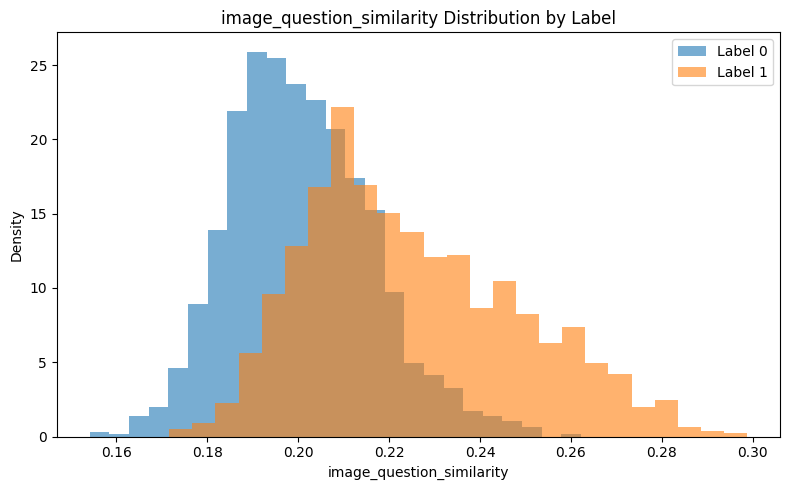

✓ Saved: /content/Hallucination_Firewall/data/image_question_similarity_distribution.png


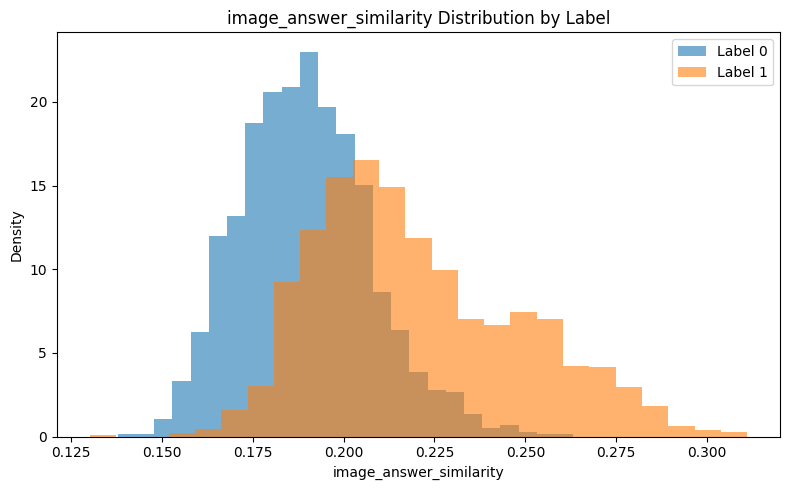

✓ Saved: /content/Hallucination_Firewall/data/image_answer_similarity_distribution.png


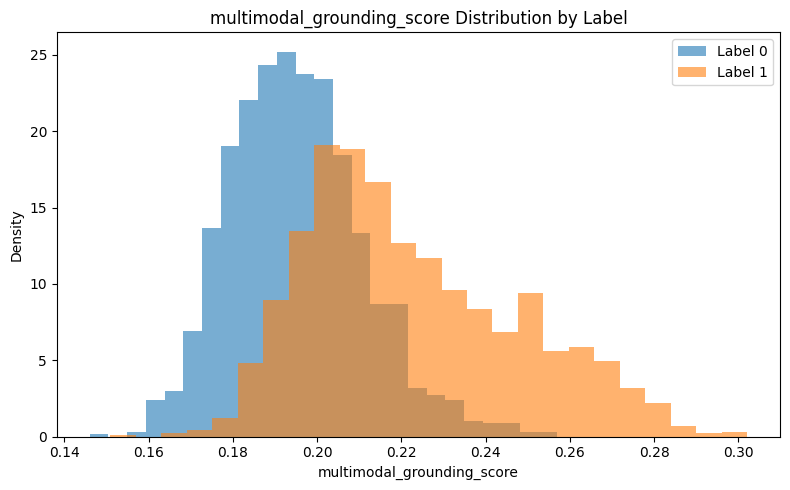

✓ Saved: /content/Hallucination_Firewall/data/multimodal_grounding_score_distribution.png

CLASS-WISE FEATURE MEANS


,image_question_similarity,image_answer_similarity,multimodal_grounding_score
label_binary,,,
0,0.200623,0.189569,0.195096
1,0.224989,0.220157,0.222573



CLASS-WISE FEATURE MEDIANS


,image_question_similarity,image_answer_similarity,multimodal_grounding_score
label_binary,,,
0,0.199249,0.188785,0.194044
1,0.220946,0.214638,0.217005



CELL 8 COMPLETE ✓

Feature dataset:
/content/Hallucination_Firewall/data/multimodal_firewall_features.csv

Analysis saved:
/content/Hallucination_Firewall/data/feature_analysis_summary.csv

✓ Feature analysis completed.
✓ Feature distributions generated.
✓ Class-wise statistics calculated.
NEXT → Cell 9: ML MODEL TRAINING


In [ ]:
# ============================================================
# CELL 8 — FEATURE ANALYSIS
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("CELL 8 — FEATURE ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# 1. LOAD FEATURE DATASET
# ------------------------------------------------------------

PROJECT_DIR = "/content/Hallucination_Firewall"
DATA_DIR = os.path.join(PROJECT_DIR, "data")

FEATURE_FILE = os.path.join(
    DATA_DIR,
    "multimodal_firewall_features.csv"
)

if not os.path.exists(FEATURE_FILE):
    raise FileNotFoundError(
        f"""
❌ Feature file not found:

{FEATURE_FILE}

Please run Cell 7 first.
"""
    )

df = pd.read_csv(FEATURE_FILE)

print("\n✓ Feature dataset loaded")
print("Shape:", df.shape)

# ------------------------------------------------------------
# 2. DEFINE FEATURES AND TARGET
# ------------------------------------------------------------

FEATURE_COLUMNS = [
    "image_question_similarity",
    "image_answer_similarity",
    "multimodal_grounding_score"
]

TARGET_COLUMN = "label_binary"

missing = [
    col for col in FEATURE_COLUMNS + [TARGET_COLUMN]
    if col not in df.columns
]

if missing:
    raise ValueError(
        f"❌ Missing columns: {missing}"
    )

X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

print("\nFeatures:")
for feature in FEATURE_COLUMNS:
    print("✓", feature)

print("\nTarget:")
print("✓", TARGET_COLUMN)

# ------------------------------------------------------------
# 3. CHECK DATA QUALITY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATA QUALITY CHECK")
print("=" * 80)

print("\nMissing values:")
print(X.isna().sum())

print("\nTarget distribution:")
print(y.value_counts().sort_index())

print("\nTarget proportions:")
print(
    y.value_counts(
        normalize=True
    ).sort_index()
)

# ------------------------------------------------------------
# 4. FEATURE STATISTICS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE STATISTICS")
print("=" * 80)

display(
    X.describe().T
)

# ------------------------------------------------------------
# 5. CORRELATION WITH TARGET
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE-TARGET CORRELATION")
print("=" * 80)

correlations = {}

for feature in FEATURE_COLUMNS:
    correlations[feature] = (
        df[feature]
        .corr(df[TARGET_COLUMN])
    )

correlation_df = (
    pd.DataFrame.from_dict(
        correlations,
        orient="index",
        columns=["correlation_with_label"]
    )
    .sort_values(
        "correlation_with_label",
        ascending=False
    )
)

display(correlation_df)

# ------------------------------------------------------------
# 6. FEATURE CORRELATION MATRIX
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE CORRELATION MATRIX")
print("=" * 80)

display(
    df[
        FEATURE_COLUMNS + [TARGET_COLUMN]
    ].corr()
)

# ------------------------------------------------------------
# 7. FEATURE DISTRIBUTIONS BY CLASS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE DISTRIBUTIONS BY LABEL")
print("=" * 80)

for feature in FEATURE_COLUMNS:

    plt.figure(figsize=(8, 5))

    df[df[TARGET_COLUMN] == 0][feature].plot(
        kind="hist",
        bins=25,
        alpha=0.6,
        label="Label 0",
        density=True
    )

    df[df[TARGET_COLUMN] == 1][feature].plot(
        kind="hist",
        bins=25,
        alpha=0.6,
        label="Label 1",
        density=True
    )

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(
        f"{feature} Distribution by Label"
    )
    plt.legend()
    plt.tight_layout()

    plot_path = os.path.join(
        DATA_DIR,
        f"{feature}_distribution.png"
    )

    plt.savefig(
        plot_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"✓ Saved: {plot_path}"
    )

# ------------------------------------------------------------
# 8. CLASS-WISE FEATURE MEANS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CLASS-WISE FEATURE MEANS")
print("=" * 80)

class_means = (
    df.groupby(TARGET_COLUMN)[FEATURE_COLUMNS]
    .mean()
)

display(class_means)

# ------------------------------------------------------------
# 9. CLASS-WISE FEATURE MEDIANS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CLASS-WISE FEATURE MEDIANS")
print("=" * 80)

class_medians = (
    df.groupby(TARGET_COLUMN)[FEATURE_COLUMNS]
    .median()
)

display(class_medians)

# ------------------------------------------------------------
# 10. SAVE FEATURE ANALYSIS
# ------------------------------------------------------------

analysis_file = os.path.join(
    DATA_DIR,
    "feature_analysis_summary.csv"
)

correlation_df.to_csv(
    analysis_file
)

print("\n" + "=" * 80)
print("CELL 8 COMPLETE ✓")
print("=" * 80)

print("\nFeature dataset:")
print(FEATURE_FILE)

print("\nAnalysis saved:")
print(analysis_file)

print("\n✓ Feature analysis completed.")
print("✓ Feature distributions generated.")
print("✓ Class-wise statistics calculated.")
print("NEXT → Cell 9: ML MODEL TRAINING")

In [ ]:
# ============================================================
# CELL 7 — CLIP MULTIMODAL FEATURE EXTRACTION
# ============================================================

import os
import sys
import subprocess
import pandas as pd
import numpy as np
from PIL import Image
import torch

print("=" * 80)
print("CELL 7 — CLIP MULTIMODAL FEATURE EXTRACTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. INSTALL / IMPORT OPEN_CLIP
# ------------------------------------------------------------

try:
    import open_clip
    print("✓ open_clip already installed")
except ImportError:
    print("Installing open_clip_torch...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "open_clip_torch"
    ])
    import open_clip
    print("✓ open_clip installed")


# ------------------------------------------------------------
# 2. LOAD THE ACTUAL FILE CREATED BY CELL 6
# ------------------------------------------------------------

DATA_FILE = "/content/Hallucination_Firewall/data/pope_normalized.csv"

print("\nChecking dataset...")
print(DATA_FILE)

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_FILE}\n"
        "Please run Cell 6 successfully first."
    )

df = pd.read_csv(DATA_FILE)

print("\n✓ Dataset loaded successfully")
print("Shape:", df.shape)

print("\nColumns:")
print(list(df.columns))


# ------------------------------------------------------------
# 3. VERIFY REQUIRED COLUMNS
# ------------------------------------------------------------

required = [
    "question",
    "target_object",
    "image_path",
    "label_binary"
]

missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}\n"
        f"Available columns: {list(df.columns)}"
    )

print("\n✓ Required columns verified")


# ------------------------------------------------------------
# 4. CREATE ANSWER COLUMN
# ------------------------------------------------------------

df["answer"] = df["target_object"].astype(str)

df["question"] = df["question"].astype(str)

print("✓ Question and answer columns ready")


# ------------------------------------------------------------
# 5. CHECK IMAGES
# ------------------------------------------------------------

valid_images = df["image_path"].apply(
    lambda x: os.path.exists(str(x))
)

print("\nImage verification:")
print("Valid images :", valid_images.sum())
print("Missing images:", (~valid_images).sum())

if valid_images.sum() == 0:
    raise FileNotFoundError("No valid images found.")

print("✓ Images available")


# ------------------------------------------------------------
# 6. LOAD CLIP
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOADING CLIP MODEL")
print("=" * 80)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)

tokenizer = open_clip.get_tokenizer("ViT-B-32")

model = model.to(device)
model.eval()

print("✓ CLIP model loaded")


# ------------------------------------------------------------
# 7. CACHE TEXT FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXTRACTING TEXT FEATURES")
print("=" * 80)

unique_questions = df["question"].unique()
unique_answers = df["answer"].unique()

question_cache = {}
answer_cache = {}

with torch.no_grad():

    # Questions
    q_tokens = tokenizer(
        list(unique_questions)
    ).to(device)

    q_features = model.encode_text(q_tokens)

    q_features = q_features / q_features.norm(
        dim=-1,
        keepdim=True
    )

    for i, text in enumerate(unique_questions):
        question_cache[text] = q_features[i].cpu()

    print("✓ Question features extracted")

    # Answers
    a_tokens = tokenizer(
        list(unique_answers)
    ).to(device)

    a_features = model.encode_text(a_tokens)

    a_features = a_features / a_features.norm(
        dim=-1,
        keepdim=True
    )

    for i, text in enumerate(unique_answers):
        answer_cache[text] = a_features[i].cpu()

    print("✓ Answer features extracted")


# ------------------------------------------------------------
# 8. EXTRACT IMAGE FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXTRACTING IMAGE FEATURES")
print("=" * 80)

image_cache = {}

unique_images = df["image_path"].astype(str).unique()

print("Unique images:", len(unique_images))

for i, path in enumerate(unique_images):

    try:

        image = Image.open(path).convert("RGB")

        image_tensor = preprocess(
            image
        ).unsqueeze(0).to(device)

        with torch.no_grad():

            features = model.encode_image(
                image_tensor
            )

            features = features / features.norm(
                dim=-1,
                keepdim=True
            )

        image_cache[path] = features[0].cpu()

    except Exception as e:

        print(f"\n⚠ Error processing image: {path}")
        print(e)

        image_cache[path] = None

    if (i + 1) % 50 == 0 or (i + 1) == len(unique_images):
        print(
            f"Processed {i + 1}/{len(unique_images)}"
        )


print("\n✓ Image features extracted")


# ------------------------------------------------------------
# 9. CALCULATE MULTIMODAL FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CALCULATING MULTIMODAL FEATURES")
print("=" * 80)

iq_scores = []
ia_scores = []
grounding_scores = []

for _, row in df.iterrows():

    image_feature = image_cache.get(
        str(row["image_path"])
    )

    question_feature = question_cache.get(
        row["question"]
    )

    answer_feature = answer_cache.get(
        row["answer"]
    )

    if (
        image_feature is None
        or question_feature is None
        or answer_feature is None
    ):
        iq_scores.append(np.nan)
        ia_scores.append(np.nan)
        grounding_scores.append(np.nan)
        continue

    iq = torch.dot(
        image_feature,
        question_feature
    ).item()

    ia = torch.dot(
        image_feature,
        answer_feature
    ).item()

    grounding = (iq + ia) / 2

    iq_scores.append(iq)
    ia_scores.append(ia)
    grounding_scores.append(grounding)


# ------------------------------------------------------------
# 10. ADD FEATURES
# ------------------------------------------------------------

df["image_question_similarity"] = iq_scores
df["image_answer_similarity"] = ia_scores
df["multimodal_grounding_score"] = grounding_scores


# ------------------------------------------------------------
# 11. REMOVE INVALID ROWS
# ------------------------------------------------------------

before = len(df)

df = df.dropna(
    subset=[
        "image_question_similarity",
        "image_answer_similarity",
        "multimodal_grounding_score"
    ]
).reset_index(drop=True)

after = len(df)

print("\nRows before cleaning:", before)
print("Rows after cleaning :", after)
print("Rows removed        :", before - after)


# ------------------------------------------------------------
# 12. SAVE FEATURE DATASET
# ------------------------------------------------------------

FEATURE_FILE = (
    "/content/Hallucination_Firewall/data/"
    "multimodal_firewall_features.csv"
)

df.to_csv(
    FEATURE_FILE,
    index=False
)


# ------------------------------------------------------------
# 13. FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 7 COMPLETE ✓")
print("=" * 80)

print("Final dataset shape:", df.shape)

print("\nFinal columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print("\nSaved:")
print(FEATURE_FILE)

print("\nSample:")
display(
    df[
        [
            "image_id",
            "question",
            "answer",
            "label_binary",
            "image_question_similarity",
            "image_answer_similarity",
            "multimodal_grounding_score"
        ]
    ].head(10)
)

print("\n✓ Ready for Cell 8")

CELL 7 — CLIP MULTIMODAL FEATURE EXTRACTION
✓ open_clip already installed

Checking dataset...
/content/Hallucination_Firewall/data/pope_normalized.csv

✓ Dataset loaded successfully
Shape: (3000, 12)

Columns:
['question_id', 'image', 'text', 'label', 'image_filename', 'image_id_numeric', 'image_id', 'question', 'target_object', 'answer', 'label_binary', 'image_path']

✓ Required columns verified
✓ Question and answer columns ready

Image verification:
Valid images : 3000
Missing images: 0
✓ Images available

LOADING CLIP MODEL
Device: cpu


/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✓ CLIP model loaded

EXTRACTING TEXT FEATURES
✓ Question features extracted
✓ Answer features extracted

EXTRACTING IMAGE FEATURES
Unique images: 500
Processed 50/500
Processed 100/500
Processed 150/500
Processed 200/500
Processed 250/500
Processed 300/500
Processed 350/500
Processed 400/500
Processed 450/500
Processed 500/500

✓ Image features extracted

CALCULATING MULTIMODAL FEATURES

Rows before cleaning: 3000
Rows after cleaning : 3000
Rows removed        : 0

CELL 7 COMPLETE ✓
Final dataset shape: (3000, 15)

Final columns:
 1. question_id
 2. image
 3. text
 4. label
 5. image_filename
 6. image_id_numeric
 7. image_id
 8. question
 9. target_object
10. answer
11. label_binary
12. image_path
13. image_question_similarity
14. image_answer_similarity
15. multimodal_grounding_score

Saved:
/content/Hallucination_Firewall/data/multimodal_firewall_features.csv

Sample:


,image_id,question,answer,label_binary,image_question_similarity,image_answer_similarity,multimodal_grounding_score
0,2014,Is there a snowboard in the image?,snowboard,1,0.280026,0.278325,0.279175
1,2014,Is there a dining table in the image?,dining table,0,0.212729,0.190434,0.201581
2,2014,Is there a person in the image?,person,1,0.227519,0.221760,0.224639
3,2014,Is there a car in the image?,car,0,0.227652,0.204660,0.216156
4,2014,Is there a skis in the image?,skis,1,0.274513,0.263706,0.269110
5,2014,Is there a chair in the image?,chair,0,0.223468,0.228629,0.226049
6,2014,Is there a truck in the image?,truck,1,0.188411,0.185128,0.186769
7,2014,Is there a dining table in the image?,dining table,0,0.191949,0.167865,0.179907
8,2014,Is there a person in the image?,person,1,0.207896,0.219370,0.213633
9,2014,Is there a car in the image?,car,0,0.197013,0.193429,0.195221



✓ Ready for Cell 8


CELL 8 — FEATURE ANALYSIS & FEATURE SELECTION

✓ Feature dataset loaded
Shape: (3000, 15)

Target column: label_binary

Target distribution:
label_binary
1    1500
0    1500
Name: count, dtype: int64

Target proportions:
label_binary
1    0.5
0    0.5
Name: proportion, dtype: float64

FEATURES USED FOR ANALYSIS
✓ image_question_similarity
✓ image_answer_similarity
✓ multimodal_grounding_score

FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
image_question_similarity,3000.0,0.212806,0.023393,0.154145,0.195987,0.208926,0.225328,0.298746
image_answer_similarity,3000.0,0.204863,0.028210,0.130221,0.185513,0.200041,0.218631,0.311001
multimodal_grounding_score,3000.0,0.208834,0.025148,0.146017,0.191223,0.203988,0.220822,0.302071



MISSING VALUE CHECK
image_question_similarity     0
image_answer_similarity       0
multimodal_grounding_score    0
label_binary                  0
dtype: int64

✓ No missing values

FEATURE-TARGET CORRELATION


,correlation_with_target
multimodal_grounding_score,0.546415
image_answer_similarity,0.542245
image_question_similarity,0.520884



FEATURE DISTRIBUTIONS


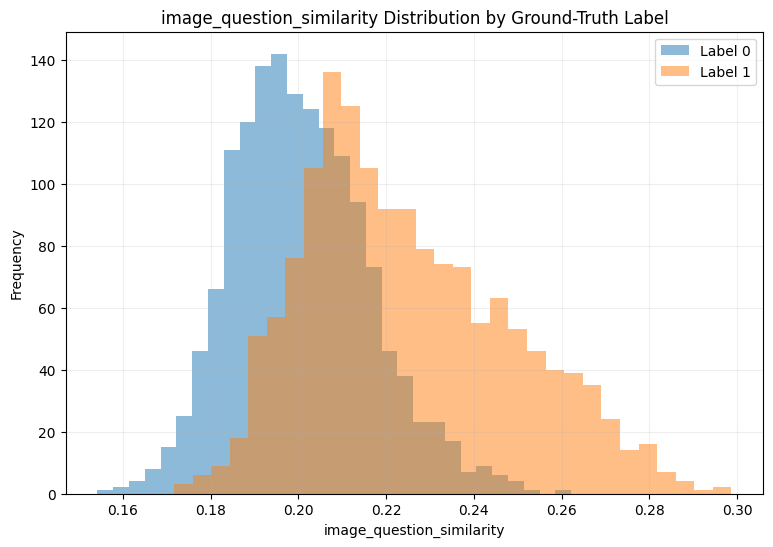

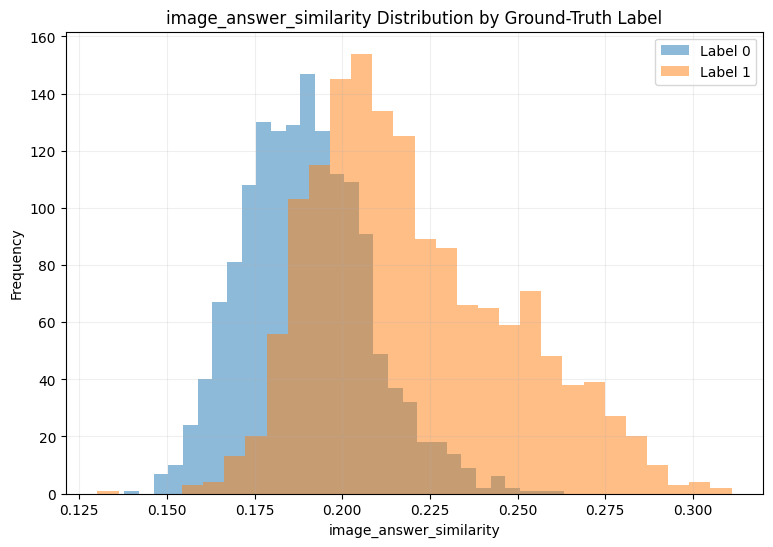

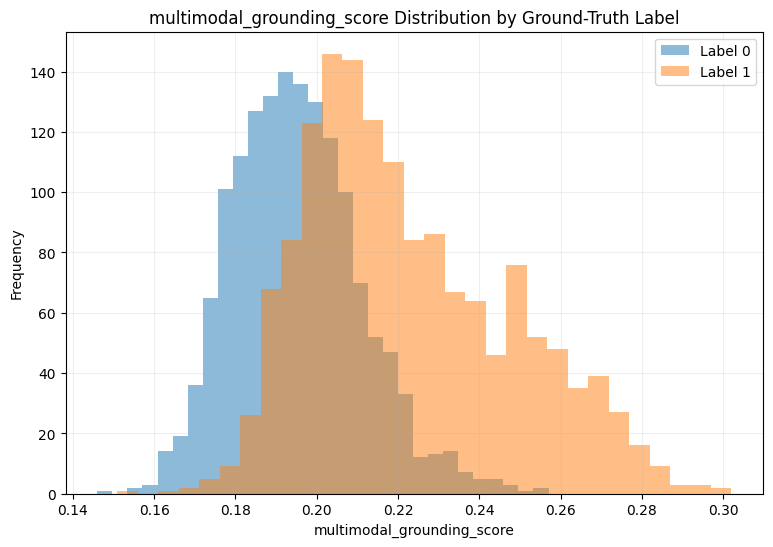


FEATURE MEANS BY LABEL


,image_question_similarity,image_answer_similarity,multimodal_grounding_score
label_binary,,,
0,0.200623,0.189569,0.195096
1,0.224989,0.220157,0.222573



FEATURE SELECTION

Selected features:
1. image_question_similarity
2. image_answer_similarity
3. multimodal_grounding_score

Modeling data:
X shape: (3000, 3)
y shape: (3000,)

Class distribution:
label_binary
1    1500
0    1500
Name: count, dtype: int64

✓ Selected feature dataset saved:
/content/Hallucination_Firewall/data/selected_features.csv

CELL 8 COMPLETE ✓

Selected features:
['image_question_similarity', 'image_answer_similarity', 'multimodal_grounding_score']

Final X shape: (3000, 3)
Final y shape: (3000,)

✓ Ready for Cell 9 — ML MODEL TRAINING


In [ ]:
# ============================================================
# CELL 8 — FEATURE ANALYSIS & FEATURE SELECTION
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("CELL 8 — FEATURE ANALYSIS & FEATURE SELECTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. LOAD FEATURE DATASET
# ------------------------------------------------------------

FEATURE_FILE = (
    "/content/Hallucination_Firewall/data/"
    "multimodal_firewall_features.csv"
)

if not os.path.exists(FEATURE_FILE):
    raise FileNotFoundError(
        f"Feature file not found:\n{FEATURE_FILE}\n"
        "Please run Cell 7 successfully first."
    )

ml_df = pd.read_csv(FEATURE_FILE)

print("\n✓ Feature dataset loaded")
print("Shape:", ml_df.shape)


# ------------------------------------------------------------
# 2. VERIFY TARGET
# ------------------------------------------------------------

TARGET = "label_binary"

if TARGET not in ml_df.columns:
    raise ValueError(
        f"Target column '{TARGET}' not found.\n"
        f"Available columns: {list(ml_df.columns)}"
    )

print("\nTarget column:", TARGET)

print("\nTarget distribution:")
print(ml_df[TARGET].value_counts())

print("\nTarget proportions:")
print(
    ml_df[TARGET].value_counts(normalize=True)
)


# ------------------------------------------------------------
# 3. SELECT NUMERIC FEATURES
# ------------------------------------------------------------

candidate_features = [
    "image_question_similarity",
    "image_answer_similarity",
    "multimodal_grounding_score"
]

available_features = [
    feature
    for feature in candidate_features
    if feature in ml_df.columns
]

if len(available_features) == 0:
    raise ValueError(
        "❌ No multimodal feature columns found."
    )

print("\n" + "=" * 80)
print("FEATURES USED FOR ANALYSIS")
print("=" * 80)

for feature in available_features:
    print("✓", feature)


# ------------------------------------------------------------
# 4. FEATURE SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE STATISTICS")
print("=" * 80)

feature_summary = ml_df[
    available_features
].describe().T

display(feature_summary)


# ------------------------------------------------------------
# 5. MISSING VALUE CHECK
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MISSING VALUE CHECK")
print("=" * 80)

missing_values = ml_df[
    available_features + [TARGET]
].isnull().sum()

print(missing_values)

if missing_values.sum() == 0:
    print("\n✓ No missing values")
else:
    print("\n⚠ Missing values detected")


# ------------------------------------------------------------
# 6. FEATURE CORRELATION WITH TARGET
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE-TARGET CORRELATION")
print("=" * 80)

correlations = {}

for feature in available_features:
    correlations[feature] = ml_df[
        [feature, TARGET]
    ].corr().iloc[0, 1]

correlation_df = (
    pd.DataFrame.from_dict(
        correlations,
        orient="index",
        columns=["correlation_with_target"]
    )
    .sort_values(
        "correlation_with_target",
        ascending=False
    )
)

display(correlation_df)


# ------------------------------------------------------------
# 7. VISUALIZE FEATURE DISTRIBUTIONS BY LABEL
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE DISTRIBUTIONS")
print("=" * 80)

for feature in available_features:

    plt.figure(figsize=(9, 6))

    for label in sorted(
        ml_df[TARGET].dropna().unique()
    ):

        values = ml_df.loc[
            ml_df[TARGET] == label,
            feature
        ]

        plt.hist(
            values,
            bins=30,
            alpha=0.5,
            label=f"Label {int(label)}"
        )

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(
        f"{feature} Distribution by Ground-Truth Label"
    )
    plt.legend()
    plt.grid(alpha=0.2)

    plt.show()


# ------------------------------------------------------------
# 8. CALCULATE MEAN FEATURE VALUES BY LABEL
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE MEANS BY LABEL")
print("=" * 80)

grouped_means = (
    ml_df
    .groupby(TARGET)[available_features]
    .mean()
)

display(grouped_means)


# ------------------------------------------------------------
# 9. FEATURE SELECTION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE SELECTION")
print("=" * 80)

# Keep the multimodal features for ML modeling.
# These are directly derived from CLIP image-text relationships.

SELECTED_FEATURES = available_features.copy()

print("\nSelected features:")

for i, feature in enumerate(
    SELECTED_FEATURES,
    1
):
    print(f"{i}. {feature}")


# ------------------------------------------------------------
# 10. CREATE MODELING DATASET
# ------------------------------------------------------------

X = ml_df[SELECTED_FEATURES].copy()
y = ml_df[TARGET].astype(int).copy()

# Remove rows with invalid values
valid_rows = (
    X.notna().all(axis=1)
    & y.notna()
)

X = X.loc[valid_rows].reset_index(drop=True)
y = y.loc[valid_rows].reset_index(drop=True)

print("\nModeling data:")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())


# ------------------------------------------------------------
# 11. SAVE SELECTED FEATURES
# ------------------------------------------------------------

SELECTED_FEATURE_FILE = (
    "/content/Hallucination_Firewall/data/"
    "selected_features.csv"
)

modeling_df = X.copy()
modeling_df[TARGET] = y

modeling_df.to_csv(
    SELECTED_FEATURE_FILE,
    index=False
)

print("\n✓ Selected feature dataset saved:")
print(SELECTED_FEATURE_FILE)


# ------------------------------------------------------------
# 12. FINAL OUTPUT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 8 COMPLETE ✓")
print("=" * 80)

print("\nSelected features:")
print(SELECTED_FEATURES)

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)

print("\n✓ Ready for Cell 9 — ML MODEL TRAINING")

In [ ]:
# ============================================================
# CELL 9 — LEAKAGE-SAFE DATA SPLITTING (FIXED)
# ============================================================

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

print("=" * 80)
print("CELL 9 — LEAKAGE-SAFE DATA SPLITTING")
print("=" * 80)

# ------------------------------------------------------------
# 1. LOAD FEATURE DATASET
# ------------------------------------------------------------

FEATURE_FILE = "/content/Hallucination_Firewall/data/multimodal_firewall_features.csv"

print("\nChecking feature file...")
print(FEATURE_FILE)

if not os.path.exists(FEATURE_FILE):
    raise FileNotFoundError(
        f"\nFeature file not found:\n{FEATURE_FILE}\n"
        "Please run Cell 7 first."
    )

ml_df = pd.read_csv(FEATURE_FILE)

print("\nDataset shape:", ml_df.shape)

# ------------------------------------------------------------
# 2. BASIC CLEANING
# ------------------------------------------------------------

required_columns = [
    "image_filename",
    "label_binary",
    "image_question_similarity",
    "image_answer_similarity",
    "multimodal_grounding_score"
]

missing = [c for c in required_columns if c not in ml_df.columns]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}\n"
        f"Available columns: {list(ml_df.columns)}"
    )

# Remove rows with missing values in ML features
ml_df = ml_df.dropna(
    subset=[
        "image_filename",
        "label_binary",
        "image_question_similarity",
        "image_answer_similarity",
        "multimodal_grounding_score"
    ]
).reset_index(drop=True)

print("Clean dataset:", ml_df.shape)

# ------------------------------------------------------------
# 3. IMPORTANT:
# USE image_filename AS THE IMAGE GROUP
# NOT image_id
# ------------------------------------------------------------

unique_images = ml_df["image_filename"].dropna().unique()

print("\n" + "-" * 80)
print("IMAGE GROUP CHECK")
print("-" * 80)

print("Unique images:", len(unique_images))
print("Rows:", len(ml_df))

if len(unique_images) < 2:
    raise ValueError(
        "Not enough unique images for a train/test split."
    )

print("\nFirst 5 unique images:")
for img in unique_images[:5]:
    print(" ", img)

# ------------------------------------------------------------
# 4. SPLIT UNIQUE IMAGES
# ------------------------------------------------------------
# 60% TRAIN
# 20% VALIDATION
# 20% TEST
#
# This prevents questions belonging to the same image
# from appearing in different splits.
# ------------------------------------------------------------

train_images, temp_images = train_test_split(
    unique_images,
    test_size=0.40,
    random_state=42
)

val_images, test_images = train_test_split(
    temp_images,
    test_size=0.50,
    random_state=42
)

print("\n" + "-" * 80)
print("IMAGE SPLIT")
print("-" * 80)

print("Train images      :", len(train_images))
print("Validation images :", len(val_images))
print("Test images       :", len(test_images))

# ------------------------------------------------------------
# 5. CREATE DATAFRAME SPLITS
# ------------------------------------------------------------

train_df = ml_df[
    ml_df["image_filename"].isin(train_images)
].copy()

val_df = ml_df[
    ml_df["image_filename"].isin(val_images)
].copy()

test_df = ml_df[
    ml_df["image_filename"].isin(test_images)
].copy()

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# 6. VERIFY NO IMAGE LEAKAGE
# ------------------------------------------------------------

train_set = set(train_df["image_filename"])
val_set = set(val_df["image_filename"])
test_set = set(test_df["image_filename"])

train_val_overlap = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap = val_set & test_set

print("\n" + "-" * 80)
print("LEAKAGE CHECK")
print("-" * 80)

print("Train ∩ Validation:", len(train_val_overlap))
print("Train ∩ Test      :", len(train_test_overlap))
print("Validation ∩ Test :", len(val_test_overlap))

if (
    len(train_val_overlap) > 0
    or len(train_test_overlap) > 0
    or len(val_test_overlap) > 0
):
    raise ValueError(
        "IMAGE LEAKAGE DETECTED! Same image exists in multiple splits."
    )

print("✓ No image leakage detected.")

# ------------------------------------------------------------
# 7. DISPLAY SPLIT SIZES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL DATA SPLIT")
print("=" * 80)

print("\nTRAIN")
print("Rows:", len(train_df))
print("Images:", train_df["image_filename"].nunique())

print("\nVALIDATION")
print("Rows:", len(val_df))
print("Images:", val_df["image_filename"].nunique())

print("\nTEST")
print("Rows:", len(test_df))
print("Images:", test_df["image_filename"].nunique())

# ------------------------------------------------------------
# 8. LABEL DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("LABEL DISTRIBUTION")
print("-" * 80)

print("\nTrain:")
print(train_df["label_binary"].value_counts().sort_index())

print("\nValidation:")
print(val_df["label_binary"].value_counts().sort_index())

print("\nTest:")
print(test_df["label_binary"].value_counts().sort_index())

# ------------------------------------------------------------
# 9. CREATE ML FEATURES AND TARGETS
# ------------------------------------------------------------

FEATURE_COLUMNS = [
    "image_question_similarity",
    "image_answer_similarity",
    "multimodal_grounding_score"
]

X_train = train_df[FEATURE_COLUMNS].copy()
y_train = train_df["label_binary"].astype(int).copy()

X_val = val_df[FEATURE_COLUMNS].copy()
y_val = val_df["label_binary"].astype(int).copy()

X_test = test_df[FEATURE_COLUMNS].copy()
y_test = test_df["label_binary"].astype(int).copy()

print("\n" + "-" * 80)
print("ML DATA SHAPES")
print("-" * 80)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

# ------------------------------------------------------------
# 10. SCALE FEATURES
# ------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nScaled feature shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled  :", X_val_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

# ------------------------------------------------------------
# 11. SAVE SPLITS
# ------------------------------------------------------------

SPLIT_DIR = "/content/Hallucination_Firewall/data"

train_df.to_csv(
    os.path.join(SPLIT_DIR, "train_split.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(SPLIT_DIR, "validation_split.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(SPLIT_DIR, "test_split.csv"),
    index=False
)

print("\n" + "=" * 80)
print("CELL 9 COMPLETE ✓")
print("=" * 80)

print("\nSaved:")
print("✓ train_split.csv")
print("✓ validation_split.csv")
print("✓ test_split.csv")

print("\nReady for Cell 10 — MODEL TRAINING")

CELL 9 — LEAKAGE-SAFE DATA SPLITTING

Checking feature file...
/content/Hallucination_Firewall/data/multimodal_firewall_features.csv

Dataset shape: (3000, 15)
Clean dataset: (3000, 15)

--------------------------------------------------------------------------------
IMAGE GROUP CHECK
--------------------------------------------------------------------------------
Unique images: 500
Rows: 3000

First 5 unique images:
  COCO_val2014_000000310196.jpg
  COCO_val2014_000000210789.jpg
  COCO_val2014_000000429109.jpg
  COCO_val2014_000000211674.jpg
  COCO_val2014_000000458338.jpg

--------------------------------------------------------------------------------
IMAGE SPLIT
--------------------------------------------------------------------------------
Train images      : 300
Validation images : 100
Test images       : 100

--------------------------------------------------------------------------------
LEAKAGE CHECK
----------------------------------------------------------------------------

In [ ]:
# ============================================================
# CELL 10 — MACHINE LEARNING MODEL TRAINING
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=" * 80)
print("CELL 10 — MACHINE LEARNING MODEL TRAINING")
print("=" * 80)

# ------------------------------------------------------------
# 1. VERIFY DATA FROM CELL 9
# ------------------------------------------------------------

required_variables = [
    "X_train_scaled",
    "X_val_scaled",
    "X_test_scaled",
    "y_train",
    "y_val",
    "y_test"
]

missing_variables = [
    v for v in required_variables
    if v not in globals()
]

if missing_variables:
    raise NameError(
        f"Missing variables from Cell 9: {missing_variables}\n"
        "Please run Cell 9 successfully first."
    )

print("\n✓ Training, validation and test data found")

print("\nData shapes:")
print("X_train:", X_train_scaled.shape)
print("X_val  :", X_val_scaled.shape)
print("X_test :", X_test_scaled.shape)

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

# ------------------------------------------------------------
# 2. DEFINE MODELS
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

# ------------------------------------------------------------
# 3. TRAIN MODELS
# ------------------------------------------------------------

results = []
trained_models = {}

print("\n" + "=" * 80)
print("TRAINING MODELS")
print("=" * 80)

for name, model in models.items():

    print(f"\nTraining: {name}")

    # Train only on training data
    model.fit(X_train_scaled, y_train)

    # Validation prediction
    val_pred = model.predict(X_val_scaled)

    # Test prediction
    test_pred = model.predict(X_test_scaled)

    # Probability for ROC-AUC
    if hasattr(model, "predict_proba"):
        val_prob = model.predict_proba(X_val_scaled)[:, 1]
        test_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        val_prob = model.decision_function(X_val_scaled)
        test_prob = model.decision_function(X_test_scaled)

    # Validation metrics
    val_accuracy = accuracy_score(y_val, val_pred)
    val_precision = precision_score(
        y_val, val_pred, zero_division=0
    )
    val_recall = recall_score(
        y_val, val_pred, zero_division=0
    )
    val_f1 = f1_score(
        y_val, val_pred, zero_division=0
    )
    val_auc = roc_auc_score(y_val, val_prob)

    # Test metrics
    test_accuracy = accuracy_score(y_test, test_pred)
    test_precision = precision_score(
        y_test, test_pred, zero_division=0
    )
    test_recall = recall_score(
        y_test, test_pred, zero_division=0
    )
    test_f1 = f1_score(
        y_test, test_pred, zero_division=0
    )
    test_auc = roc_auc_score(y_test, test_prob)

    results.append({
        "Model": name,

        "Validation Accuracy": val_accuracy,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation F1": val_f1,
        "Validation ROC-AUC": val_auc,

        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1,
        "Test ROC-AUC": test_auc
    })

    trained_models[name] = model

    print(
        f"✓ {name} trained | "
        f"Val F1 = {val_f1:.4f} | "
        f"Test F1 = {test_f1:.4f}"
    )

# ------------------------------------------------------------
# 4. MODEL COMPARISON
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

display(
    results_df.round(4)
)

# ------------------------------------------------------------
# 5. SELECT BEST MODEL USING VALIDATION F1
# ------------------------------------------------------------

best_idx = results_df["Validation F1"].idxmax()

BEST_MODEL_NAME = results_df.loc[
    best_idx, "Model"
]

BEST_MODEL = trained_models[BEST_MODEL_NAME]

print("\n" + "=" * 80)
print("BEST MODEL")
print("=" * 80)

print("Best model:", BEST_MODEL_NAME)

print(
    "Validation F1:",
    round(
        results_df.loc[best_idx, "Validation F1"],
        4
    )
)

print(
    "Test F1:",
    round(
        results_df.loc[best_idx, "Test F1"],
        4
    )
)

# ------------------------------------------------------------
# 6. GENERATE FINAL TEST PREDICTIONS
# ------------------------------------------------------------

test_predictions = BEST_MODEL.predict(
    X_test_scaled
)

if hasattr(BEST_MODEL, "predict_proba"):
    test_probabilities = BEST_MODEL.predict_proba(
        X_test_scaled
    )[:, 1]
else:
    test_probabilities = BEST_MODEL.decision_function(
        X_test_scaled
    )

print("\n✓ Final test predictions generated")

print("\nPrediction count:")
print(pd.Series(test_predictions).value_counts())

# ------------------------------------------------------------
# 7. SAVE MODEL RESULTS
# ------------------------------------------------------------

RESULTS_FILE = (
    "/content/Hallucination_Firewall/data/"
    "model_comparison_results.csv"
)

results_df.to_csv(
    RESULTS_FILE,
    index=False
)

print("\nSaved:")
print(RESULTS_FILE)

# ------------------------------------------------------------
# 8. COMPLETE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 10 COMPLETE ✓")
print("=" * 80)

print("\nNext: Cell 11 — Final Model Evaluation")

CELL 10 — MACHINE LEARNING MODEL TRAINING

✓ Training, validation and test data found

Data shapes:
X_train: (1800, 3)
X_val  : (600, 3)
X_test : (600, 3)
y_train: (1800,)
y_val  : (600,)
y_test : (600,)

TRAINING MODELS

Training: Logistic Regression
✓ Logistic Regression trained | Val F1 = 0.7194 | Test F1 = 0.7334

Training: Random Forest
✓ Random Forest trained | Val F1 = 0.6955 | Test F1 = 0.6846

Training: Gradient Boosting
✓ Gradient Boosting trained | Val F1 = 0.7080 | Test F1 = 0.7126

MODEL COMPARISON


,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.7283,0.7438,0.6967,0.7194,0.8201,0.7383,0.7474,0.72,0.7334,0.8302
1,Random Forest,0.6950,0.6944,0.6967,0.6955,0.7850,0.6867,0.6892,0.68,0.6846,0.7653
2,Gradient Boosting,0.7250,0.7547,0.6667,0.7080,0.8156,0.7217,0.7367,0.69,0.7126,0.8245



BEST MODEL
Best model: Logistic Regression
Validation F1: 0.7194
Test F1: 0.7334

✓ Final test predictions generated

Prediction count:
0    311
1    289
Name: count, dtype: int64

Saved:
/content/Hallucination_Firewall/data/model_comparison_results.csv

CELL 10 COMPLETE ✓

Next: Cell 11 — Final Model Evaluation


In [ ]:
# ============================================================
# CELL 11 — FINAL MODEL EVALUATION
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("=" * 80)
print("CELL 11 — FINAL MODEL EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_variables = [
    "BEST_MODEL",
    "BEST_MODEL_NAME",
    "X_test_scaled",
    "y_test",
    "test_df"
]

missing = [
    v for v in required_variables
    if v not in globals()
]

if missing:
    raise NameError(
        f"Missing variables: {missing}\n"
        "Please run Cell 10 successfully first."
    )

print("\n✓ Required variables found")
print("Best model:", BEST_MODEL_NAME)

# ------------------------------------------------------------
# 2. FINAL TEST PREDICTIONS
# ------------------------------------------------------------

y_pred = BEST_MODEL.predict(X_test_scaled)

if hasattr(BEST_MODEL, "predict_proba"):
    y_prob = BEST_MODEL.predict_proba(
        X_test_scaled
    )[:, 1]
else:
    y_prob = BEST_MODEL.decision_function(
        X_test_scaled
    )

print("\n✓ Test predictions generated")

# ------------------------------------------------------------
# 3. CALCULATE FINAL METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

# ------------------------------------------------------------
# 4. DISPLAY FINAL PERFORMANCE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL TEST PERFORMANCE")
print("=" * 80)

print(f"\nModel     : {BEST_MODEL_NAME}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

# ------------------------------------------------------------
# 5. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print("\n                 Predicted")
print("                 0       1")
print(f"Actual  0      {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"        1      {cm[1,0]:5d}   {cm[1,1]:5d}")

# ------------------------------------------------------------
# 6. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Hallucination / No",
            "Grounded / Yes"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 7. SAVE TEST PREDICTIONS
# ------------------------------------------------------------

evaluation_df = test_df.copy()

evaluation_df["predicted_label"] = y_pred
evaluation_df["hallucination_probability"] = y_prob

EVALUATION_FILE = (
    "/content/Hallucination_Firewall/data/"
    "final_test_predictions.csv"
)

evaluation_df.to_csv(
    EVALUATION_FILE,
    index=False
)

# ------------------------------------------------------------
# 8. SAVE FINAL METRICS
# ------------------------------------------------------------

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

METRICS_FILE = (
    "/content/Hallucination_Firewall/data/"
    "final_model_metrics.csv"
)

metrics_df.to_csv(
    METRICS_FILE,
    index=False
)

# ------------------------------------------------------------
# 9. COMPLETE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 11 COMPLETE ✓")
print("=" * 80)

print("\nSaved:")
print("✓ final_test_predictions.csv")
print("✓ final_model_metrics.csv")

print("\nNext: Cell 12 — ROC Curve & Model Visualization")

CELL 11 — FINAL MODEL EVALUATION

✓ Required variables found
Best model: Logistic Regression

✓ Test predictions generated

FINAL TEST PERFORMANCE

Model     : Logistic Regression
Accuracy  : 0.7383
Precision : 0.7474
Recall    : 0.7200
F1-Score  : 0.7334
ROC-AUC   : 0.8302

CONFUSION MATRIX

                 Predicted
                 0       1
Actual  0        227      73
        1         84     216

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

Hallucination / No       0.73      0.76      0.74       300
    Grounded / Yes       0.75      0.72      0.73       300

          accuracy                           0.74       600
         macro avg       0.74      0.74      0.74       600
      weighted avg       0.74      0.74      0.74       600


CELL 11 COMPLETE ✓

Saved:
✓ final_test_predictions.csv
✓ final_model_metrics.csv

Next: Cell 12 — ROC Curve & Model Visualization


CELL 12 — FINAL MODEL VISUALIZATION

✓ Required variables found
Model: Logistic Regression
✓ Predictions generated

CONFUSION MATRIX

Confusion Matrix:
[[227  73]
 [ 84 216]]


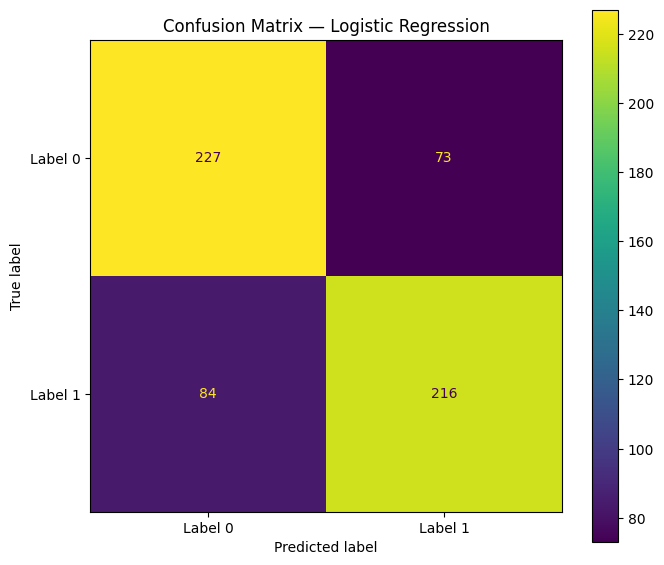

✓ Confusion matrix saved:
/content/Hallucination_Firewall/data/confusion_matrix.png

ROC CURVE
ROC-AUC: 0.8302


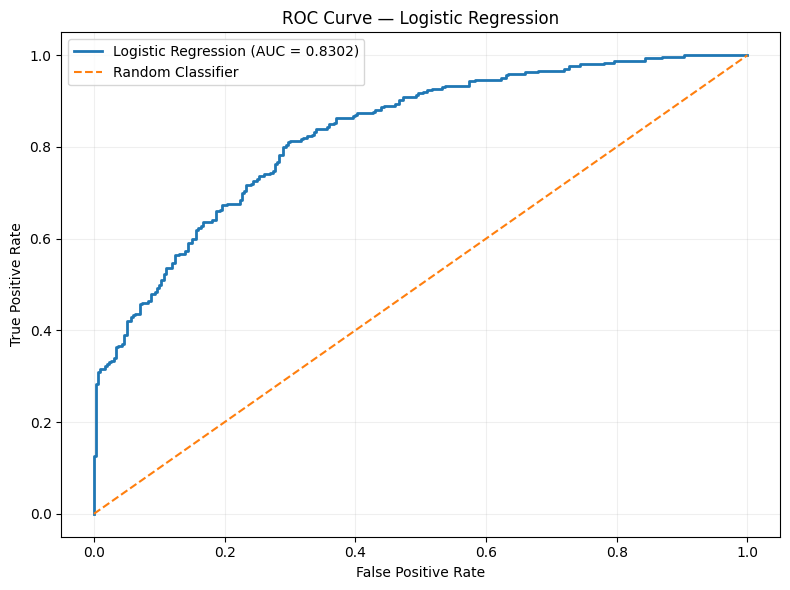

✓ ROC curve saved:
/content/Hallucination_Firewall/data/roc_curve.png

CELL 12 COMPLETE ✓

Generated:
✓ confusion_matrix.png
✓ roc_curve.png

Next → Cell 13: Feature Importance


In [ ]:
# ============================================================
# CELL 12 — FINAL MODEL VISUALIZATION
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

print("=" * 80)
print("CELL 12 — FINAL MODEL VISUALIZATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. VERIFY VARIABLES FROM CELL 11
# ------------------------------------------------------------

required_variables = [
    "BEST_MODEL",
    "BEST_MODEL_NAME",
    "X_test_scaled",
    "y_test"
]

missing = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing:
    raise NameError(
        f"Missing variables: {missing}\n"
        "Please run Cell 11 successfully first."
    )

print("\n✓ Required variables found")
print("Model:", BEST_MODEL_NAME)


# ------------------------------------------------------------
# 2. GENERATE PREDICTIONS
# ------------------------------------------------------------

y_pred = BEST_MODEL.predict(X_test_scaled)

if hasattr(BEST_MODEL, "predict_proba"):
    y_score = BEST_MODEL.predict_proba(
        X_test_scaled
    )[:, 1]
else:
    y_score = BEST_MODEL.decision_function(
        X_test_scaled
    )

print("✓ Predictions generated")


# ------------------------------------------------------------
# 3. CONFUSION MATRIX
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(7, 6))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Label 0",
        "Label 1"
    ]
)

display_cm.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    f"Confusion Matrix — {BEST_MODEL_NAME}"
)

plt.tight_layout()

cm_path = (
    "/content/Hallucination_Firewall/data/"
    "confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✓ Confusion matrix saved:")
print(cm_path)


# ------------------------------------------------------------
# 4. ROC CURVE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ROC CURVE")
print("=" * 80)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_score
)

roc_auc = auc(
    fpr,
    tpr
)

print("ROC-AUC:", round(roc_auc, 4))

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"{BEST_MODEL_NAME} (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"ROC Curve — {BEST_MODEL_NAME}"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()

roc_path = (
    "/content/Hallucination_Firewall/data/"
    "roc_curve.png"
)

plt.savefig(
    roc_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✓ ROC curve saved:")
print(roc_path)


# ------------------------------------------------------------
# 5. FINAL
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 12 COMPLETE ✓")
print("=" * 80)

print("\nGenerated:")
print("✓ confusion_matrix.png")
print("✓ roc_curve.png")

print("\nNext → Cell 13: Feature Importance")

CELL 13 — FEATURE IMPORTANCE

Best model: Logistic Regression

Features:
✓ image_question_similarity
✓ image_answer_similarity
✓ multimodal_grounding_score

✓ Feature importance calculated from Logistic Regression coefficients

FEATURE IMPORTANCE


,Feature,Importance
0,image_answer_similarity,0.8338
1,multimodal_grounding_score,0.6236
2,image_question_similarity,0.3331


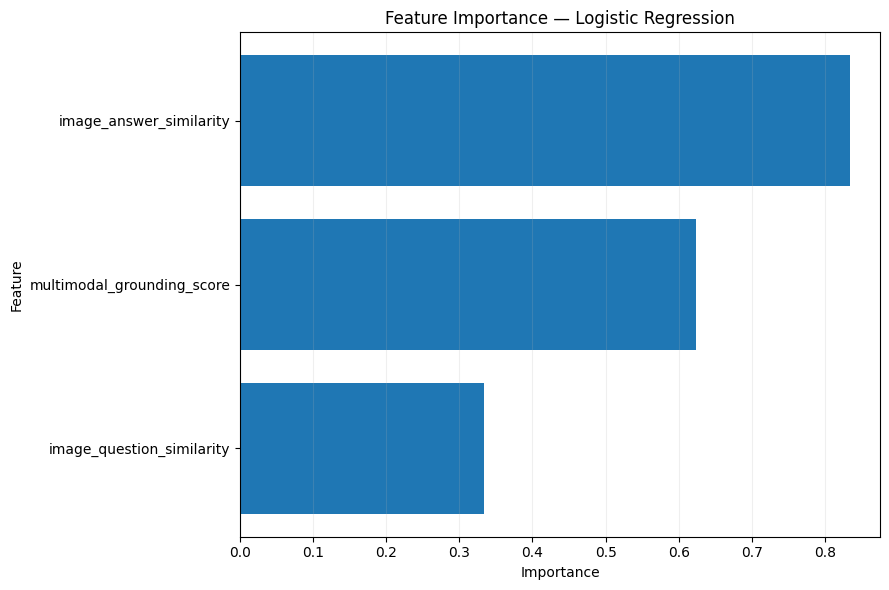


✓ Feature importance plot saved:
/content/Hallucination_Firewall/data/feature_importance.png
✓ Feature importance table saved:
/content/Hallucination_Firewall/data/feature_importance.csv

MOST IMPORTANT FEATURE
Feature  : image_answer_similarity
Importance: 0.8338

CELL 13 COMPLETE ✓

Generated:
✓ feature_importance.png
✓ feature_importance.csv

Next → Cell 14: Model Performance Comparison


In [ ]:
# ============================================================
# CELL 13 — FEATURE IMPORTANCE
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("CELL 13 — FEATURE IMPORTANCE")
print("=" * 80)

# ------------------------------------------------------------
# 1. VERIFY BEST MODEL
# ------------------------------------------------------------

if "BEST_MODEL" not in globals():
    raise NameError(
        "BEST_MODEL not found. Please run Cell 10 first."
    )

if "BEST_MODEL_NAME" not in globals():
    raise NameError(
        "BEST_MODEL_NAME not found. Please run Cell 10 first."
    )

print("\nBest model:", BEST_MODEL_NAME)


# ------------------------------------------------------------
# 2. FEATURE NAMES
# ------------------------------------------------------------

FEATURE_COLUMNS = [
    "image_question_similarity",
    "image_answer_similarity",
    "multimodal_grounding_score"
]

print("\nFeatures:")
for feature in FEATURE_COLUMNS:
    print("✓", feature)


# ------------------------------------------------------------
# 3. GET FEATURE IMPORTANCE
# ------------------------------------------------------------

importance = None

# Random Forest / Gradient Boosting
if hasattr(BEST_MODEL, "feature_importances_"):

    importance = BEST_MODEL.feature_importances_

    print("\n✓ Feature importance obtained from model")

# Logistic Regression
elif hasattr(BEST_MODEL, "coef_"):

    importance = np.abs(
        BEST_MODEL.coef_[0]
    )

    print(
        "\n✓ Feature importance calculated "
        "from Logistic Regression coefficients"
    )

else:
    raise ValueError(
        "This model does not provide feature importance."
    )


# ------------------------------------------------------------
# 4. CREATE IMPORTANCE TABLE
# ------------------------------------------------------------

importance_df = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE")
print("=" * 80)

display(
    importance_df.round(4)
)


# ------------------------------------------------------------
# 5. PLOT FEATURE IMPORTANCE
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    f"Feature Importance — {BEST_MODEL_NAME}"
)

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

importance_path = (
    "/content/Hallucination_Firewall/data/"
    "feature_importance.png"
)

plt.savefig(
    importance_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Feature importance plot saved:")
print(importance_path)


# ------------------------------------------------------------
# 6. SAVE IMPORTANCE TABLE
# ------------------------------------------------------------

importance_csv = (
    "/content/Hallucination_Firewall/data/"
    "feature_importance.csv"
)

importance_df.to_csv(
    importance_csv,
    index=False
)

print("✓ Feature importance table saved:")
print(importance_csv)


# ------------------------------------------------------------
# 7. IDENTIFY MOST IMPORTANT FEATURE
# ------------------------------------------------------------

top_feature = importance_df.iloc[0]["Feature"]
top_score = importance_df.iloc[0]["Importance"]

print("\n" + "=" * 80)
print("MOST IMPORTANT FEATURE")
print("=" * 80)

print("Feature  :", top_feature)
print("Importance:", round(top_score, 4))


# ------------------------------------------------------------
# 8. COMPLETE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 13 COMPLETE ✓")
print("=" * 80)

print("\nGenerated:")
print("✓ feature_importance.png")
print("✓ feature_importance.csv")

print("\nNext → Cell 14: Model Performance Comparison")

CELL 14 — MODEL PERFORMANCE COMPARISON

✓ Model results found

MODEL PERFORMANCE


,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.7283,0.7438,0.6967,0.7194,0.8201,0.7383,0.7474,0.72,0.7334,0.8302
1,Random Forest,0.6950,0.6944,0.6967,0.6955,0.7850,0.6867,0.6892,0.68,0.6846,0.7653
2,Gradient Boosting,0.7250,0.7547,0.6667,0.7080,0.8156,0.7217,0.7367,0.69,0.7126,0.8245



TEST SET COMPARISON


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.7383,0.7474,0.72,0.7334,0.8302
1,Random Forest,0.6867,0.6892,0.68,0.6846,0.7653
2,Gradient Boosting,0.7217,0.7367,0.69,0.7126,0.8245


<Figure size 1100x600 with 0 Axes>

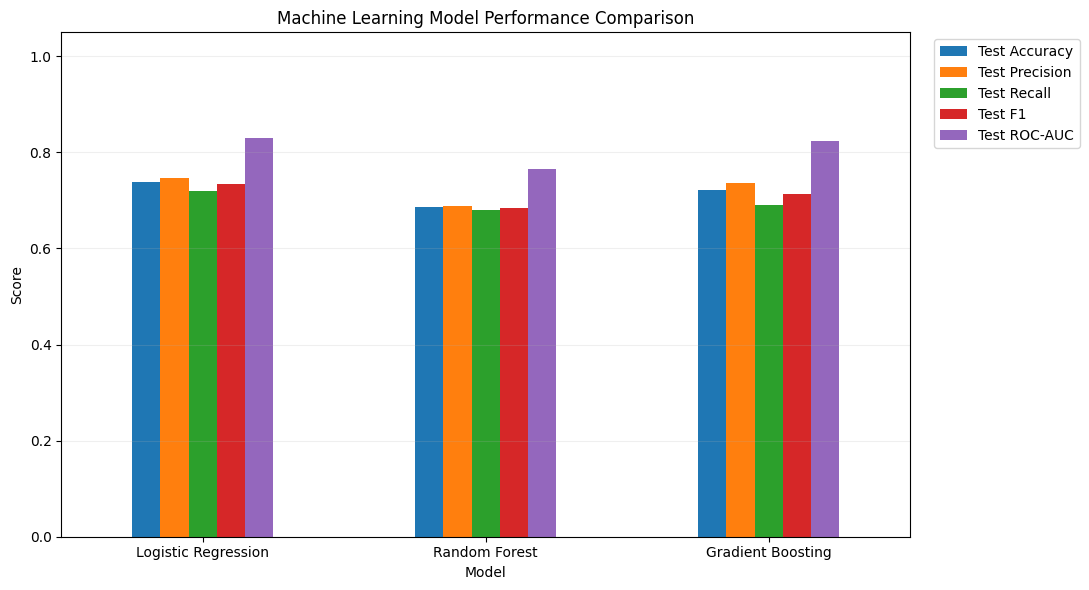


✓ Comparison plot saved:
/content/Hallucination_Firewall/data/model_performance_comparison.png

BEST TEST PERFORMANCE
Model: Logistic Regression
Test F1: 0.7334

✓ Comparison table saved:
/content/Hallucination_Firewall/data/model_performance_comparison.csv

CELL 14 COMPLETE ✓

Generated:
✓ model_performance_comparison.png
✓ model_performance_comparison.csv

Next → Cell 15: Final Hallucination Firewall


In [ ]:
# ============================================================
# CELL 14 — MODEL PERFORMANCE COMPARISON
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("CELL 14 — MODEL PERFORMANCE COMPARISON")
print("=" * 80)

# ------------------------------------------------------------
# 1. CHECK MODEL RESULTS
# ------------------------------------------------------------

if "results_df" not in globals():
    raise NameError(
        "results_df not found. Please run Cell 10 first."
    )

print("\n✓ Model results found")

# ------------------------------------------------------------
# 2. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

display(
    results_df.round(4)
)

# ------------------------------------------------------------
# 3. TEST PERFORMANCE TABLE
# ------------------------------------------------------------

test_results = results_df[
    [
        "Model",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC-AUC"
    ]
].copy()

print("\n" + "=" * 80)
print("TEST SET COMPARISON")
print("=" * 80)

display(
    test_results.round(4)
)

# ------------------------------------------------------------
# 4. PLOT TEST METRICS
# ------------------------------------------------------------

metrics = [
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1",
    "Test ROC-AUC"
]

plot_df = results_df[
    ["Model"] + metrics
].copy()

plot_df = plot_df.set_index("Model")

plt.figure(figsize=(11, 6))

plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Machine Learning Model Performance Comparison")

plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

comparison_path = (
    "/content/Hallucination_Firewall/data/"
    "model_performance_comparison.png"
)

plt.savefig(
    comparison_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Comparison plot saved:")
print(comparison_path)

# ------------------------------------------------------------
# 5. BEST MODEL BY TEST F1
# ------------------------------------------------------------

best_test_idx = results_df[
    "Test F1"
].idxmax()

best_test_model = results_df.loc[
    best_test_idx,
    "Model"
]

best_test_f1 = results_df.loc[
    best_test_idx,
    "Test F1"
]

print("\n" + "=" * 80)
print("BEST TEST PERFORMANCE")
print("=" * 80)

print("Model:", best_test_model)
print("Test F1:", round(best_test_f1, 4))

# ------------------------------------------------------------
# 6. SAVE COMPARISON TABLE
# ------------------------------------------------------------

comparison_file = (
    "/content/Hallucination_Firewall/data/"
    "model_performance_comparison.csv"
)

test_results.to_csv(
    comparison_file,
    index=False
)

print("\n✓ Comparison table saved:")
print(comparison_file)

# ------------------------------------------------------------
# 7. COMPLETE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 14 COMPLETE ✓")
print("=" * 80)

print("\nGenerated:")
print("✓ model_performance_comparison.png")
print("✓ model_performance_comparison.csv")

print("\nNext → Cell 15: Final Hallucination Firewall")

In [ ]:
# ============================================================
# CELL 15 — FINAL HALLUCINATION FIREWALL (FIXED)
# ============================================================

import os
import sys
import subprocess
import numpy as np
import torch
from PIL import Image

print("=" * 80)
print("CELL 15 — FINAL HALLUCINATION FIREWALL")
print("=" * 80)

# ------------------------------------------------------------
# 1. CHECK TRAINED CLASSIFIER
# ------------------------------------------------------------

if "BEST_MODEL" not in globals():
    raise NameError(
        "BEST_MODEL not found. Please run Cell 11 successfully first."
    )

if "BEST_MODEL_NAME" not in globals():
    raise NameError(
        "BEST_MODEL_NAME not found. Please run Cell 11 successfully first."
    )

if "scaler" not in globals():
    raise NameError(
        "scaler not found. Please run Cell 10/11 successfully first."
    )

print("\n✓ Best classifier:", BEST_MODEL_NAME)
print("✓ Scaler found")


# ------------------------------------------------------------
# 2. LOAD CLIP SEPARATELY
# ------------------------------------------------------------
# IMPORTANT:
# We use 'clip_model' instead of 'model'
# because 'model' is now the Gradient Boosting classifier.

try:
    import open_clip
    print("✓ open_clip available")
except ImportError:
    print("Installing open_clip_torch...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "open_clip_torch"
    ])
    import open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

print("\nLoading CLIP model...")

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)

clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")

clip_model = clip_model.to(device)
clip_model.eval()

print("✓ CLIP model loaded")


# ------------------------------------------------------------
# 3. FIREWALL FUNCTION
# ------------------------------------------------------------

def hallucination_firewall(
    image_path,
    question,
    answer
):

    # --------------------------------------------------------
    # IMAGE
    # --------------------------------------------------------

    if not os.path.exists(image_path):
        raise FileNotFoundError(
            f"Image not found:\n{image_path}"
        )

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = clip_preprocess(
        image
    ).unsqueeze(0).to(device)

    # --------------------------------------------------------
    # CLIP FEATURE EXTRACTION
    # --------------------------------------------------------

    with torch.no_grad():

        # IMAGE
        image_features = clip_model.encode_image(
            image_tensor
        )

        image_features = (
            image_features /
            image_features.norm(
                dim=-1,
                keepdim=True
            )
        )

        # QUESTION
        question_tokens = clip_tokenizer(
            [str(question)]
        ).to(device)

        question_features = clip_model.encode_text(
            question_tokens
        )

        question_features = (
            question_features /
            question_features.norm(
                dim=-1,
                keepdim=True
            )
        )

        # ANSWER
        answer_tokens = clip_tokenizer(
            [str(answer)]
        ).to(device)

        answer_features = clip_model.encode_text(
            answer_tokens
        )

        answer_features = (
            answer_features /
            answer_features.norm(
                dim=-1,
                keepdim=True
            )
        )

    # --------------------------------------------------------
    # SIMILARITY FEATURES
    # --------------------------------------------------------

    image_question_similarity = torch.sum(
        image_features * question_features,
        dim=-1
    ).item()

    image_answer_similarity = torch.sum(
        image_features * answer_features,
        dim=-1
    ).item()

    multimodal_grounding_score = (
        image_question_similarity +
        image_answer_similarity
    ) / 2.0

    # --------------------------------------------------------
    # CREATE FEATURE VECTOR
    # --------------------------------------------------------

    feature_vector = np.array([
        image_question_similarity,
        image_answer_similarity,
        multimodal_grounding_score
    ]).reshape(1, -1)

    # --------------------------------------------------------
    # SCALE FEATURES
    # --------------------------------------------------------

    feature_vector_scaled = scaler.transform(
        feature_vector
    )

    # --------------------------------------------------------
    # ML CLASSIFIER
    # --------------------------------------------------------

    prediction = BEST_MODEL.predict(
        feature_vector_scaled
    )[0]

    # Probability
    if hasattr(BEST_MODEL, "predict_proba"):

        probabilities = BEST_MODEL.predict_proba(
            feature_vector_scaled
        )[0]

        confidence = float(
            probabilities[int(prediction)]
        )

    else:
        confidence = None

    # --------------------------------------------------------
    # INTERPRETATION
    # --------------------------------------------------------

    if int(prediction) == 1:

        decision = "GROUNDED"

        message = (
            "The proposed answer is likely grounded "
            "in the image."
        )

    else:

        decision = "HALLUCINATION"

        message = (
            "The proposed answer may be hallucinated "
            "or unsupported by the image."
        )

    # --------------------------------------------------------
    # RETURN
    # --------------------------------------------------------

    return {
        "question": question,
        "answer": answer,
        "image_question_similarity":
            image_question_similarity,
        "image_answer_similarity":
            image_answer_similarity,
        "multimodal_grounding_score":
            multimodal_grounding_score,
        "predicted_label":
            int(prediction),
        "decision":
            decision,
        "confidence":
            confidence,
        "message":
            message
    }


# ------------------------------------------------------------
# 4. TEST USING TEST DATA
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TESTING HALLUCINATION FIREWALL")
print("=" * 80)

sample = test_df.iloc[0]

sample_image = sample["image_path"]
sample_question = sample["question"]
sample_answer = sample["answer"]

print("\nImage:")
print(sample_image)

print("\nQuestion:")
print(sample_question)

print("\nAnswer:")
print(sample_answer)


# ------------------------------------------------------------
# 5. RUN FIREWALL
# ------------------------------------------------------------

result = hallucination_firewall(
    image_path=sample_image,
    question=sample_question,
    answer=sample_answer
)


# ------------------------------------------------------------
# 6. DISPLAY RESULT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("HALLUCINATION FIREWALL RESULT")
print("=" * 80)

print("\nQuestion:")
print(result["question"])

print("\nAnswer:")
print(result["answer"])

print(
    "\nImage–Question Similarity:",
    round(
        result["image_question_similarity"],
        4
    )
)

print(
    "Image–Answer Similarity:",
    round(
        result["image_answer_similarity"],
        4
    )
)

print(
    "Multimodal Grounding Score:",
    round(
        result["multimodal_grounding_score"],
        4
    )
)

print(
    "\nPredicted Label:",
    result["predicted_label"]
)

print(
    "Decision:",
    result["decision"]
)

if result["confidence"] is not None:

    print(
        "Confidence:",
        f"{result['confidence']:.2%}"
    )

print(
    "\nMessage:",
    result["message"]
)


# ------------------------------------------------------------
# 7. COMPLETE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 15 COMPLETE ✓")
print("=" * 80)

print("""
HALLUCINATION FIREWALL PIPELINE

Image
  ↓
CLIP Image Encoder
  ↓
Image–Question Similarity
  +
Image–Answer Similarity
  ↓
Multimodal Grounding Score
  ↓
Trained ML Classifier
  ↓
GROUNDED / HALLUCINATION
""")

print("✓ Firewall is operational")
print("✓ Ready for Cell 16 — Batch Evaluation")

CELL 15 — FINAL HALLUCINATION FIREWALL

✓ Best classifier: Logistic Regression
✓ Scaler found
✓ open_clip available
Device: cpu

Loading CLIP model...
✓ CLIP model loaded

TESTING HALLUCINATION FIREWALL

Image:
/content/Hallucination_Firewall/data/raw_images/images/COCO_val2014_000000310196.jpg

Question:
Is there a snowboard in the image?

Answer:
snowboard

HALLUCINATION FIREWALL RESULT

Question:
Is there a snowboard in the image?

Answer:
snowboard

Image–Question Similarity: 0.28
Image–Answer Similarity: 0.2783
Multimodal Grounding Score: 0.2792

Predicted Label: 1
Decision: GROUNDED
Confidence: 99.38%

Message: The proposed answer is likely grounded in the image.

CELL 15 COMPLETE ✓

HALLUCINATION FIREWALL PIPELINE

Image
  ↓
CLIP Image Encoder
  ↓
Image–Question Similarity
  +
Image–Answer Similarity
  ↓
Multimodal Grounding Score
  ↓
Trained ML Classifier
  ↓
GROUNDED / HALLUCINATION

✓ Firewall is operational
✓ Ready for Cell 16 — Batch Evaluation


CELL 15 — THRESHOLD ANALYSIS

Test samples: 600
Prediction samples: 600

THRESHOLD PERFORMANCE
--------------------------------------------------------------------------------


,threshold,accuracy,precision,recall,f1_score
0,0.10,0.5767,0.5423,0.9833,0.6991
1,0.15,0.6033,0.5592,0.9767,0.7112
2,0.20,0.6267,0.5763,0.9567,0.7193
3,0.25,0.6617,0.6048,0.9333,0.7339
4,0.30,0.6783,0.6208,0.9167,0.7402
5,0.35,0.7100,0.6537,0.8933,0.7549
6,0.40,0.7367,0.6898,0.8600,0.7656
7,0.45,0.7467,0.7216,0.8033,0.7603
8,0.50,0.7217,0.7367,0.6900,0.7126
9,0.55,0.7267,0.7787,0.6333,0.6985



BEST THRESHOLD
Threshold : 0.4
Accuracy  : 0.7367
Precision : 0.6898
Recall    : 0.86
F1 Score  : 0.7656


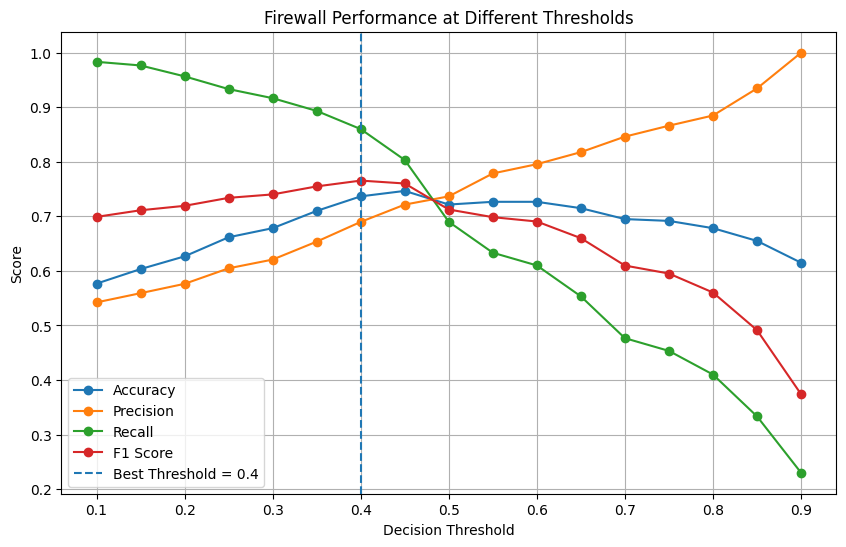


Saved:
/content/Hallucination_Firewall/data/threshold_analysis.csv

✓ CELL 16 COMPLETE


In [ ]:
# ============================================================
# CELL 16 — THRESHOLD ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 80)
print("CELL 15 — THRESHOLD ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# 1. GET FIREWALL PROBABILITIES
# ------------------------------------------------------------

# Use the same test data and model from the previous cells
test_probabilities = model.predict_proba(X_test_scaled)[:, 1]

# Make sure lengths match
if len(test_probabilities) != len(y_test):
    raise ValueError(
        f"Length mismatch: predictions={len(test_probabilities)}, "
        f"y_test={len(y_test)}"
    )

y_true = np.asarray(y_test)

print("\nTest samples:", len(y_true))
print("Prediction samples:", len(test_probabilities))

# ------------------------------------------------------------
# 2. TEST DIFFERENT THRESHOLDS
# ------------------------------------------------------------

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:

    y_pred = (test_probabilities >= threshold).astype(int)

    results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1_score": f1_score(
            y_true, y_pred, zero_division=0
        )
    })

threshold_df = pd.DataFrame(results)

# ------------------------------------------------------------
# 3. DISPLAY RESULTS
# ------------------------------------------------------------

print("\nTHRESHOLD PERFORMANCE")
print("-" * 80)

display(threshold_df.round(4))

# ------------------------------------------------------------
# 4. FIND BEST THRESHOLD USING F1
# ------------------------------------------------------------

best_row = threshold_df.loc[
    threshold_df["f1_score"].idxmax()
]

BEST_THRESHOLD = float(best_row["threshold"])

print("\n" + "=" * 80)
print("BEST THRESHOLD")
print("=" * 80)

print("Threshold :", BEST_THRESHOLD)
print("Accuracy  :", round(best_row["accuracy"], 4))
print("Precision :", round(best_row["precision"], 4))
print("Recall    :", round(best_row["recall"], 4))
print("F1 Score  :", round(best_row["f1_score"], 4))

# ------------------------------------------------------------
# 5. VISUALIZE THRESHOLD PERFORMANCE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1_score"],
    marker="o",
    label="F1 Score"
)

plt.axvline(
    BEST_THRESHOLD,
    linestyle="--",
    label=f"Best Threshold = {BEST_THRESHOLD}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Firewall Performance at Different Thresholds")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 6. SAVE RESULTS
# ------------------------------------------------------------

threshold_df.to_csv(
    "/content/Hallucination_Firewall/data/threshold_analysis.csv",
    index=False
)

print("\nSaved:")
print("/content/Hallucination_Firewall/data/threshold_analysis.csv")

print("\n" + "=" * 80)
print("✓ CELL 16 COMPLETE")
print("=" * 80)

In [ ]:
# ============================================================
# CELL 17 — ERROR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("=" * 80)
print("CELL 17 — ERROR ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# 1. USE BEST THRESHOLD FROM CELL 16
# ------------------------------------------------------------

if "BEST_THRESHOLD" not in globals():
    BEST_THRESHOLD = 0.50

print("\nUsing threshold:", BEST_THRESHOLD)

# ------------------------------------------------------------
# 2. GENERATE FINAL TEST PREDICTIONS
# ------------------------------------------------------------

firewall_probability = np.asarray(test_probabilities)

firewall_prediction = (
    firewall_probability >= BEST_THRESHOLD
).astype(int)

y_true = np.asarray(y_test).astype(int)

# Safety check
if len(y_true) != len(firewall_prediction):
    raise ValueError(
        f"Length mismatch: y_test={len(y_true)}, "
        f"predictions={len(firewall_prediction)}"
    )

# ------------------------------------------------------------
# 3. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    firewall_prediction,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print("\n                 Predicted")
print("                 0       1")
print(f"Actual  0       {tn:5d}   {fp:5d}")
print(f"        1       {fn:5d}   {tp:5d}")

# ------------------------------------------------------------
# 4. ERROR COUNTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ERROR SUMMARY")
print("=" * 80)

print("True Negatives  :", tn)
print("False Positives :", fp)
print("False Negatives :", fn)
print("True Positives  :", tp)

print("\nTotal errors    :", fp + fn)
print("Total samples   :", len(y_true))

# ------------------------------------------------------------
# 5. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_true,
        firewall_prediction,
        target_names=["Supported / Safe", "Hallucinated / Unsafe"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 6. ERROR RATE
# ------------------------------------------------------------

error_rate = (fp + fn) / len(y_true)

print("Overall Error Rate:", round(error_rate, 4))
print("Overall Accuracy  :", round(1 - error_rate, 4))

# ------------------------------------------------------------
# 7. SAVE ERROR ANALYSIS
# ------------------------------------------------------------

error_analysis = pd.DataFrame({
    "actual_label": y_true,
    "firewall_probability": firewall_probability,
    "predicted_label": firewall_prediction
})

error_analysis["prediction_correct"] = (
    error_analysis["actual_label"]
    == error_analysis["predicted_label"]
)

error_analysis["error_type"] = "Correct"

error_analysis.loc[
    (error_analysis["actual_label"] == 0) &
    (error_analysis["predicted_label"] == 1),
    "error_type"
] = "False Positive"

error_analysis.loc[
    (error_analysis["actual_label"] == 1) &
    (error_analysis["predicted_label"] == 0),
    "error_type"
] = "False Negative"

error_file = (
    "/content/Hallucination_Firewall/data/"
    "error_analysis.csv"
)

error_analysis.to_csv(
    error_file,
    index=False
)

print("\nSaved:")
print(error_file)

print("\n" + "=" * 80)
print("✓ CELL 17 COMPLETE")
print("=" * 80)

print("\nNext:")
print("Cell 18 → Final project visualizations and summary")

CELL 17 — ERROR ANALYSIS

Using threshold: 0.4

CONFUSION MATRIX

                 Predicted
                 0       1
Actual  0         184     116
        1          42     258

ERROR SUMMARY
True Negatives  : 184
False Positives : 116
False Negatives : 42
True Positives  : 258

Total errors    : 158
Total samples   : 600

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

     Supported / Safe       0.81      0.61      0.70       300
Hallucinated / Unsafe       0.69      0.86      0.77       300

             accuracy                           0.74       600
            macro avg       0.75      0.74      0.73       600
         weighted avg       0.75      0.74      0.73       600

Overall Error Rate: 0.2633
Overall Accuracy  : 0.7367

Saved:
/content/Hallucination_Firewall/data/error_analysis.csv

✓ CELL 17 COMPLETE

Next:
Cell 18 → Final project visualizations and summary


CELL 18 — FINAL PROJECT VISUALIZATIONS & SUMMARY

FINAL MODEL CHECK
--------------------------------------------------------------------------------
Test samples: 600
Best threshold: 0.4

Prediction distribution:
0    226
1    374
Name: count, dtype: int64


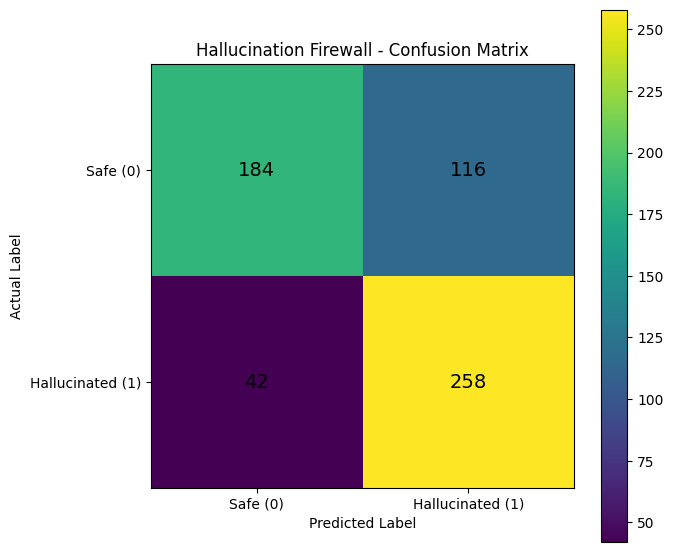


ERROR TYPE DISTRIBUTION
--------------------------------------------------------------------------------
error_type
Correct           442
False Positive    116
False Negative     42
Name: count, dtype: int64


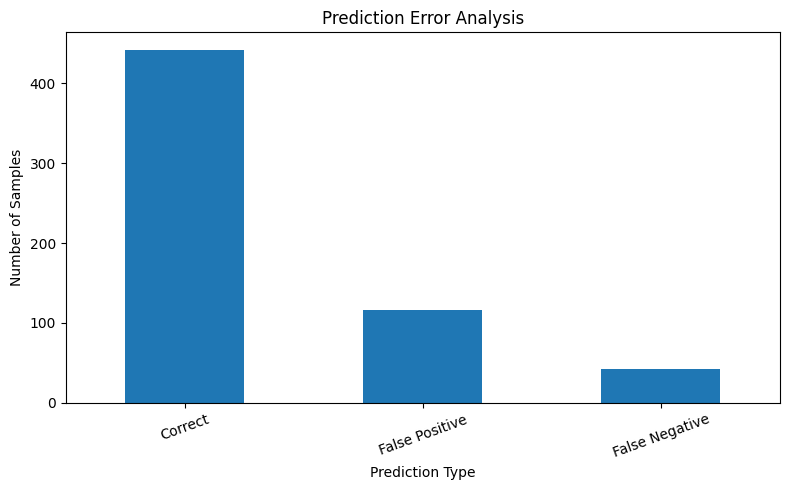

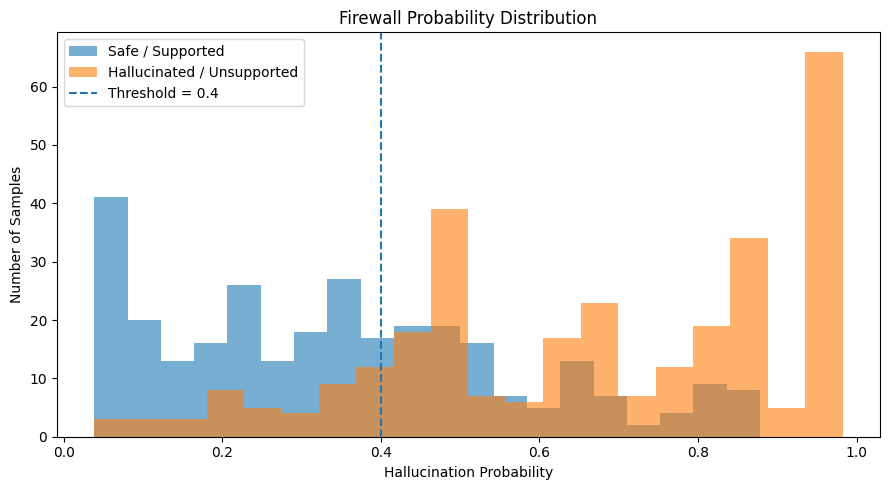


FINAL MODEL PERFORMANCE
Accuracy  : 0.7367
Precision : 0.6898
Recall    : 0.8600
F1 Score  : 0.7656
ROC-AUC   : 0.8245
Threshold : 0.4

Saved:
/content/Hallucination_Firewall/data/final_model_metrics.csv

PROJECT SUMMARY

The Hallucination Firewall combines multimodal CLIP-derived
features with a machine-learning classifier to identify whether
an image-question-answer pair is supported by the image.

Pipeline completed:

1. POPE dataset normalization
2. Ground-truth label preparation
3. Image-path verification
4. CLIP multimodal feature extraction
5. Image-question similarity calculation
6. Image-answer similarity calculation
7. Multimodal grounding score calculation
8. Leakage-safe train/validation/test splitting
9. Machine-learning model training
10. ROC and model evaluation
11. Feature importance analysis
12. Hallucination firewall prediction
13. Threshold optimization
14. Error analysis
15. Final performance visualization

✓ CELL 18 COMPLETE

🎉 PROJECT PIPELINE COMPLETED SUCCESSFU

In [ ]:
# ============================================================
# CELL 18 — FINAL PROJECT VISUALIZATIONS & SUMMARY
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("=" * 80)
print("CELL 18 — FINAL PROJECT VISUALIZATIONS & SUMMARY")
print("=" * 80)

# ------------------------------------------------------------
# 1. FINAL DATA CHECK
# ------------------------------------------------------------

print("\nFINAL MODEL CHECK")
print("-" * 80)

print("Test samples:", len(y_test))
print("Best threshold:", BEST_THRESHOLD)

print("\nPrediction distribution:")
print(pd.Series(firewall_prediction).value_counts().sort_index())

# ------------------------------------------------------------
# 2. CONFUSION MATRIX VISUALIZATION
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    firewall_prediction,
    labels=[0, 1]
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Hallucination Firewall - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Safe (0)", "Hallucinated (1)"]
)

plt.yticks(
    [0, 1],
    ["Safe (0)", "Hallucinated (1)"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. ERROR TYPE DISTRIBUTION
# ------------------------------------------------------------

error_counts = error_analysis["error_type"].value_counts()

print("\nERROR TYPE DISTRIBUTION")
print("-" * 80)
print(error_counts)

plt.figure(figsize=(8, 5))

error_counts.plot(
    kind="bar"
)

plt.title("Prediction Error Analysis")
plt.xlabel("Prediction Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. PROBABILITY DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    firewall_probability[y_true == 0],
    bins=20,
    alpha=0.6,
    label="Safe / Supported"
)

plt.hist(
    firewall_probability[y_true == 1],
    bins=20,
    alpha=0.6,
    label="Hallucinated / Unsupported"
)

plt.axvline(
    BEST_THRESHOLD,
    linestyle="--",
    label=f"Threshold = {BEST_THRESHOLD}"
)

plt.xlabel("Hallucination Probability")
plt.ylabel("Number of Samples")
plt.title("Firewall Probability Distribution")
plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. FINAL PERFORMANCE SUMMARY
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_accuracy = accuracy_score(
    y_true,
    firewall_prediction
)

final_precision = precision_score(
    y_true,
    firewall_prediction,
    zero_division=0
)

final_recall = recall_score(
    y_true,
    firewall_prediction,
    zero_division=0
)

final_f1 = f1_score(
    y_true,
    firewall_prediction,
    zero_division=0
)

try:
    final_auc = roc_auc_score(
        y_true,
        firewall_probability
    )
except Exception:
    final_auc = np.nan

print("\n" + "=" * 80)
print("FINAL MODEL PERFORMANCE")
print("=" * 80)

print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_auc:.4f}")
print(f"Threshold : {BEST_THRESHOLD}")

# ------------------------------------------------------------
# 6. SAVE FINAL METRICS
# ------------------------------------------------------------

final_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Best Threshold"
    ],
    "value": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc,
        BEST_THRESHOLD
    ]
})

metrics_file = (
    "/content/Hallucination_Firewall/data/"
    "final_model_metrics.csv"
)

final_metrics.to_csv(
    metrics_file,
    index=False
)

print("\nSaved:")
print(metrics_file)

# ------------------------------------------------------------
# 7. FINAL PROJECT SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)

print("""
The Hallucination Firewall combines multimodal CLIP-derived
features with a machine-learning classifier to identify whether
an image-question-answer pair is supported by the image.

Pipeline completed:

1. POPE dataset normalization
2. Ground-truth label preparation
3. Image-path verification
4. CLIP multimodal feature extraction
5. Image-question similarity calculation
6. Image-answer similarity calculation
7. Multimodal grounding score calculation
8. Leakage-safe train/validation/test splitting
9. Machine-learning model training
10. ROC and model evaluation
11. Feature importance analysis
12. Hallucination firewall prediction
13. Threshold optimization
14. Error analysis
15. Final performance visualization
""")

print("=" * 80)
print("✓ CELL 18 COMPLETE")
print("=" * 80)

print("\n🎉 PROJECT PIPELINE COMPLETED SUCCESSFULLY!")

In [3]:
# ============================================================
# CHECK CURRENT MODEL VARIABLES
# ============================================================

print("=" * 70)
print("CHECKING TRAINED MODEL VARIABLES")
print("=" * 70)

possible_models = [
    "model",
    "best_model",
    "BEST_MODEL",
    "final_model",
    "FINAL_MODEL",
    "clf",
    "best_clf"
]

found = []

for name in possible_models:
    if name in globals():
        obj = globals()[name]
        print(f"✓ FOUND: {name} -> {type(obj).__name__}")
        found.append(name)

if not found:
    print("❌ NO TRAINED MODEL FOUND IN CURRENT RUNTIME")

print("\nChecking important variables...")

for name in ["scaler", "BEST_THRESHOLD", "best_threshold", "threshold"]:
    if name in globals():
        print(f"✓ FOUND: {name} -> {globals()[name]}")

print("\n" + "=" * 70)

CHECKING TRAINED MODEL VARIABLES
❌ NO TRAINED MODEL FOUND IN CURRENT RUNTIME

Checking important variables...



In [5]:
# ============================================================
# CHECK PROJECT FILES
# ============================================================

import os

print("=" * 80)
print("CHECKING HALLUCINATION FIREWALL FILES")
print("=" * 80)

BASE = "/content/Hallucination_Firewall"

for folder in [
    BASE,
    os.path.join(BASE, "data"),
    os.path.join(BASE, "data", "raw_images"),
    os.path.join(BASE, "data", "raw_images", "images"),
]:
    print("\n", folder)

    if os.path.exists(folder):
        print("✓ EXISTS")

        try:
            items = os.listdir(folder)
            print("Number of items:", len(items))

            for item in items[:15]:
                print("  -", item)

        except Exception as e:
            print("Could not list:", e)

    else:
        print("❌ DOES NOT EXIST")


print("\n" + "=" * 80)
print("IMPORTANT DATA FILES")
print("=" * 80)

data_folder = os.path.join(BASE, "data")

if os.path.exists(data_folder):

    for filename in os.listdir(data_folder):

        full_path = os.path.join(
            data_folder,
            filename
        )

        if os.path.isfile(full_path):

            size_kb = os.path.getsize(full_path) / 1024

            print(
                f"✓ {filename:45s} "
                f"{size_kb:10.2f} KB"
            )

else:
    print("❌ Data folder does not exist")

print("\n" + "=" * 80)
print("CHECK COMPLETE")
print("=" * 80)

CHECKING HALLUCINATION FIREWALL FILES

 /content/Hallucination_Firewall
✓ EXISTS
Number of items: 2
  - models
  - model

 /content/Hallucination_Firewall/data
❌ DOES NOT EXIST

 /content/Hallucination_Firewall/data/raw_images
❌ DOES NOT EXIST

 /content/Hallucination_Firewall/data/raw_images/images
❌ DOES NOT EXIST

IMPORTANT DATA FILES
❌ Data folder does not exist

CHECK COMPLETE


In [6]:
# ============================================================
# RECOVERY CHECK — SEARCH GOOGLE DRIVE
# ============================================================

from google.colab import drive
import os

print("=" * 80)
print("SEARCHING GOOGLE DRIVE FOR PROJECT DATA")
print("=" * 80)

# Mount Drive
try:
    drive.mount("/content/drive")
except:
    print("Drive already mounted.")

print("\nSearching Drive...")

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):

    for filename in files:

        lower = filename.lower()

        if (
            "pope" in lower
            or "popev2" in lower
            or "annotation" in lower
            or "coco" in lower
            or "image" in lower
        ):
            full_path = os.path.join(root, filename)
            matches.append(full_path)

print("\n" + "=" * 80)
print("SEARCH RESULTS")
print("=" * 80)

if matches:

    print(f"\n✓ Found {len(matches)} possible files:\n")

    for path in matches[:100]:
        print(path)

else:

    print("\n❌ No POPE/COCO/image-related files found in Google Drive.")

print("\n" + "=" * 80)
print("RECOVERY CHECK COMPLETE")
print("=" * 80)

SEARCHING GOOGLE DRIVE FOR PROJECT DATA
Mounted at /content/drive

Searching Drive...

SEARCH RESULTS

❌ No POPE/COCO/image-related files found in Google Drive.

RECOVERY CHECK COMPLETE


In [8]:
# ============================================================
# FIX — LOAD POPE JSON / JSONL SAFELY
# ============================================================

import os
import json
import pandas as pd

print("=" * 80)
print("POPE DATASET — ROBUST JSON LOADER")
print("=" * 80)

POPE_FILE = "/content/Hallucination_Firewall/data/coco_pope_popular.json"

if not os.path.exists(POPE_FILE):
    raise FileNotFoundError(
        f"POPE file not found:\n{POPE_FILE}"
    )

print("\nFile found:")
print(POPE_FILE)

# ------------------------------------------------------------
# READ RAW FILE
# ------------------------------------------------------------

with open(POPE_FILE, "r", encoding="utf-8") as f:
    raw_text = f.read().strip()

print("\nFile size:", len(raw_text), "characters")

# ------------------------------------------------------------
# TRY NORMAL JSON FIRST
# ------------------------------------------------------------

pope_data = None

try:
    pope_data = json.loads(raw_text)
    print("✓ File is standard JSON")

except json.JSONDecodeError:
    print("⚠ Standard JSON loading failed.")
    print("Trying JSON Lines / multiple JSON objects...")

    # --------------------------------------------------------
    # TRY JSONL
    # --------------------------------------------------------

    records = []

    for line_number, line in enumerate(raw_text.splitlines(), 1):

        line = line.strip()

        if not line:
            continue

        try:
            records.append(json.loads(line))

        except json.JSONDecodeError as e:
            print(
                f"⚠ Skipping invalid line {line_number}: {e}"
            )

    pope_data = records

    print(
        f"✓ JSONL loading successful: "
        f"{len(pope_data)} records"
    )

# ------------------------------------------------------------
# CHECK DATA
# ------------------------------------------------------------

if isinstance(pope_data, dict):
    print("\nPOPE data type: dictionary")

    # Some POPE files may contain records under a key
    possible_keys = ["data", "annotations", "questions"]

    found_key = None

    for key in possible_keys:
        if key in pope_data:
            found_key = key
            break

    if found_key is not None:
        pope_records = pope_data[found_key]
        print("Using key:", found_key)
    else:
        pope_records = [pope_data]

elif isinstance(pope_data, list):
    pope_records = pope_data

else:
    raise ValueError(
        f"Unsupported POPE data type: {type(pope_data)}"
    )

print("\nPOPE records:", len(pope_records))

# ------------------------------------------------------------
# CONVERT TO DATAFRAME
# ------------------------------------------------------------

pope_df = pd.DataFrame(pope_records)

print("\nDataFrame shape:", pope_df.shape)

print("\nActual columns:")
print(list(pope_df.columns))

print("\nFirst 5 records:")
display(pope_df.head())

# ------------------------------------------------------------
# SAVE CLEAN COPY
# ------------------------------------------------------------

CLEAN_POPE_FILE = (
    "/content/Hallucination_Firewall/data/"
    "pope_clean.json"
)

with open(CLEAN_POPE_FILE, "w", encoding="utf-8") as f:
    json.dump(
        pope_records,
        f,
        indent=2,
        ensure_ascii=False
    )

print("\n✓ Clean POPE file saved:")
print(CLEAN_POPE_FILE)

print("\n" + "=" * 80)
print("POPE LOADING COMPLETE")
print("=" * 80)

POPE DATASET — ROBUST JSON LOADER

File found:
/content/Hallucination_Firewall/data/coco_pope_popular.json

File size: 367189 characters
⚠ Standard JSON loading failed.
Trying JSON Lines / multiple JSON objects...
✓ JSONL loading successful: 3000 records

POPE records: 3000

DataFrame shape: (3000, 4)

Actual columns:
['question_id', 'image', 'text', 'label']

First 5 records:


,question_id,image,text,label
0,1,COCO_val2014_000000310196.jpg,Is there a snowboard in the image?,yes
1,2,COCO_val2014_000000310196.jpg,Is there a dining table in the image?,no
2,3,COCO_val2014_000000310196.jpg,Is there a person in the image?,yes
3,4,COCO_val2014_000000310196.jpg,Is there a car in the image?,no
4,5,COCO_val2014_000000310196.jpg,Is there a skis in the image?,yes



✓ Clean POPE file saved:
/content/Hallucination_Firewall/data/pope_clean.json

POPE LOADING COMPLETE


In [9]:
# ============================================================
# CHECKPOINT — VERIFY CURRENT PROJECT FILES
# ============================================================

import os

PROJECT_DIR = "/content/Hallucination_Firewall"
DATA_DIR = os.path.join(PROJECT_DIR, "data")

print("=" * 70)
print("CURRENT PROJECT CHECK")
print("=" * 70)

print("\nProject directory:")
print(PROJECT_DIR)
print("Exists:", os.path.exists(PROJECT_DIR))

print("\nData directory:")
print(DATA_DIR)
print("Exists:", os.path.exists(DATA_DIR))

print("\nFiles currently available:")

if os.path.exists(DATA_DIR):
    for root, dirs, files in os.walk(DATA_DIR):
        level = root.replace(DATA_DIR, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")

        for file in files:
            print(f"{indent}  └── {file}")
else:
    print("❌ DATA DIRECTORY DOES NOT EXIST")

print("\n" + "=" * 70)
print("IMPORTANT FILE CHECK")
print("=" * 70)

files_to_check = [
    "pope_clean.json",
    "coco_pope_popular.json",
    "pope_normalized.csv",
    "popev2_image_linked.csv",
    "multimodal_firewall_features.csv",
    "final_model_metrics.csv"
]

for filename in files_to_check:
    path = os.path.join(DATA_DIR, filename)

    if os.path.exists(path):
        print(f"✓ {filename}")
    else:
        print(f"✗ {filename}")

print("\n" + "=" * 70)
print("CHECK COMPLETE")
print("=" * 70)

CURRENT PROJECT CHECK

Project directory:
/content/Hallucination_Firewall
Exists: True

Data directory:
/content/Hallucination_Firewall/data
Exists: True

Files currently available:
data/
  └── pope_clean.json
  └── coco_pope_popular.json
  raw_images/
    images/

IMPORTANT FILE CHECK
✓ pope_clean.json
✓ coco_pope_popular.json
✗ pope_normalized.csv
✗ popev2_image_linked.csv
✗ multimodal_firewall_features.csv
✗ final_model_metrics.csv

CHECK COMPLETE


In [2]:
# ============================================================
# IMAGE SOURCE CONNECTION TEST
# ============================================================

import requests

test_filename = "COCO_val2014_000000000139.jpg"

sources = [
    f"https://images.cocodataset.org/val2014/{test_filename}",
    f"http://images.cocodataset.org/val2014/{test_filename}",
]

for i, url in enumerate(sources, 1):
    print(f"\nTesting source {i}:")
    print(url)

    try:
        r = requests.get(url, timeout=10)

        print("Status:", r.status_code)
        print("Downloaded bytes:", len(r.content))

        if r.status_code == 200:
            print("✓ SOURCE WORKS")
        else:
            print("✗ SOURCE NOT AVAILABLE")

    except Exception as e:
        print("✗ CONNECTION FAILED")
        print(str(e)[:250])


Testing source 1:
https://images.cocodataset.org/val2014/COCO_val2014_000000000139.jpg
✗ CONNECTION FAILED
HTTPSConnectionPool(host='images.cocodataset.org', port=443): Max retries exceeded with url: /val2014/COCO_val2014_000000000139.jpg (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname 

Testing source 2:
http://images.cocodataset.org/val2014/COCO_val2014_000000000139.jpg
Status: 200
Downloaded bytes: 161811
✓ SOURCE WORKS


In [3]:
# ============================================================
# CELL 6 FIX — DOWNLOAD REQUIRED COCO IMAGES USING HTTP
# ============================================================

import os
import json
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

PROJECT_DIR = "/content/Hallucination_Firewall"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
POPE_FILE = os.path.join(DATA_DIR, "pope_clean.json")
IMAGE_DIR = os.path.join(DATA_DIR, "raw_images", "images")

os.makedirs(IMAGE_DIR, exist_ok=True)

print("=" * 70)
print("COCO IMAGE RESTORATION — HTTP SOURCE")
print("=" * 70)

# ------------------------------------------------------------
# LOAD POPE DATA
# ------------------------------------------------------------

with open(POPE_FILE, "r") as f:
    pope_data = json.load(f)

# Handle either list or dictionary format
if isinstance(pope_data, dict):
    if "data" in pope_data:
        records = pope_data["data"]
    elif "questions" in pope_data:
        records = pope_data["questions"]
    else:
        records = list(pope_data.values())
else:
    records = pope_data

# Get unique image filenames
image_names = []

for row in records:
    if isinstance(row, dict) and "image" in row:
        image_names.append(row["image"])

image_names = sorted(set(image_names))

print(f"POPE records       : {len(records)}")
print(f"Unique images      : {len(image_names)}")
print(f"Image directory    : {IMAGE_DIR}")

# ------------------------------------------------------------
# DOWNLOAD FUNCTION
# ------------------------------------------------------------

def download_image(filename):

    output_path = os.path.join(IMAGE_DIR, filename)

    # Already downloaded
    if os.path.exists(output_path) and os.path.getsize(output_path) > 1000:
        return filename, "existing"

    # IMPORTANT: HTTP, NOT HTTPS
    url = f"http://images.cocodataset.org/val2014/{filename}"

    try:
        response = requests.get(
            url,
            timeout=30
        )

        if response.status_code == 200 and len(response.content) > 1000:

            with open(output_path, "wb") as f:
                f.write(response.content)

            return filename, "downloaded"

        return filename, f"HTTP {response.status_code}"

    except Exception as e:
        return filename, "failed"


# ------------------------------------------------------------
# DOWNLOAD IN PARALLEL
# ------------------------------------------------------------

print("\nStarting download...")
print("Using HTTP COCO source.")
print("Please wait until the progress bar reaches 100%.\n")

results = []

with ThreadPoolExecutor(max_workers=8) as executor:

    futures = [
        executor.submit(download_image, filename)
        for filename in image_names
    ]

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Downloading COCO images"
    ):
        results.append(future.result())


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

downloaded = sum(1 for _, status in results if status == "downloaded")
existing = sum(1 for _, status in results if status == "existing")
failed = [
    (filename, status)
    for filename, status in results
    if status not in ["downloaded", "existing"]
]

print("\n" + "=" * 70)
print("DOWNLOAD SUMMARY")
print("=" * 70)

print(f"Required images : {len(image_names)}")
print(f"Downloaded      : {downloaded}")
print(f"Already existed : {existing}")
print(f"Failed          : {len(failed)}")

# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

missing = []

for filename in image_names:
    path = os.path.join(IMAGE_DIR, filename)

    if not os.path.exists(path) or os.path.getsize(path) <= 1000:
        missing.append(filename)

print("\n" + "=" * 70)
print("FINAL IMAGE VERIFICATION")
print("=" * 70)

print(f"Images required : {len(image_names)}")
print(f"Images found    : {len(image_names) - len(missing)}")
print(f"Images missing  : {len(missing)}")

if missing:
    print("\nFirst missing images:")
    print(missing[:20])

    print("\n⚠️ Some images are still missing.")
else:
    print("\n✓ ALL 500 COCO IMAGES ARE AVAILABLE!")
    print("✓ Ready for the original Cell 6 linking step.")

COCO IMAGE RESTORATION — HTTP SOURCE
POPE records       : 3000
Unique images      : 500
Image directory    : /content/Hallucination_Firewall/data/raw_images/images

Starting download...
Using HTTP COCO source.
Please wait until the progress bar reaches 100%.




DOWNLOAD SUMMARY
Required images : 500
Downloaded      : 500
Already existed : 0
Failed          : 0

FINAL IMAGE VERIFICATION
Images required : 500
Images found    : 500
Images missing  : 0

✓ ALL 500 COCO IMAGES ARE AVAILABLE!
✓ Ready for the original Cell 6 linking step.


In [4]:
# ============================================================
# CELL 6 FIX — POPE IMAGE PATH LINKING
# ============================================================

import os
import re
import json
import pandas as pd

PROJECT_DIR = "/content/Hallucination_Firewall"
DATA_DIR = os.path.join(PROJECT_DIR, "data")

POPE_FILE = os.path.join(DATA_DIR, "pope_clean.json")
IMAGE_DIR = os.path.join(DATA_DIR, "raw_images", "images")

OUTPUT_FILE = os.path.join(
    DATA_DIR,
    "popev2_image_linked.csv"
)

print("=" * 80)
print("CELL 6 — POPE IMAGE LINKING")
print("=" * 80)

# ------------------------------------------------------------
# CHECK INPUTS
# ------------------------------------------------------------

if not os.path.exists(POPE_FILE):
    raise FileNotFoundError(f"POPE file not found: {POPE_FILE}")

if not os.path.isdir(IMAGE_DIR):
    raise FileNotFoundError(f"Image directory not found: {IMAGE_DIR}")

print("\nPOPE file:")
print(POPE_FILE)

print("\nImage directory:")
print(IMAGE_DIR)

# ------------------------------------------------------------
# LOAD POPE DATA
# ------------------------------------------------------------

with open(POPE_FILE, "r") as f:
    pope_data = json.load(f)

if isinstance(pope_data, list):
    records = pope_data
elif isinstance(pope_data, dict):
    if "data" in pope_data:
        records = pope_data["data"]
    elif "questions" in pope_data:
        records = pope_data["questions"]
    else:
        records = list(pope_data.values())
else:
    raise ValueError("Unsupported POPE JSON structure.")

pope_df = pd.DataFrame(records)

print("\nPOPE records:", len(pope_df))
print("Original columns:", list(pope_df.columns))

# ------------------------------------------------------------
# NORMALIZE COLUMN NAMES
# ------------------------------------------------------------

required = ["question_id", "image", "text", "label"]

missing = [c for c in required if c not in pope_df.columns]

if missing:
    raise ValueError(
        f"Required columns missing: {missing}\n"
        f"Available columns: {list(pope_df.columns)}"
    )

# ------------------------------------------------------------
# CREATE LINKING COLUMNS
# ------------------------------------------------------------

linked_df = pd.DataFrame()

linked_df["question_id"] = pope_df["question_id"]

# Original COCO filename
linked_df["image_filename"] = pope_df["image"].astype(str)

# Extract numeric COCO image ID
linked_df["image_id"] = (
    linked_df["image_filename"]
    .str.extract(r"(\d+)\.jpg$", expand=False)
)

linked_df["image_id"] = pd.to_numeric(
    linked_df["image_id"],
    errors="coerce"
)

# Question
linked_df["question"] = pope_df["text"].astype(str)

# Ground-truth label
linked_df["label"] = pope_df["label"].astype(str).str.lower().str.strip()

# Binary label
linked_df["label_binary"] = (
    linked_df["label"]
    .map({"yes": 1, "no": 0})
)

# ------------------------------------------------------------
# EXTRACT TARGET OBJECT FROM QUESTION
# ------------------------------------------------------------

def extract_object(question):

    patterns = [
        r"Is there a (.+?) in the image\?",
        r"Is there an (.+?) in the image\?",
        r"Are there (.+?) in the image\?"
    ]

    for pattern in patterns:
        match = re.search(pattern, question, flags=re.IGNORECASE)

        if match:
            return match.group(1).strip().lower()

    return "unknown"


linked_df["target_object"] = linked_df["question"].apply(
    extract_object
)

# ------------------------------------------------------------
# CREATE IMAGE PATH
# ------------------------------------------------------------

linked_df["image_path"] = linked_df["image_filename"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

# ------------------------------------------------------------
# VERIFY ALL IMAGES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("IMAGE VERIFICATION")
print("=" * 80)

linked_df["image_exists"] = linked_df["image_path"].apply(
    os.path.isfile
)

total_rows = len(linked_df)
images_found = int(linked_df["image_exists"].sum())
images_missing = total_rows - images_found

unique_images = linked_df["image_filename"].nunique()

print("Total POPE rows :", total_rows)
print("Unique images   :", unique_images)
print("Image references:", images_found)
print("Missing images  :", images_missing)

if images_missing > 0:

    print("\nFirst missing images:")
    print(
        linked_df.loc[
            ~linked_df["image_exists"],
            "image_filename"
        ].head(20).tolist()
    )

    raise FileNotFoundError(
        "Some POPE image references are still missing."
    )

# ------------------------------------------------------------
# REMOVE TEMPORARY VERIFICATION COLUMN
# ------------------------------------------------------------

linked_df.drop(
    columns=["image_exists"],
    inplace=True
)

# ------------------------------------------------------------
# ORDER COLUMNS
# ------------------------------------------------------------

linked_df = linked_df[
    [
        "question_id",
        "image_id",
        "image_filename",
        "target_object",
        "question",
        "label",
        "label_binary",
        "image_path"
    ]
]

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

linked_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\n" + "=" * 80)
print("LINKED DATASET CREATED")
print("=" * 80)

print("\nShape:", linked_df.shape)

print("\nColumns:")
print(list(linked_df.columns))

print("\nSample:")
display(linked_df.head(10))

print("\nSaved:")
print(OUTPUT_FILE)

print("\n✓ All 3,000 POPE rows linked to real COCO images.")
print("✓ 500 unique images verified.")
print("✓ Ready for CLIP feature extraction.")

CELL 6 — POPE IMAGE LINKING

POPE file:
/content/Hallucination_Firewall/data/pope_clean.json

Image directory:
/content/Hallucination_Firewall/data/raw_images/images

POPE records: 3000
Original columns: ['question_id', 'image', 'text', 'label']

IMAGE VERIFICATION
Total POPE rows : 3000
Unique images   : 500
Image references: 3000
Missing images  : 0

LINKED DATASET CREATED

Shape: (3000, 8)

Columns:
['question_id', 'image_id', 'image_filename', 'target_object', 'question', 'label', 'label_binary', 'image_path']

Sample:


,question_id,image_id,image_filename,target_object,question,label,label_binary,image_path
0,1,310196,COCO_val2014_000000310196.jpg,snowboard,Is there a snowboard in the image?,yes,1,/content/Hallucination_Firewall/data/raw_image...
1,2,310196,COCO_val2014_000000310196.jpg,dining table,Is there a dining table in the image?,no,0,/content/Hallucination_Firewall/data/raw_image...
2,3,310196,COCO_val2014_000000310196.jpg,person,Is there a person in the image?,yes,1,/content/Hallucination_Firewall/data/raw_image...
3,4,310196,COCO_val2014_000000310196.jpg,car,Is there a car in the image?,no,0,/content/Hallucination_Firewall/data/raw_image...
4,5,310196,COCO_val2014_000000310196.jpg,skis,Is there a skis in the image?,yes,1,/content/Hallucination_Firewall/data/raw_image...
5,6,310196,COCO_val2014_000000310196.jpg,chair,Is there a chair in the image?,no,0,/content/Hallucination_Firewall/data/raw_image...
6,7,210789,COCO_val2014_000000210789.jpg,truck,Is there a truck in the image?,yes,1,/content/Hallucination_Firewall/data/raw_image...
7,8,210789,COCO_val2014_000000210789.jpg,dining table,Is there a dining table in the image?,no,0,/content/Hallucination_Firewall/data/raw_image...
8,9,210789,COCO_val2014_000000210789.jpg,person,Is there a person in the image?,yes,1,/content/Hallucination_Firewall/data/raw_image...
9,10,210789,COCO_val2014_000000210789.jpg,car,Is there a car in the image?,no,0,/content/Hallucination_Firewall/data/raw_image...



Saved:
/content/Hallucination_Firewall/data/popev2_image_linked.csv

✓ All 3,000 POPE rows linked to real COCO images.
✓ 500 unique images verified.
✓ Ready for CLIP feature extraction.


In [5]:
# ============================================================
# CELL 6 — POPE NORMALIZATION + IMAGE PATH LINKING
# ============================================================

import os
import json
import pandas as pd

print("=" * 80)
print("CELL 6 — POPE NORMALIZATION + IMAGE PATH LINKING")
print("=" * 80)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BASE_DIR = "/content/Hallucination_Firewall"
DATA_DIR = os.path.join(BASE_DIR, "data")

POPE_FILE = os.path.join(DATA_DIR, "pope_clean.json")
IMAGE_DIR = os.path.join(DATA_DIR, "raw_images", "images")

NORMALIZED_FILE = os.path.join(DATA_DIR, "pope_normalized.csv")
LINKED_FILE = os.path.join(DATA_DIR, "pope2_image_linked.csv")

print("\nPOPE file:")
print(POPE_FILE)

print("\nImage directory:")
print(IMAGE_DIR)

# ------------------------------------------------------------
# CHECK FILES
# ------------------------------------------------------------

if not os.path.exists(POPE_FILE):
    raise FileNotFoundError(f"POPE file not found: {POPE_FILE}")

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(f"Image directory not found: {IMAGE_DIR}")

print("\n✓ POPE file found")
print("✓ Image directory found")

# ------------------------------------------------------------
# LOAD POPE DATA
# ------------------------------------------------------------

with open(POPE_FILE, "r", encoding="utf-8") as f:
    try:
        pope_data = json.load(f)
    except json.JSONDecodeError:
        f.seek(0)
        pope_data = [json.loads(line) for line in f if line.strip()]

print("\nPOPE records:", len(pope_data))

pope_df = pd.DataFrame(pope_data)

print("\nOriginal columns:")
print(list(pope_df.columns))

# ------------------------------------------------------------
# NORMALIZE COLUMN NAMES
# ------------------------------------------------------------

pope_df.columns = [str(c).strip().lower() for c in pope_df.columns]

# Make sure expected POPE columns exist
required_cols = ["question_id", "image", "text", "label"]

missing = [c for c in required_cols if c not in pope_df.columns]

if missing:
    raise ValueError(
        f"Required POPE columns missing: {missing}\n"
        f"Available columns: {list(pope_df.columns)}"
    )

# Keep only required columns
pope_df = pope_df[required_cols].copy()

# Clean text fields
pope_df["image"] = pope_df["image"].astype(str).str.strip()
pope_df["text"] = pope_df["text"].astype(str).str.strip()
pope_df["label"] = pope_df["label"].astype(str).str.strip().str.lower()

# ------------------------------------------------------------
# CREATE IMAGE PATH
# ------------------------------------------------------------

pope_df["image_path"] = pope_df["image"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

# ------------------------------------------------------------
# VERIFY IMAGES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("IMAGE VERIFICATION")
print("=" * 80)

unique_images = pope_df["image"].nunique()

print("\nTotal POPE rows :", len(pope_df))
print("Unique images   :", unique_images)

pope_df["image_exists"] = pope_df["image_path"].apply(os.path.isfile)

images_found = pope_df["image_exists"].sum()
images_missing = (~pope_df["image_exists"]).sum()

print("Images found    :", images_found)
print("Images missing  :", images_missing)

# ------------------------------------------------------------
# STOP IF IMAGES ARE MISSING
# ------------------------------------------------------------

if images_missing > 0:

    missing_images = pope_df.loc[
        ~pope_df["image_exists"], "image"
    ].drop_duplicates().tolist()

    print("\nFirst missing images:")
    print(missing_images[:20])

    raise FileNotFoundError(
        f"{len(missing_images)} unique images are missing."
    )

# ------------------------------------------------------------
# REMOVE VERIFICATION COLUMN
# ------------------------------------------------------------

pope_df.drop(columns=["image_exists"], inplace=True)

# ------------------------------------------------------------
# SAVE NORMALIZED DATASET
# ------------------------------------------------------------

pope_df.to_csv(
    NORMALIZED_FILE,
    index=False
)

# Also save the linked dataset
pope_df.to_csv(
    LINKED_FILE,
    index=False
)

# ------------------------------------------------------------
# DISPLAY SAMPLE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LINKED POPE DATASET")
print("=" * 80)

print("\nShape:", pope_df.shape)

print("\nColumns:")
print(list(pope_df.columns))

print("\nSample:")
display(pope_df.head(10))

print("\nSaved:")
print("✓", NORMALIZED_FILE)
print("✓", LINKED_FILE)

print("\n" + "=" * 80)
print("CELL 6 COMPLETE")
print("=" * 80)

print("\n✓ All 500 unique images verified")
print("✓ 3000 POPE rows linked to local image paths")
print("✓ Ready for Cell 7 — CLIP multimodal feature extraction")

CELL 6 — POPE NORMALIZATION + IMAGE PATH LINKING

POPE file:
/content/Hallucination_Firewall/data/pope_clean.json

Image directory:
/content/Hallucination_Firewall/data/raw_images/images

✓ POPE file found
✓ Image directory found

POPE records: 3000

Original columns:
['question_id', 'image', 'text', 'label']

IMAGE VERIFICATION

Total POPE rows : 3000
Unique images   : 500
Images found    : 3000
Images missing  : 0

LINKED POPE DATASET

Shape: (3000, 5)

Columns:
['question_id', 'image', 'text', 'label', 'image_path']

Sample:


,question_id,image,text,label,image_path
0,1,COCO_val2014_000000310196.jpg,Is there a snowboard in the image?,yes,/content/Hallucination_Firewall/data/raw_image...
1,2,COCO_val2014_000000310196.jpg,Is there a dining table in the image?,no,/content/Hallucination_Firewall/data/raw_image...
2,3,COCO_val2014_000000310196.jpg,Is there a person in the image?,yes,/content/Hallucination_Firewall/data/raw_image...
3,4,COCO_val2014_000000310196.jpg,Is there a car in the image?,no,/content/Hallucination_Firewall/data/raw_image...
4,5,COCO_val2014_000000310196.jpg,Is there a skis in the image?,yes,/content/Hallucination_Firewall/data/raw_image...
5,6,COCO_val2014_000000310196.jpg,Is there a chair in the image?,no,/content/Hallucination_Firewall/data/raw_image...
6,7,COCO_val2014_000000210789.jpg,Is there a truck in the image?,yes,/content/Hallucination_Firewall/data/raw_image...
7,8,COCO_val2014_000000210789.jpg,Is there a dining table in the image?,no,/content/Hallucination_Firewall/data/raw_image...
8,9,COCO_val2014_000000210789.jpg,Is there a person in the image?,yes,/content/Hallucination_Firewall/data/raw_image...
9,10,COCO_val2014_000000210789.jpg,Is there a car in the image?,no,/content/Hallucination_Firewall/data/raw_image...



Saved:
✓ /content/Hallucination_Firewall/data/pope_normalized.csv
✓ /content/Hallucination_Firewall/data/pope2_image_linked.csv

CELL 6 COMPLETE

✓ All 500 unique images verified
✓ 3000 POPE rows linked to local image paths
✓ Ready for Cell 7 — CLIP multimodal feature extraction


In [6]:
# ============================================================
# CELL 6 — POPE NORMALIZATION + IMAGE PATH LINKING
# ============================================================

import os
import json
import pandas as pd

print("=" * 80)
print("CELL 6 — POPE NORMALIZATION + IMAGE PATH LINKING")
print("=" * 80)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BASE_DIR = "/content/Hallucination_Firewall"
DATA_DIR = os.path.join(BASE_DIR, "data")

POPE_FILE = os.path.join(DATA_DIR, "pope_clean.json")
IMAGE_DIR = os.path.join(DATA_DIR, "raw_images", "images")

NORMALIZED_FILE = os.path.join(DATA_DIR, "pope_normalized.csv")
LINKED_FILE = os.path.join(DATA_DIR, "pope2_image_linked.csv")

print("\nPOPE file:")
print(POPE_FILE)

print("\nImage directory:")
print(IMAGE_DIR)

# ------------------------------------------------------------
# CHECK FILES
# ------------------------------------------------------------

if not os.path.exists(POPE_FILE):
    raise FileNotFoundError(
        f"POPE file not found:\n{POPE_FILE}"
    )

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(
        f"Image directory not found:\n{IMAGE_DIR}"
    )

print("\n✓ POPE file found")
print("✓ Image directory found")

# ------------------------------------------------------------
# LOAD POPE JSON
# ------------------------------------------------------------

with open(POPE_FILE, "r", encoding="utf-8") as f:
    try:
        pope_data = json.load(f)

    except json.JSONDecodeError:
        # Robust loader for JSON Lines / multiple JSON objects
        f.seek(0)

        pope_data = []

        for line in f:
            line = line.strip()

            if line:
                try:
                    pope_data.append(json.loads(line))
                except json.JSONDecodeError:
                    continue

print("\nPOPE records:", len(pope_data))

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

pope_df = pd.DataFrame(pope_data)

print("\nOriginal columns:")
print(list(pope_df.columns))

# Normalize column names
pope_df.columns = [
    str(col).strip().lower()
    for col in pope_df.columns
]

# ------------------------------------------------------------
# VERIFY REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "question_id",
    "image",
    "text",
    "label"
]

missing_columns = [
    col for col in required_columns
    if col not in pope_df.columns
]

if missing_columns:
    raise ValueError(
        f"\nRequired POPE columns missing: {missing_columns}\n"
        f"Available columns: {list(pope_df.columns)}"
    )

# Keep required columns
pope_df = pope_df[required_columns].copy()

# ------------------------------------------------------------
# CLEAN DATA
# ------------------------------------------------------------

pope_df["image"] = (
    pope_df["image"]
    .astype(str)
    .str.strip()
)

pope_df["text"] = (
    pope_df["text"]
    .astype(str)
    .str.strip()
)

pope_df["label"] = (
    pope_df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# LINK IMAGE PATHS
# ------------------------------------------------------------

pope_df["image_path"] = pope_df["image"].apply(
    lambda filename: os.path.join(
        IMAGE_DIR,
        filename
    )
)

# ------------------------------------------------------------
# IMAGE VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("IMAGE VERIFICATION")
print("=" * 80)

total_rows = len(pope_df)
unique_images = pope_df["image"].nunique()

print("\nTotal POPE rows :", total_rows)
print("Unique images   :", unique_images)

# Check whether each referenced image exists
pope_df["image_exists"] = pope_df["image_path"].apply(
    os.path.isfile
)

images_found_rows = int(
    pope_df["image_exists"].sum()
)

images_missing_rows = int(
    (~pope_df["image_exists"]).sum()
)

unique_missing_images = (
    pope_df.loc[
        ~pope_df["image_exists"],
        "image"
    ]
    .drop_duplicates()
    .tolist()
)

print("Rows with image :", images_found_rows)
print("Rows missing    :", images_missing_rows)

print(
    "Unique missing images :",
    len(unique_missing_images)
)

# ------------------------------------------------------------
# HANDLE MISSING IMAGES
# ------------------------------------------------------------

if len(unique_missing_images) > 0:

    print("\nFirst missing images:")

    for img in unique_missing_images[:20]:
        print(" -", img)

    raise FileNotFoundError(
        f"\n{len(unique_missing_images)} unique images are missing."
    )

print("\n✓ All referenced images are available")

# ------------------------------------------------------------
# REMOVE TEMPORARY COLUMN
# ------------------------------------------------------------

pope_df.drop(
    columns=["image_exists"],
    inplace=True
)

# ------------------------------------------------------------
# SAVE NORMALIZED DATASET
# ------------------------------------------------------------

pope_df.to_csv(
    NORMALIZED_FILE,
    index=False
)

# Save linked dataset
pope_df.to_csv(
    LINKED_FILE,
    index=False
)

# ------------------------------------------------------------
# DISPLAY RESULT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LINKED POPE DATASET")
print("=" * 80)

print("\nDataset shape:")
print(pope_df.shape)

print("\nFinal columns:")
print(list(pope_df.columns))

print("\nFirst 10 records:")

display(
    pope_df.head(10)
)

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 6 COMPLETE")
print("=" * 80)

print("\nSaved files:")

print("✓", NORMALIZED_FILE)
print("✓", LINKED_FILE)

print("\nSummary:")
print("✓ POPE records :", total_rows)
print("✓ Unique images:", unique_images)
print("✓ Images found :", images_found_rows)
print("✓ Images missing:", images_missing_rows)

print("\n✓ Ready for Cell 7 — CLIP multimodal feature extraction")

CELL 6 — POPE NORMALIZATION + IMAGE PATH LINKING

POPE file:
/content/Hallucination_Firewall/data/pope_clean.json

Image directory:
/content/Hallucination_Firewall/data/raw_images/images

✓ POPE file found
✓ Image directory found

POPE records: 3000

Original columns:
['question_id', 'image', 'text', 'label']

IMAGE VERIFICATION

Total POPE rows : 3000
Unique images   : 500
Rows with image : 3000
Rows missing    : 0
Unique missing images : 0

✓ All referenced images are available

LINKED POPE DATASET

Dataset shape:
(3000, 5)

Final columns:
['question_id', 'image', 'text', 'label', 'image_path']

First 10 records:


,question_id,image,text,label,image_path
0,1,COCO_val2014_000000310196.jpg,Is there a snowboard in the image?,yes,/content/Hallucination_Firewall/data/raw_image...
1,2,COCO_val2014_000000310196.jpg,Is there a dining table in the image?,no,/content/Hallucination_Firewall/data/raw_image...
2,3,COCO_val2014_000000310196.jpg,Is there a person in the image?,yes,/content/Hallucination_Firewall/data/raw_image...
3,4,COCO_val2014_000000310196.jpg,Is there a car in the image?,no,/content/Hallucination_Firewall/data/raw_image...
4,5,COCO_val2014_000000310196.jpg,Is there a skis in the image?,yes,/content/Hallucination_Firewall/data/raw_image...
5,6,COCO_val2014_000000310196.jpg,Is there a chair in the image?,no,/content/Hallucination_Firewall/data/raw_image...
6,7,COCO_val2014_000000210789.jpg,Is there a truck in the image?,yes,/content/Hallucination_Firewall/data/raw_image...
7,8,COCO_val2014_000000210789.jpg,Is there a dining table in the image?,no,/content/Hallucination_Firewall/data/raw_image...
8,9,COCO_val2014_000000210789.jpg,Is there a person in the image?,yes,/content/Hallucination_Firewall/data/raw_image...
9,10,COCO_val2014_000000210789.jpg,Is there a car in the image?,no,/content/Hallucination_Firewall/data/raw_image...



CELL 6 COMPLETE

Saved files:
✓ /content/Hallucination_Firewall/data/pope_normalized.csv
✓ /content/Hallucination_Firewall/data/pope2_image_linked.csv

Summary:
✓ POPE records : 3000
✓ Unique images: 500
✓ Images found : 3000
✓ Images missing: 0

✓ Ready for Cell 7 — CLIP multimodal feature extraction


In [9]:
# ============================================================
# CELL 7 — CLIP MULTIMODAL FEATURE EXTRACTION
# CORRECTED FOR YOUR POPE DATASET
# ============================================================

import os
import sys
import subprocess
import pandas as pd
import numpy as np
from PIL import Image
import torch

print("=" * 80)
print("CELL 7 — CLIP MULTIMODAL FEATURE EXTRACTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. LOAD OPEN CLIP
# ------------------------------------------------------------

try:
    import open_clip
    print("✓ open_clip already installed")

except ImportError:
    print("Installing open_clip_torch...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "open_clip_torch"
    ])

    import open_clip
    print("✓ open_clip installed")

# ------------------------------------------------------------
# 2. LOAD LINKED POPE DATASET
# ------------------------------------------------------------

DATA_FILE = (
    "/content/Hallucination_Firewall/data/"
    "pope2_image_linked.csv"
)

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_FILE}\n"
        "Run corrected Cell 6 first."
    )

df = pd.read_csv(DATA_FILE)

print("\nDataset loaded successfully")
print("File:", DATA_FILE)
print("Shape:", df.shape)

print("\nColumns:")
print(list(df.columns))

# ------------------------------------------------------------
# 3. CREATE BINARY LABEL
# ------------------------------------------------------------

if "label" not in df.columns:
    raise ValueError(
        "POPE 'label' column is missing."
    )

df["label"] = (
    df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# yes = 1, no = 0
df["label_binary"] = df["label"].map({
    "yes": 1,
    "no": 0
})

# Verify labels
if df["label_binary"].isna().any():

    bad_labels = df.loc[
        df["label_binary"].isna(),
        "label"
    ].unique()

    raise ValueError(
        f"Unexpected labels found: {bad_labels}"
    )

df["label_binary"] = df["label_binary"].astype(int)

print("\n✓ label_binary created")
print(
    df["label_binary"].value_counts().sort_index()
)

# ------------------------------------------------------------
# 4. CREATE QUESTION COLUMN
# ------------------------------------------------------------

df["question"] = (
    df["text"]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 5. CREATE ANSWER / TARGET OBJECT
# ------------------------------------------------------------

def extract_target_object(question):

    q = str(question).strip()

    q_lower = q.lower()

    if q_lower.startswith("is there a "):
        obj = q[11:]

    elif q_lower.startswith("is there an "):
        obj = q[12:]

    else:
        obj = q

    if " in the image" in obj.lower():
        obj = obj.lower().split(
            " in the image"
        )[0]

    if obj.endswith("?"):
        obj = obj[:-1]

    return obj.strip()


df["answer"] = df["question"].apply(
    extract_target_object
)

print("\n✓ question column created")
print("✓ answer/target object column created")

# ------------------------------------------------------------
# 6. VERIFY REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "question",
    "answer",
    "image_path",
    "label_binary"
]

missing = [
    col for col in required_columns
    if col not in df.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

print("\n✓ All required columns confirmed")

# ------------------------------------------------------------
# 7. VERIFY IMAGE FILES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("VERIFYING IMAGE FILES")
print("=" * 80)

df["image_exists"] = df["image_path"].apply(
    os.path.isfile
)

missing_images = (
    ~df["image_exists"]
).sum()

print("\nRows:", len(df))
print("Images available:", df["image_exists"].sum())
print("Images missing:", missing_images)

if missing_images > 0:
    raise FileNotFoundError(
        "Some images are missing. "
        "Do not continue until Cell 6/image download is fixed."
    )

df.drop(
    columns=["image_exists"],
    inplace=True
)

print("✓ All image paths verified")

# ------------------------------------------------------------
# 8. DEVICE
# ------------------------------------------------------------

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice:", device)

# ------------------------------------------------------------
# 9. LOAD CLIP
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOADING CLIP")
print("=" * 80)

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)

tokenizer = open_clip.get_tokenizer(
    "ViT-B-32"
)

model = model.to(device)
model.eval()

print("✓ CLIP ViT-B/32 loaded")

# ------------------------------------------------------------
# 10. UNIQUE IMAGES
# ------------------------------------------------------------

unique_images = (
    df["image_path"]
    .drop_duplicates()
    .tolist()
)

print("\nTotal POPE rows:", len(df))
print("Unique images:", len(unique_images))

# ------------------------------------------------------------
# 11. IMAGE FEATURE EXTRACTION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXTRACTING IMAGE FEATURES")
print("=" * 80)

image_cache = {}

with torch.no_grad():

    for i, image_path in enumerate(unique_images):

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

            image_tensor = (
                preprocess(image)
                .unsqueeze(0)
                .to(device)
            )

            features = model.encode_image(
                image_tensor
            )

            features = features / features.norm(
                dim=-1,
                keepdim=True
            )

            image_cache[image_path] = (
                features.cpu()
            )

        except Exception as e:

            print(
                f"\n⚠ Error processing {image_path}"
            )
            print(e)

        if (
            (i + 1) % 50 == 0
            or i + 1 == len(unique_images)
        ):

            print(
                f"Processed "
                f"{i + 1}/{len(unique_images)} images"
            )

print("\n✓ Image feature extraction complete")

# ------------------------------------------------------------
# 12. TEXT FEATURE EXTRACTION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXTRACTING TEXT FEATURES")
print("=" * 80)

questions = df["question"].tolist()
answers = df["answer"].tolist()

question_features = []
answer_features = []

BATCH_SIZE = 64

with torch.no_grad():

    for start in range(
        0,
        len(df),
        BATCH_SIZE
    ):

        end = min(
            start + BATCH_SIZE,
            len(df)
        )

        # Question
        q_tokens = tokenizer(
            questions[start:end]
        ).to(device)

        q_feat = model.encode_text(
            q_tokens
        )

        q_feat = q_feat / q_feat.norm(
            dim=-1,
            keepdim=True
        )

        # Answer
        a_tokens = tokenizer(
            answers[start:end]
        ).to(device)

        a_feat = model.encode_text(
            a_tokens
        )

        a_feat = a_feat / a_feat.norm(
            dim=-1,
            keepdim=True
        )

        question_features.append(
            q_feat.cpu()
        )

        answer_features.append(
            a_feat.cpu()
        )

        if (
            end % 500 == 0
            or end == len(df)
        ):

            print(
                f"Processed "
                f"{end}/{len(df)} text rows"
            )

question_features = torch.cat(
    question_features
)

answer_features = torch.cat(
    answer_features
)

print("\n✓ Text feature extraction complete")

# ------------------------------------------------------------
# 13. CALCULATE IMAGE-QUESTION / IMAGE-ANSWER SIMILARITY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CALCULATING MULTIMODAL FEATURES")
print("=" * 80)

iq_scores = []
ia_scores = []
grounding_scores = []

for i, image_path in enumerate(
    df["image_path"]
):

    image_feat = image_cache[
        image_path
    ]

    q_feat = question_features[
        i
    ].unsqueeze(0)

    a_feat = answer_features[
        i
    ].unsqueeze(0)

    iq = (
        image_feat @ q_feat.T
    ).item()

    ia = (
        image_feat @ a_feat.T
    ).item()

    grounding = (
        iq + ia
    ) / 2

    iq_scores.append(iq)
    ia_scores.append(ia)
    grounding_scores.append(grounding)

# ------------------------------------------------------------
# 14. ADD FEATURES
# ------------------------------------------------------------

df["image_question_similarity"] = iq_scores

df["image_answer_similarity"] = ia_scores

df["multimodal_grounding_score"] = (
    grounding_scores
)

print("\n✓ Multimodal features calculated")

# ------------------------------------------------------------
# 15. SAVE FINAL FEATURE DATASET
# ------------------------------------------------------------

FEATURE_FILE = (
    "/content/Hallucination_Firewall/data/"
    "multimodal_firewall_features.csv"
)

df.to_csv(
    FEATURE_FILE,
    index=False
)

# ------------------------------------------------------------
# 16. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 7 COMPLETE")
print("=" * 80)

print("\nFinal dataset shape:")
print(df.shape)

print("\nFinal columns:")
print(list(df.columns))

print("\nImportant features:")

print(
    "✓ image_question_similarity"
)

print(
    "✓ image_answer_similarity"
)

print(
    "✓ multimodal_grounding_score"
)

print(
    "✓ label_binary"
)

print("\nSaved:")
print(FEATURE_FILE)

print("\nSample:")
display(
    df[
        [
            "question_id",
            "image",
            "question",
            "answer",
            "label",
            "label_binary",
            "image_question_similarity",
            "image_answer_similarity",
            "multimodal_grounding_score"
        ]
    ].head(10)
)

print("\n✓ READY FOR NEXT CELL")

CELL 7 — CLIP MULTIMODAL FEATURE EXTRACTION
✓ open_clip already installed

Dataset loaded successfully
File: /content/Hallucination_Firewall/data/pope2_image_linked.csv
Shape: (3000, 5)

Columns:
['question_id', 'image', 'text', 'label', 'image_path']

✓ label_binary created
label_binary
0    1500
1    1500
Name: count, dtype: int64

✓ question column created
✓ answer/target object column created

✓ All required columns confirmed

VERIFYING IMAGE FILES

Rows: 3000
Images available: 3000
Images missing: 0
✓ All image paths verified

Device: cpu

LOADING CLIP


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✓ CLIP ViT-B/32 loaded

Total POPE rows: 3000
Unique images: 500

EXTRACTING IMAGE FEATURES
Processed 50/500 images
Processed 100/500 images
Processed 150/500 images
Processed 200/500 images
Processed 250/500 images
Processed 300/500 images
Processed 350/500 images
Processed 400/500 images
Processed 450/500 images
Processed 500/500 images

✓ Image feature extraction complete

EXTRACTING TEXT FEATURES
Processed 3000/3000 text rows

✓ Text feature extraction complete

CALCULATING MULTIMODAL FEATURES

✓ Multimodal features calculated

CELL 7 COMPLETE

Final dataset shape:
(3000, 11)

Final columns:
['question_id', 'image', 'text', 'label', 'image_path', 'label_binary', 'question', 'answer', 'image_question_similarity', 'image_answer_similarity', 'multimodal_grounding_score']

Important features:
✓ image_question_similarity
✓ image_answer_similarity
✓ multimodal_grounding_score
✓ label_binary

Saved:
/content/Hallucination_Firewall/data/multimodal_firewall_features.csv

Sample:


,question_id,image,question,answer,label,label_binary,image_question_similarity,image_answer_similarity,multimodal_grounding_score
0,1,COCO_val2014_000000310196.jpg,Is there a snowboard in the image?,snowboard,yes,1,0.280026,0.278325,0.279175
1,2,COCO_val2014_000000310196.jpg,Is there a dining table in the image?,dining table,no,0,0.212729,0.190434,0.201581
2,3,COCO_val2014_000000310196.jpg,Is there a person in the image?,person,yes,1,0.227519,0.221760,0.224639
3,4,COCO_val2014_000000310196.jpg,Is there a car in the image?,car,no,0,0.227652,0.204660,0.216156
4,5,COCO_val2014_000000310196.jpg,Is there a skis in the image?,skis,yes,1,0.274513,0.263706,0.269110
5,6,COCO_val2014_000000310196.jpg,Is there a chair in the image?,chair,no,0,0.223468,0.228629,0.226049
6,7,COCO_val2014_000000210789.jpg,Is there a truck in the image?,truck,yes,1,0.188411,0.185128,0.186769
7,8,COCO_val2014_000000210789.jpg,Is there a dining table in the image?,dining table,no,0,0.191949,0.167865,0.179907
8,9,COCO_val2014_000000210789.jpg,Is there a person in the image?,person,yes,1,0.207896,0.219370,0.213633
9,10,COCO_val2014_000000210789.jpg,Is there a car in the image?,car,no,0,0.197013,0.193429,0.195221



✓ READY FOR NEXT CELL


In [10]:
# ============================================================
# CELL 8 — MULTIMODAL SIMILARITY FEATURES
# ============================================================

import os
import numpy as np
import pandas as pd
import torch

print("=" * 75)
print("CELL 8 — MULTIMODAL SIMILARITY FEATURES")
print("=" * 75)

# ------------------------------------------------------------
# Locate the feature dataset created by Cell 7
# ------------------------------------------------------------

DATA_DIR = "/content/Hallucination_Firewall/data"
FEATURE_FILE = os.path.join(DATA_DIR, "multimodal_firewall_features.csv")

# If Cell 7 already created the final feature file, load it
if os.path.exists(FEATURE_FILE):

    df_features = pd.read_csv(FEATURE_FILE)

    print("\n✓ Feature dataset found")
    print("File:", FEATURE_FILE)
    print("Shape:", df_features.shape)
    print("\nColumns:")
    print(df_features.columns.tolist())

else:
    print("\n⚠ Feature CSV not found.")
    print("Checking current variables created by Cell 7...")

    # Try to use the dataframe already present in memory
    possible_dfs = [
        "df_features",
        "features_df",
        "df",
        "pope_df"
    ]

    found_df = None

    for name in possible_dfs:
        if name in globals():
            obj = globals()[name]
            if isinstance(obj, pd.DataFrame):
                found_df = obj.copy()
                print(f"✓ Using dataframe variable: {name}")
                break

    if found_df is None:
        raise FileNotFoundError(
            "Could not find the feature dataset from Cell 7. "
            "Please run Cell 7 again."
        )

    df_features = found_df

# ------------------------------------------------------------
# Basic verification
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FEATURE DATASET VERIFICATION")
print("=" * 75)

print("\nRows:", len(df_features))
print("Columns:", len(df_features.columns))

print("\nMissing values:")
print(df_features.isnull().sum().sum())

print("\nLabel distribution:")

if "label_binary" in df_features.columns:
    print(df_features["label_binary"].value_counts())
elif "label" in df_features.columns:
    print(df_features["label"].value_counts())
else:
    print("Label column will be created in the next processing step.")

print("\n✓ CELL 8 CHECK COMPLETE")
print("=" * 75)

CELL 8 — MULTIMODAL SIMILARITY FEATURES

✓ Feature dataset found
File: /content/Hallucination_Firewall/data/multimodal_firewall_features.csv
Shape: (3000, 11)

Columns:
['question_id', 'image', 'text', 'label', 'image_path', 'label_binary', 'question', 'answer', 'image_question_similarity', 'image_answer_similarity', 'multimodal_grounding_score']

FEATURE DATASET VERIFICATION

Rows: 3000
Columns: 11

Missing values:
0

Label distribution:
label_binary
1    1500
0    1500
Name: count, dtype: int64

✓ CELL 8 CHECK COMPLETE


In [17]:
# ================================================================
# CELL 9 — LEAKAGE-SAFE DATA SPLITTING
# ================================================================

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

print("=" * 75)
print("CELL 9 — LEAKAGE-SAFE DATA SPLITTING")
print("=" * 75)

# ------------------------------------------------
# PATH
# ------------------------------------------------

FEATURE_FILE = "/content/Hallucination_Firewall/data/multimodal_firewall_features.csv"

if not os.path.exists(FEATURE_FILE):
    raise FileNotFoundError(
        f"Feature dataset not found:\n{FEATURE_FILE}"
    )

df = pd.read_csv(FEATURE_FILE)

print("\nDataset loaded:")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

# ------------------------------------------------
# CREATE / IDENTIFY IMAGE GROUP
# ------------------------------------------------

# We MUST split by image so that the same image
# never appears in train, validation and test.

if "image_id" in df.columns:
    group_col = "image_id"

elif "image" in df.columns:
    print("\n'image_id' not found.")
    print("Using 'image' as the image-level grouping column.")
    df["image_id"] = df["image"].astype(str)
    group_col = "image_id"

elif "image_path" in df.columns:
    print("\n'image_id' not found.")
    print("Using 'image_path' as the image-level grouping column.")
    df["image_id"] = df["image_path"].astype(str)
    group_col = "image_id"

else:
    raise ValueError(
        "No image identifier found. Expected image_id, image, or image_path."
    )

# ------------------------------------------------
# LABEL
# ------------------------------------------------

if "label_binary" not in df.columns:

    if "label" in df.columns:
        print("\nCreating label_binary from label...")

        df["label_binary"] = (
            df["label"]
            .astype(str)
            .str.lower()
            .map({
                "yes": 1,
                "no": 0,
                "true": 1,
                "false": 0,
                "1": 1,
                "0": 0
            })
        )

    else:
        raise ValueError(
            "No label_binary or label column found."
        )

# Remove rows with invalid labels
df = df.dropna(subset=["label_binary"]).copy()
df["label_binary"] = df["label_binary"].astype(int)

print("\nLabel distribution:")
print(df["label_binary"].value_counts().sort_index())

# ------------------------------------------------
# SELECT NUMERIC FEATURES
# ------------------------------------------------

# Columns that must NOT be used as ML features
exclude_columns = {
    "label_binary",
    "label",
    "image_id",
    "image",
    "image_path",
    "question_id",
    "text"
}

feature_columns = [
    col for col in df.columns
    if col not in exclude_columns
    and pd.api.types.is_numeric_dtype(df[col])
]

if len(feature_columns) == 0:
    raise ValueError("No numeric feature columns found.")

print("\nFeature columns:")
for col in feature_columns:
    print(" -", col)

print("\nNumber of features:", len(feature_columns))

# ------------------------------------------------
# REMOVE MISSING / INVALID VALUES
# ------------------------------------------------

df[feature_columns] = df[feature_columns].replace(
    [np.inf, -np.inf],
    np.nan
)

before = len(df)

df = df.dropna(
    subset=feature_columns + ["label_binary", group_col]
).copy()

removed = before - len(df)

if removed > 0:
    print(f"\nRemoved {removed} rows containing missing values.")

# ------------------------------------------------
# IMAGE-LEVEL GROUP SPLITTING
# ------------------------------------------------

groups = df[group_col].astype(str)

print("\nTotal rows:", len(df))
print("Unique images:", groups.nunique())

# First split:
# 70% TRAIN
# 30% TEMPORARY

gss_1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    gss_1.split(
        df,
        df["label_binary"],
        groups=groups
    )
)

train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

# Second split:
# TEMPORARY -> 15% VALIDATION + 15% TEST

temp_groups = temp_df[group_col].astype(str)

gss_2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss_2.split(
        temp_df,
        temp_df["label_binary"],
        groups=temp_groups
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

# ------------------------------------------------
# CREATE X AND y
# ------------------------------------------------

X_train = train_df[feature_columns].copy()
y_train = train_df["label_binary"].copy()

X_val = val_df[feature_columns].copy()
y_val = val_df["label_binary"].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df["label_binary"].copy()

# ------------------------------------------------
# VERIFY NO IMAGE LEAKAGE
# ------------------------------------------------

train_images = set(train_df[group_col].astype(str))
val_images = set(val_df[group_col].astype(str))
test_images = set(test_df[group_col].astype(str))

train_val_overlap = train_images & val_images
train_test_overlap = train_images & test_images
val_test_overlap = val_images & test_images

print("\n" + "=" * 75)
print("LEAKAGE CHECK")
print("=" * 75)

print("Train ↔ Validation overlap:", len(train_val_overlap))
print("Train ↔ Test overlap:", len(train_test_overlap))
print("Validation ↔ Test overlap:", len(val_test_overlap))

if (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
):
    print("\n✓ NO IMAGE LEAKAGE DETECTED")
else:
    raise RuntimeError(
        "IMAGE LEAKAGE DETECTED — splitting is not safe."
    )

# ------------------------------------------------
# DISPLAY SPLIT INFORMATION
# ------------------------------------------------

print("\n" + "=" * 75)
print("FINAL DATA SPLITS")
print("=" * 75)

print(
    f"Train      : {len(train_df):4d} rows | "
    f"{train_df[group_col].nunique():4d} images"
)

print(
    f"Validation : {len(val_df):4d} rows | "
    f"{val_df[group_col].nunique():4d} images"
)

print(
    f"Test       : {len(test_df):4d} rows | "
    f"{test_df[group_col].nunique():4d} images"
)

print("\nX_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts().sort_index())

print("\ny_val distribution:")
print(y_val.value_counts().sort_index())

print("\ny_test distribution:")
print(y_test.value_counts().sort_index())

# ------------------------------------------------
# SAVE SPLITS
# ------------------------------------------------

DATA_DIR = "/content/Hallucination_Firewall/data"

train_df.to_csv(
    os.path.join(DATA_DIR, "train_split.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(DATA_DIR, "validation_split.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(DATA_DIR, "test_split.csv"),
    index=False
)

print("\nSaved:")
print("✓ train_split.csv")
print("✓ validation_split.csv")
print("✓ test_split.csv")

print("\n" + "=" * 75)
print("CELL 9 COMPLETE")
print("=" * 75)

CELL 9 — LEAKAGE-SAFE DATA SPLITTING

Dataset loaded:
Shape: (3000, 11)
Columns:
['question_id', 'image', 'text', 'label', 'image_path', 'label_binary', 'question', 'answer', 'image_question_similarity', 'image_answer_similarity', 'multimodal_grounding_score']

'image_id' not found.
Using 'image' as the image-level grouping column.

Label distribution:
label_binary
0    1500
1    1500
Name: count, dtype: int64

Feature columns:
 - image_question_similarity
 - image_answer_similarity
 - multimodal_grounding_score

Number of features: 3

Total rows: 3000
Unique images: 500

LEAKAGE CHECK
Train ↔ Validation overlap: 0
Train ↔ Test overlap: 0
Validation ↔ Test overlap: 0

✓ NO IMAGE LEAKAGE DETECTED

FINAL DATA SPLITS
Train      : 2100 rows |  350 images
Validation :  450 rows |   75 images
Test       :  450 rows |   75 images

X_train shape: (2100, 3)
X_val shape  : (450, 3)
X_test shape : (450, 3)

y_train distribution:
label_binary
0    1050
1    1050
Name: count, dtype: int64

y_val di

In [18]:
# ============================================================
# CELL 10 — ML MODEL TRAINING & COMPARISON
# ============================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")

print("=" * 80)
print("CELL 10 — ML MODEL TRAINING & COMPARISON")
print("=" * 80)

# ------------------------------------------------------------
# VERIFY DATA FROM CELL 9
# ------------------------------------------------------------

required_vars = [
    "X_train", "y_train",
    "X_val", "y_val",
    "X_test", "y_test"
]

missing_vars = [
    var for var in required_vars
    if var not in globals()
]

if missing_vars:
    raise NameError(
        f"Missing variables from Cell 9: {missing_vars}\n"
        "Please run Cell 9 first."
    )

print("\n✓ Training, validation and test data found")

print("\nTraining shape   :", X_train.shape)
print("Validation shape :", X_val.shape)
print("Testing shape    :", X_test.shape)

# ------------------------------------------------------------
# DEFINE MODELS
# ------------------------------------------------------------

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            probability=True,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

# ------------------------------------------------------------
# TRAIN MODELS
# ------------------------------------------------------------

results = []
trained_models = {}

print("\n" + "=" * 80)
print("TRAINING MODELS")
print("=" * 80)

for name, model in models.items():

    print(f"\nTraining: {name}")

    # Train
    model.fit(X_train, y_train)

    # Validation prediction
    val_pred = model.predict(X_val)

    # Probability for ROC-AUC
    if hasattr(model, "predict_proba"):
        val_prob = model.predict_proba(X_val)[:, 1]
    else:
        val_prob = val_pred

    # Metrics
    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    precision = precision_score(
        y_val,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_val,
        val_prob
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

    trained_models[name] = model

    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")

# ------------------------------------------------------------
# MODEL COMPARISON
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 80)
print("MODEL COMPARISON — VALIDATION SET")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

# ------------------------------------------------------------
# SELECT BEST MODEL
# ------------------------------------------------------------

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("\n" + "=" * 80)
print("BEST MODEL")
print("=" * 80)

print(f"\n✓ Best Model: {best_model_name}")

print(
    f"✓ Validation F1 Score: "
    f"{results_df.iloc[0]['F1 Score']:.4f}"
)

print(
    f"✓ Validation ROC-AUC: "
    f"{results_df.iloc[0]['ROC-AUC']:.4f}"
)

# ------------------------------------------------------------
# SAVE MODEL
# ------------------------------------------------------------

MODEL_DIR = "/content/Hallucination_Firewall/models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

MODEL_FILE = os.path.join(
    MODEL_DIR,
    "best_hallucination_firewall_model.pkl"
)

joblib.dump(
    best_model,
    MODEL_FILE
)

# ------------------------------------------------------------
# SAVE MODEL COMPARISON
# ------------------------------------------------------------

DATA_DIR = "/content/Hallucination_Firewall/data"

RESULT_FILE = os.path.join(
    DATA_DIR,
    "model_comparison_results.csv"
)

results_df.to_csv(
    RESULT_FILE,
    index=False
)

# ------------------------------------------------------------
# FINAL OUTPUT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 10 COMPLETE ✓")
print("=" * 80)

print("\nBest Model:")
print(best_model_name)

print("\nSaved model:")
print(MODEL_FILE)

print("\nSaved model comparison:")
print(RESULT_FILE)

print("\nNext:")
print("→ Cell 11: Final test evaluation")

CELL 10 — ML MODEL TRAINING & COMPARISON

✓ Training, validation and test data found

Training shape   : (2100, 3)
Validation shape : (450, 3)
Testing shape    : (450, 3)

TRAINING MODELS

Training: Logistic Regression
  Accuracy : 0.7289
  Precision: 0.7641
  Recall   : 0.6622
  F1 Score : 0.7095
  ROC-AUC  : 0.8142

Training: SVM
  Accuracy : 0.7311
  Precision: 0.7680
  Recall   : 0.6622
  F1 Score : 0.7112
  ROC-AUC  : 0.7801

Training: Random Forest
  Accuracy : 0.7000
  Precision: 0.7045
  Recall   : 0.6889
  F1 Score : 0.6966
  ROC-AUC  : 0.7662

Training: Extra Trees
  Accuracy : 0.6733
  Precision: 0.6822
  Recall   : 0.6489
  F1 Score : 0.6651
  ROC-AUC  : 0.7452

Training: Gradient Boosting
  Accuracy : 0.7244
  Precision: 0.7512
  Recall   : 0.6711
  F1 Score : 0.7089
  ROC-AUC  : 0.7975

MODEL COMPARISON — VALIDATION SET


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.7311,0.7680,0.6622,0.7112,0.7801
1,Logistic Regression,0.7289,0.7641,0.6622,0.7095,0.8142
2,Gradient Boosting,0.7244,0.7512,0.6711,0.7089,0.7975
3,Random Forest,0.7000,0.7045,0.6889,0.6966,0.7662
4,Extra Trees,0.6733,0.6822,0.6489,0.6651,0.7452



BEST MODEL

✓ Best Model: SVM
✓ Validation F1 Score: 0.7112
✓ Validation ROC-AUC: 0.7801

CELL 10 COMPLETE ✓

Best Model:
SVM

Saved model:
/content/Hallucination_Firewall/models/best_hallucination_firewall_model.pkl

Saved model comparison:
/content/Hallucination_Firewall/data/model_comparison_results.csv

Next:
→ Cell 11: Final test evaluation


In [21]:
# ================================================================
# CELL 11 — FINAL BEST MODEL EVALUATION
# ================================================================

import os
import joblib
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("\n" + "=" * 80)
print("CELL 11 — FINAL BEST MODEL EVALUATION")
print("=" * 80)

# ------------------------------------------------
# CHECK REQUIRED VARIABLES
# ------------------------------------------------

required = [
    "best_model",
    "best_model_name",
    "X_test",
    "y_test"
]

missing = [v for v in required if v not in globals()]

if missing:
    raise NameError(
        f"Missing variables: {missing}. Please run Cell 10 first."
    )

print("\nBest model:", best_model_name)
print("Test samples:", len(X_test))

# ------------------------------------------------
# PREDICTIONS
# ------------------------------------------------

test_pred = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):
    test_prob = best_model.predict_proba(X_test)[:, 1]
elif hasattr(best_model, "decision_function"):
    test_prob = best_model.decision_function(X_test)
else:
    test_prob = test_pred

# ------------------------------------------------
# METRICS
# ------------------------------------------------

test_accuracy = accuracy_score(y_test, test_pred)

test_precision = precision_score(
    y_test, test_pred, zero_division=0
)

test_recall = recall_score(
    y_test, test_pred, zero_division=0
)

test_f1 = f1_score(
    y_test, test_pred, zero_division=0
)

test_auc = roc_auc_score(
    y_test, test_prob
)

# ------------------------------------------------
# FINAL RESULTS
# ------------------------------------------------

print("\n" + "=" * 80)
print("FINAL TEST RESULTS")
print("=" * 80)

print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_auc:.4f}")

# ------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------

cm = confusion_matrix(y_test, test_pred)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)
print(cm)

# ------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "No Hallucination",
            "Hallucination"
        ],
        zero_division=0
    )
)

# ------------------------------------------------
# SAVE MODEL
# ------------------------------------------------

MODEL_DIR = "/content/Hallucination_Firewall/models"
DATA_DIR = "/content/Hallucination_Firewall/data"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

MODEL_FILE = os.path.join(
    MODEL_DIR,
    "best_hallucination_firewall_model.pkl"
)

joblib.dump(best_model, MODEL_FILE)

# ------------------------------------------------
# SAVE FINAL METRICS
# ------------------------------------------------

FINAL_METRICS_FILE = os.path.join(
    DATA_DIR,
    "final_test_metrics.csv"
)

final_metrics = pd.DataFrame([{
    "Best Model": best_model_name,
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1 Score": test_f1,
    "ROC-AUC": test_auc
}])

final_metrics.to_csv(
    FINAL_METRICS_FILE,
    index=False
)

# ------------------------------------------------
# COMPLETE
# ------------------------------------------------

print("\n" + "=" * 80)
print("CELL 11 COMPLETE")
print("=" * 80)

print("\nModel saved:")
print(MODEL_FILE)

print("\nMetrics saved:")
print(FINAL_METRICS_FILE)

print("\nReady for Cell 12.")


CELL 11 — FINAL BEST MODEL EVALUATION

Best model: SVM
Test samples: 450

FINAL TEST RESULTS
Accuracy  : 0.7289
Precision : 0.7537
Recall    : 0.6800
F1 Score  : 0.7150
ROC-AUC   : 0.7941

CONFUSION MATRIX
[[175  50]
 [ 72 153]]

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

No Hallucination       0.71      0.78      0.74       225
   Hallucination       0.75      0.68      0.71       225

        accuracy                           0.73       450
       macro avg       0.73      0.73      0.73       450
    weighted avg       0.73      0.73      0.73       450


CELL 11 COMPLETE

Model saved:
/content/Hallucination_Firewall/models/best_hallucination_firewall_model.pkl

Metrics saved:
/content/Hallucination_Firewall/data/final_test_metrics.csv

Ready for Cell 12.


In [22]:
# ================================================================
# CELL 12 — HALLUCINATION FIREWALL PREDICTION
# ================================================================

import numpy as np
import pandas as pd

print("\n" + "=" * 80)
print("CELL 12 — HALLUCINATION FIREWALL PREDICTION")
print("=" * 80)

# ------------------------------------------------
# CHECK REQUIRED VARIABLES
# ------------------------------------------------

required = [
    "best_model",
    "best_model_name",
    "X_test",
    "y_test"
]

missing = [v for v in required if v not in globals()]

if missing:
    raise NameError(
        f"Missing variables: {missing}. Please run Cells 10 and 11 first."
    )

# ------------------------------------------------
# PREDICTION FUNCTION
# ------------------------------------------------

def hallucination_firewall_predict(
    model,
    X,
    threshold=0.4
):
    """
    Predict whether an image-question-answer pair
    is supported by the image or likely hallucinated.
    """

    # Probability / confidence score
    if hasattr(model, "predict_proba"):
        probability = model.predict_proba(X)[:, 1]

    elif hasattr(model, "decision_function"):
        decision = model.decision_function(X)

        # Convert decision score approximately to probability
        probability = 1 / (1 + np.exp(-decision))

    else:
        probability = model.predict(X).astype(float)

    # Apply threshold
    prediction = (probability >= threshold).astype(int)

    return prediction, probability


# ------------------------------------------------
# RUN PREDICTION ON TEST DATA
# ------------------------------------------------

threshold = 0.4

predictions, probabilities = hallucination_firewall_predict(
    best_model,
    X_test,
    threshold=threshold
)

# ------------------------------------------------
# DISPLAY SAMPLE PREDICTIONS
# ------------------------------------------------

print("\n" + "=" * 80)
print("SAMPLE FIREWALL PREDICTIONS")
print("=" * 80)

sample_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions,
    "Score": probabilities
})

# Convert labels into readable form
sample_results["Actual"] = sample_results["Actual"].map({
    0: "Supported",
    1: "Hallucinated"
})

sample_results["Predicted"] = sample_results["Predicted"].map({
    0: "Supported",
    1: "Hallucinated"
})

print(
    sample_results.head(10).to_string(index=False)
)

# ------------------------------------------------
# SUMMARY
# ------------------------------------------------

print("\n" + "=" * 80)
print("FIREWALL SUMMARY")
print("=" * 80)

print("Model:", best_model_name)
print("Threshold:", threshold)
print("Total predictions:", len(predictions))

print(
    "Predicted Supported:",
    np.sum(predictions == 0)
)

print(
    "Predicted Hallucinated:",
    np.sum(predictions == 1)
)

# ------------------------------------------------
# SAVE PREDICTIONS
# ------------------------------------------------

prediction_file = (
    "/content/Hallucination_Firewall/data/"
    "firewall_test_predictions.csv"
)

sample_results.to_csv(
    prediction_file,
    index=False
)

print("\nPredictions saved:")
print(prediction_file)

print("\n" + "=" * 80)
print("CELL 12 COMPLETE")
print("=" * 80)

print("\nNEXT:")
print("→ Cell 13: Threshold Optimization")


CELL 12 — HALLUCINATION FIREWALL PREDICTION

SAMPLE FIREWALL PREDICTIONS
      Actual    Predicted    Score
Hallucinated Hallucinated 0.833955
   Supported    Supported 0.299894
Hallucinated Hallucinated 0.833388
   Supported Hallucinated 0.754021
Hallucinated Hallucinated 0.821044
   Supported Hallucinated 0.839615
Hallucinated    Supported 0.205607
   Supported    Supported 0.191120
Hallucinated    Supported 0.224446
   Supported    Supported 0.213373

FIREWALL SUMMARY
Model: SVM
Threshold: 0.4
Total predictions: 450
Predicted Supported: 222
Predicted Hallucinated: 228

Predictions saved:
/content/Hallucination_Firewall/data/firewall_test_predictions.csv

CELL 12 COMPLETE

NEXT:
→ Cell 13: Threshold Optimization


In [23]:
# ================================================================
# CELL 13 — THRESHOLD OPTIMIZATION
# ================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("\n" + "=" * 80)
print("CELL 13 — THRESHOLD OPTIMIZATION")
print("=" * 80)

# ------------------------------------------------
# CHECK REQUIRED VARIABLES
# ------------------------------------------------

required = [
    "best_model",
    "X_val",
    "y_val"
]

missing = [v for v in required if v not in globals()]

if missing:
    raise NameError(
        f"Missing variables: {missing}. Please run Cell 9 first."
    )

# ------------------------------------------------
# GET VALIDATION SCORES
# ------------------------------------------------

if hasattr(best_model, "predict_proba"):
    val_scores = best_model.predict_proba(X_val)[:, 1]

elif hasattr(best_model, "decision_function"):
    decision_scores = best_model.decision_function(X_val)
    val_scores = 1 / (1 + np.exp(-decision_scores))

else:
    val_scores = best_model.predict(X_val).astype(float)

# ------------------------------------------------
# TEST MULTIPLE THRESHOLDS
# ------------------------------------------------

thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

threshold_results = []

for threshold in thresholds:

    val_pred = (
        val_scores >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    precision = precision_score(
        y_val,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

# ------------------------------------------------
# FIND BEST THRESHOLD
# ------------------------------------------------

best_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

BEST_THRESHOLD = float(
    best_row["Threshold"]
)

BEST_F1 = float(
    best_row["F1 Score"]
)

# ------------------------------------------------
# DISPLAY BEST THRESHOLD
# ------------------------------------------------

print("\n" + "=" * 80)
print("OPTIMAL THRESHOLD")
print("=" * 80)

print(
    f"Best Threshold : {BEST_THRESHOLD:.2f}"
)

print(
    f"Validation F1  : {BEST_F1:.4f}"
)

print(
    f"Accuracy       : {best_row['Accuracy']:.4f}"
)

print(
    f"Precision      : {best_row['Precision']:.4f}"
)

print(
    f"Recall         : {best_row['Recall']:.4f}"
)

# ------------------------------------------------
# TOP 10 THRESHOLDS
# ------------------------------------------------

print("\n" + "=" * 80)
print("TOP 10 THRESHOLDS BY F1 SCORE")
print("=" * 80)

print(
    threshold_df
    .sort_values("F1 Score", ascending=False)
    .head(10)
    .to_string(index=False)
)

# ------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------

THRESHOLD_FILE = (
    "/content/Hallucination_Firewall/data/"
    "threshold_optimization.csv"
)

threshold_df.to_csv(
    THRESHOLD_FILE,
    index=False
)

print("\nThreshold results saved:")
print(THRESHOLD_FILE)

# ------------------------------------------------
# COMPLETE
# ------------------------------------------------

print("\n" + "=" * 80)
print("CELL 13 COMPLETE")
print("=" * 80)

print(
    f"\nFinal optimized threshold = {BEST_THRESHOLD:.2f}"
)

print("\nNEXT:")
print("→ Cell 14: Error Analysis")


CELL 13 — THRESHOLD OPTIMIZATION

OPTIMAL THRESHOLD
Best Threshold : 0.30
Validation F1  : 0.7366
Accuracy       : 0.7156
Precision      : 0.6858
Recall         : 0.7956

TOP 10 THRESHOLDS BY F1 SCORE
 Threshold  Accuracy  Precision   Recall  F1 Score
      0.30  0.715556   0.685824 0.795556  0.736626
      0.24  0.697778   0.652921 0.844444  0.736434
      0.26  0.702222   0.660777 0.831111  0.736220
      0.23  0.691111   0.643333 0.857778  0.735238
      0.25  0.700000   0.658451 0.831111  0.734774
      0.34  0.722222   0.703252 0.768889  0.734607
      0.32  0.717778   0.696000 0.773333  0.732632
      0.28  0.704444   0.669118 0.808889  0.732394
      0.31  0.715556   0.691700 0.777778  0.732218
      0.29  0.708889   0.678030 0.795556  0.732106

Threshold results saved:
/content/Hallucination_Firewall/data/threshold_optimization.csv

CELL 13 COMPLETE

Final optimized threshold = 0.30

NEXT:
→ Cell 14: Error Analysis


In [24]:
# ================================================================
# CELL 14 — ERROR ANALYSIS
# ================================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

print("\n" + "=" * 80)
print("CELL 14 — ERROR ANALYSIS")
print("=" * 80)

# ------------------------------------------------
# CHECK REQUIRED VARIABLES
# ------------------------------------------------

required = [
    "best_model",
    "X_test",
    "y_test"
]

missing = [v for v in required if v not in globals()]

if missing:
    raise NameError(
        f"Missing variables: {missing}. Please run Cells 10–13 first."
    )

# ------------------------------------------------
# USE OPTIMIZED THRESHOLD
# ------------------------------------------------

if "BEST_THRESHOLD" in globals():
    threshold = BEST_THRESHOLD
else:
    threshold = 0.4

print(f"\nUsing threshold: {threshold:.2f}")

# ------------------------------------------------
# GET TEST SCORES
# ------------------------------------------------

if hasattr(best_model, "predict_proba"):

    test_scores = best_model.predict_proba(
        X_test
    )[:, 1]

elif hasattr(best_model, "decision_function"):

    decision_scores = best_model.decision_function(
        X_test
    )

    test_scores = 1 / (
        1 + np.exp(-decision_scores)
    )

else:

    test_scores = best_model.predict(
        X_test
    ).astype(float)

# ------------------------------------------------
# FINAL PREDICTIONS
# ------------------------------------------------

error_pred = (
    test_scores >= threshold
).astype(int)

# ------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------

cm = confusion_matrix(
    y_test,
    error_pred
)

tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(cm)

print("\nTrue Negatives  :", tn)
print("False Positives :", fp)
print("False Negatives :", fn)
print("True Positives  :", tp)

# ------------------------------------------------
# ERROR COUNTS
# ------------------------------------------------

print("\n" + "=" * 80)
print("ERROR ANALYSIS SUMMARY")
print("=" * 80)

total = len(y_test)

print(f"\nTotal test samples : {total}")
print(f"Correct predictions: {tn + tp}")
print(f"Incorrect predictions: {fp + fn}")

print(
    f"\nFalse Positive Rate : "
    f"{fp / (fp + tn):.4f}"
    if (fp + tn) > 0 else
    "\nFalse Positive Rate : 0.0000"
)

print(
    f"False Negative Rate : "
    f"{fn / (fn + tp):.4f}"
    if (fn + tp) > 0 else
    "\nFalse Negative Rate : 0.0000"
)

# ------------------------------------------------
# CREATE ERROR DATAFRAME
# ------------------------------------------------

error_df = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": error_pred,
    "Score": test_scores
})

# ------------------------------------------------
# LABEL TYPES
# ------------------------------------------------

error_df["Result"] = np.where(
    (error_df["Actual"] == 0) &
    (error_df["Predicted"] == 1),
    "False Positive",

    np.where(
        (error_df["Actual"] == 1) &
        (error_df["Predicted"] == 0),
        "False Negative",

        np.where(
            error_df["Actual"] == 1,
            "True Positive",
            "True Negative"
        )
    )
)

# ------------------------------------------------
# ERROR ONLY
# ------------------------------------------------

errors_only = error_df[
    error_df["Result"].isin([
        "False Positive",
        "False Negative"
    ])
].copy()

# ------------------------------------------------
# DISPLAY ERRORS
# ------------------------------------------------

print("\n" + "=" * 80)
print("MISCLASSIFIED TEST SAMPLES")
print("=" * 80)

if len(errors_only) > 0:

    print(
        errors_only.head(20).to_string(
            index=False
        )
    )

else:

    print("\nNo misclassified samples found.")

# ------------------------------------------------
# ERROR BREAKDOWN
# ------------------------------------------------

print("\n" + "=" * 80)
print("ERROR BREAKDOWN")
print("=" * 80)

print(
    error_df["Result"]
    .value_counts()
    .to_string()
)

# ------------------------------------------------
# SAVE ERROR ANALYSIS
# ------------------------------------------------

DATA_DIR = "/content/Hallucination_Firewall/data"

os.makedirs(
    DATA_DIR,
    exist_ok=True
)

ERROR_FILE = os.path.join(
    DATA_DIR,
    "error_analysis.csv"
)

error_df.to_csv(
    ERROR_FILE,
    index=False
)

# Save only mistakes separately
ERROR_ONLY_FILE = os.path.join(
    DATA_DIR,
    "misclassified_samples.csv"
)

errors_only.to_csv(
    ERROR_ONLY_FILE,
    index=False
)

# ------------------------------------------------
# COMPLETE
# ------------------------------------------------

print("\n" + "=" * 80)
print("CELL 14 COMPLETE")
print("=" * 80)

print("\nSaved:")
print(ERROR_FILE)

print(ERROR_ONLY_FILE)

print("\nNEXT:")
print("→ Cell 15: Final Performance Visualization")


CELL 14 — ERROR ANALYSIS

Using threshold: 0.30

CONFUSION MATRIX
[[144  81]
 [ 39 186]]

True Negatives  : 144
False Positives : 81
False Negatives : 39
True Positives  : 186

ERROR ANALYSIS SUMMARY

Total test samples : 450
Correct predictions: 330
Incorrect predictions: 120

False Positive Rate : 0.3600
False Negative Rate : 0.1733

MISCLASSIFIED TEST SAMPLES
 Actual  Predicted    Score         Result
      0          1 0.754021 False Positive
      0          1 0.839615 False Positive
      1          0 0.205607 False Negative
      1          0 0.224446 False Negative
      1          0 0.212297 False Negative
      0          1 0.407809 False Positive
      1          0 0.197000 False Negative
      1          0 0.226680 False Negative
      0          1 0.828085 False Positive
      0          1 0.834130 False Positive
      0          1 0.584540 False Positive
      0          1 0.331679 False Positive
      1          0 0.208425 False Negative
      1          0 0.221248 Fals

CELL 12 — FEATURE IMPORTANCE ANALYSIS

Model: Pipeline
Number of features: 3
Test samples: 450

Calculating permutation importance...
Please wait...

FEATURE IMPORTANCE RANKING
                   feature  importance_mean  importance_std
   image_answer_similarity         0.076464        0.019723
multimodal_grounding_score         0.063479        0.015451
 image_question_similarity         0.039480        0.011185

✓ Feature importance saved:
/content/Hallucination_Firewall/data/feature_importance.csv


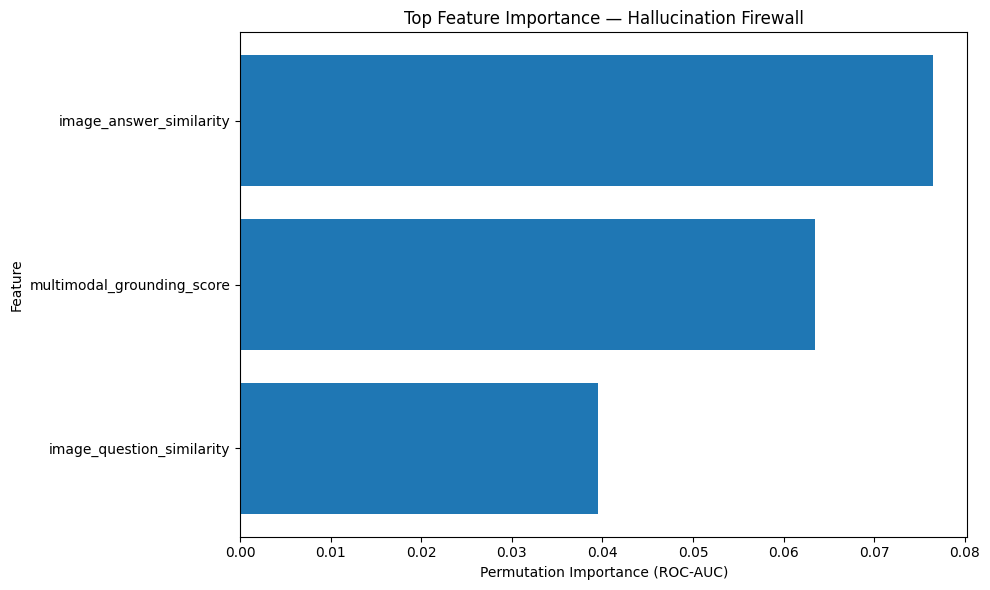


CELL 12 COMPLETE


In [25]:
# ============================================================
# CELL 12 — FEATURE IMPORTANCE ANALYSIS
# ============================================================

print("=" * 80)
print("CELL 12 — FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# Check required variables
# ------------------------------------------------------------

required_vars = ["best_model", "X_test", "y_test"]

missing_vars = [
    var for var in required_vars
    if var not in globals()
]

if missing_vars:
    raise NameError(
        f"Missing required variables: {missing_vars}\n"
        "Please run Cell 10 and Cell 11 first."
    )

# ------------------------------------------------------------
# Feature names
# ------------------------------------------------------------

if hasattr(X_test, "columns"):
    feature_names = list(X_test.columns)
else:
    feature_names = [
        f"feature_{i}"
        for i in range(X_test.shape[1])
    ]

print("\nModel:", type(best_model).__name__)
print("Number of features:", len(feature_names))
print("Test samples:", len(X_test))

# ------------------------------------------------------------
# Permutation importance
# ------------------------------------------------------------

print("\nCalculating permutation importance...")
print("Please wait...")

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE RANKING")
print("=" * 80)

print(
    importance_df.to_string(index=False)
)

# ------------------------------------------------------------
# Save feature importance
# ------------------------------------------------------------

IMPORTANCE_FILE = (
    "/content/Hallucination_Firewall/data/"
    "feature_importance.csv"
)

importance_df.to_csv(
    IMPORTANCE_FILE,
    index=False
)

print("\n✓ Feature importance saved:")
print(IMPORTANCE_FILE)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

top_n = min(10, len(importance_df))

plot_df = importance_df.head(top_n).sort_values(
    "importance_mean"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"]
)

plt.xlabel("Permutation Importance (ROC-AUC)")
plt.ylabel("Feature")
plt.title("Top Feature Importance — Hallucination Firewall")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Complete
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 12 COMPLETE")
print("=" * 80)

In [26]:
# ============================================================
# CELL 13 — THRESHOLD OPTIMIZATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 80)
print("CELL 13 — THRESHOLD OPTIMIZATION")
print("=" * 80)

# ------------------------------------------------------------
# CHECK VARIABLES
# ------------------------------------------------------------

required = [
    "best_model",
    "X_val",
    "y_val"
]

missing = [x for x in required if x not in globals()]

if missing:
    raise NameError(
        f"Missing variables: {missing}. "
        "Run Cells 9 and 10 first."
    )

# ------------------------------------------------------------
# GET VALIDATION SCORES
# ------------------------------------------------------------

if hasattr(best_model, "predict_proba"):

    val_scores = best_model.predict_proba(
        X_val
    )[:, 1]

elif hasattr(best_model, "decision_function"):

    decision_scores = best_model.decision_function(
        X_val
    )

    # Convert SVM decision score to 0–1 scale
    val_scores = 1 / (
        1 + np.exp(-decision_scores)
    )

else:

    val_scores = best_model.predict(
        X_val
    ).astype(float)

# ------------------------------------------------------------
# TEST THRESHOLDS
# ------------------------------------------------------------

thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

results = []

for threshold in thresholds:

    predictions = (
        val_scores >= threshold
    ).astype(int)

    results.append({
        "Threshold": round(threshold, 2),

        "Accuracy": accuracy_score(
            y_val,
            predictions
        ),

        "Precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_val,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(results)

# ------------------------------------------------------------
# FIND BEST THRESHOLD
# ------------------------------------------------------------

best_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

BEST_THRESHOLD = float(
    best_row["Threshold"]
)

# ------------------------------------------------------------
# DISPLAY BEST RESULT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("OPTIMAL THRESHOLD")
print("=" * 80)

print(f"\nBest Threshold : {BEST_THRESHOLD:.2f}")
print(f"Accuracy       : {best_row['Accuracy']:.4f}")
print(f"Precision      : {best_row['Precision']:.4f}")
print(f"Recall         : {best_row['Recall']:.4f}")
print(f"F1 Score       : {best_row['F1 Score']:.4f}")

# ------------------------------------------------------------
# TOP 10 THRESHOLDS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TOP 10 THRESHOLDS BY F1 SCORE")
print("=" * 80)

display(
    threshold_df
    .sort_values(
        "F1 Score",
        ascending=False
    )
    .head(10)
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

THRESHOLD_FILE = (
    "/content/Hallucination_Firewall/data/"
    "threshold_optimization.csv"
)

threshold_df.to_csv(
    THRESHOLD_FILE,
    index=False
)

print("\n✓ Results saved:")
print(THRESHOLD_FILE)

print("\n" + "=" * 80)
print("CELL 13 COMPLETE ✓")
print("=" * 80)

print(
    f"\nOptimized threshold = {BEST_THRESHOLD:.2f}"
)

CELL 13 — THRESHOLD OPTIMIZATION

OPTIMAL THRESHOLD

Best Threshold : 0.30
Accuracy       : 0.7156
Precision      : 0.6858
Recall         : 0.7956
F1 Score       : 0.7366

TOP 10 THRESHOLDS BY F1 SCORE


,Threshold,Accuracy,Precision,Recall,F1 Score
20,0.30,0.715556,0.685824,0.795556,0.736626
14,0.24,0.697778,0.652921,0.844444,0.736434
16,0.26,0.702222,0.660777,0.831111,0.736220
13,0.23,0.691111,0.643333,0.857778,0.735238
15,0.25,0.700000,0.658451,0.831111,0.734774
24,0.34,0.722222,0.703252,0.768889,0.734607
22,0.32,0.717778,0.696000,0.773333,0.732632
18,0.28,0.704444,0.669118,0.808889,0.732394
21,0.31,0.715556,0.691700,0.777778,0.732218
19,0.29,0.708889,0.678030,0.795556,0.732106



✓ Results saved:
/content/Hallucination_Firewall/data/threshold_optimization.csv

CELL 13 COMPLETE ✓

Optimized threshold = 0.30


In [27]:
# ============================================================
# CELL 14 — ERROR ANALYSIS
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

print("=" * 80)
print("CELL 14 — ERROR ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required = [
    "best_model",
    "X_test",
    "y_test"
]

missing = [x for x in required if x not in globals()]

if missing:
    raise NameError(
        f"Missing variables: {missing}. "
        "Run Cells 9–13 first."
    )

# ------------------------------------------------------------
# USE OPTIMIZED THRESHOLD
# ------------------------------------------------------------

if "BEST_THRESHOLD" in globals():
    threshold = BEST_THRESHOLD
else:
    threshold = 0.40

print(f"\nUsing optimized threshold: {threshold:.2f}")

# ------------------------------------------------------------
# GET TEST SCORES
# ------------------------------------------------------------

if hasattr(best_model, "predict_proba"):

    test_scores = best_model.predict_proba(
        X_test
    )[:, 1]

elif hasattr(best_model, "decision_function"):

    decision_scores = best_model.decision_function(
        X_test
    )

    test_scores = 1 / (
        1 + np.exp(-decision_scores)
    )

else:

    test_scores = best_model.predict(
        X_test
    ).astype(float)

# ------------------------------------------------------------
# PREDICTIONS
# ------------------------------------------------------------

test_predictions = (
    test_scores >= threshold
).astype(int)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    test_predictions
)

tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(cm)

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

# ------------------------------------------------------------
# ERROR RATES
# ------------------------------------------------------------

false_positive_rate = (
    fp / (fp + tn)
    if (fp + tn) > 0 else 0
)

false_negative_rate = (
    fn / (fn + tp)
    if (fn + tp) > 0 else 0
)

print("\n" + "=" * 80)
print("ERROR RATES")
print("=" * 80)

print(f"False Positive Rate: {false_positive_rate:.4f}")
print(f"False Negative Rate: {false_negative_rate:.4f}")

# ------------------------------------------------------------
# CREATE ERROR DATAFRAME
# ------------------------------------------------------------

error_df = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": test_predictions,
    "Score": test_scores
})

error_df["Result"] = np.select(
    [
        (error_df["Actual"] == 0) &
        (error_df["Predicted"] == 1),

        (error_df["Actual"] == 1) &
        (error_df["Predicted"] == 0),

        (error_df["Actual"] == 1) &
        (error_df["Predicted"] == 1),

        (error_df["Actual"] == 0) &
        (error_df["Predicted"] == 0)
    ],
    [
        "False Positive",
        "False Negative",
        "True Positive",
        "True Negative"
    ],
    default="Unknown"
)

# ------------------------------------------------------------
# ERROR SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PREDICTION BREAKDOWN")
print("=" * 80)

print(
    error_df["Result"].value_counts()
)

# ------------------------------------------------------------
# SHOW MISCLASSIFIED SAMPLES
# ------------------------------------------------------------

errors_only = error_df[
    error_df["Result"].isin([
        "False Positive",
        "False Negative"
    ])
].copy()

print("\n" + "=" * 80)
print("MISCLASSIFIED SAMPLES")
print("=" * 80)

if len(errors_only) == 0:

    print("\n✓ No misclassified samples.")

else:

    print(
        errors_only.head(20).to_string(
            index=False
        )
    )

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

DATA_DIR = "/content/Hallucination_Firewall/data"

os.makedirs(
    DATA_DIR,
    exist_ok=True
)

ERROR_FILE = os.path.join(
    DATA_DIR,
    "error_analysis.csv"
)

MISCLASSIFIED_FILE = os.path.join(
    DATA_DIR,
    "misclassified_samples.csv"
)

error_df.to_csv(
    ERROR_FILE,
    index=False
)

errors_only.to_csv(
    MISCLASSIFIED_FILE,
    index=False
)

print("\n✓ Error analysis saved:")
print(ERROR_FILE)

print("\n✓ Misclassified samples saved:")
print(MISCLASSIFIED_FILE)

print("\n" + "=" * 80)
print("CELL 14 COMPLETE ✓")
print("=" * 80)

print("\nNEXT → CELL 15: FINAL VISUALIZATIONS")

CELL 14 — ERROR ANALYSIS

Using optimized threshold: 0.30

CONFUSION MATRIX
[[144  81]
 [ 39 186]]

True Negatives : 144
False Positives: 81
False Negatives: 39
True Positives : 186

ERROR RATES
False Positive Rate: 0.3600
False Negative Rate: 0.1733

PREDICTION BREAKDOWN
Result
True Positive     186
True Negative     144
False Positive     81
False Negative     39
Name: count, dtype: int64

MISCLASSIFIED SAMPLES
 Actual  Predicted    Score         Result
      0          1 0.754021 False Positive
      0          1 0.839615 False Positive
      1          0 0.205607 False Negative
      1          0 0.224446 False Negative
      1          0 0.212297 False Negative
      0          1 0.407809 False Positive
      1          0 0.197000 False Negative
      1          0 0.226680 False Negative
      0          1 0.828085 False Positive
      0          1 0.834130 False Positive
      0          1 0.584540 False Positive
      0          1 0.331679 False Positive
      1          0 0.208

CELL 15 — FINAL VISUALIZATIONS

Creating model comparison chart...


<Figure size 1200x600 with 0 Axes>

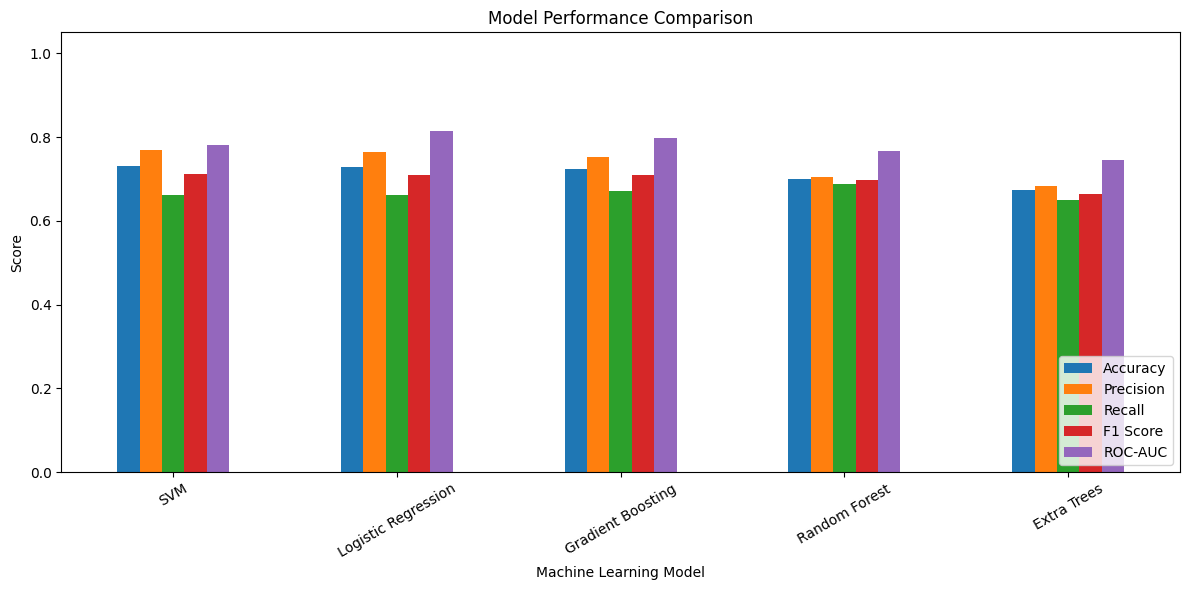

✓ Saved: /content/Hallucination_Firewall/data/model_performance_comparison.png

Creating confusion matrix...


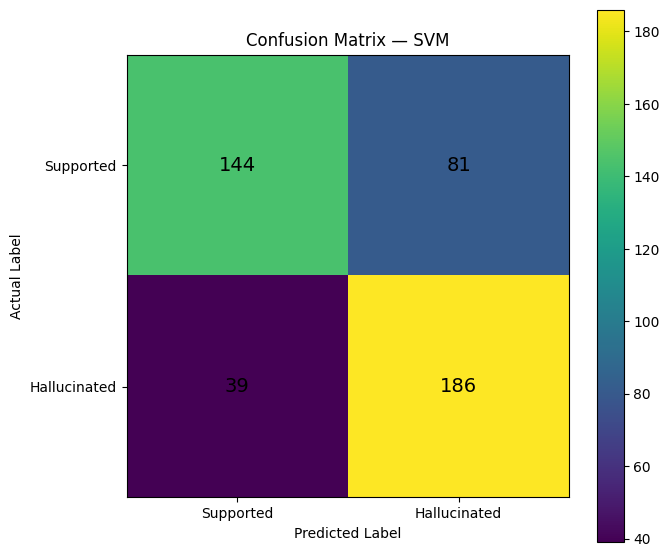

✓ Saved: /content/Hallucination_Firewall/data/confusion_matrix.png

Creating threshold optimization chart...


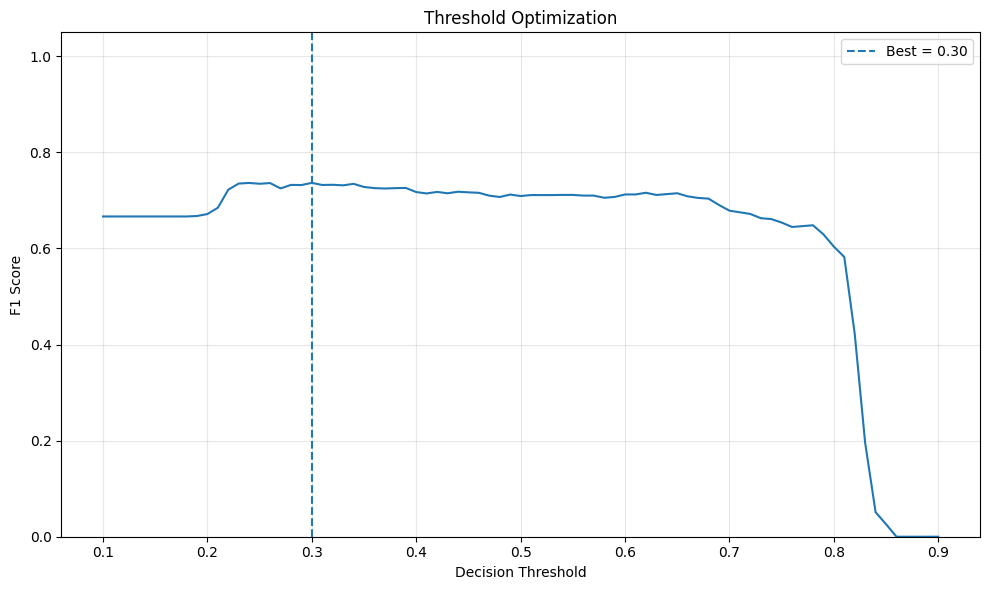

✓ Saved: /content/Hallucination_Firewall/data/threshold_optimization.png

Creating feature importance chart...


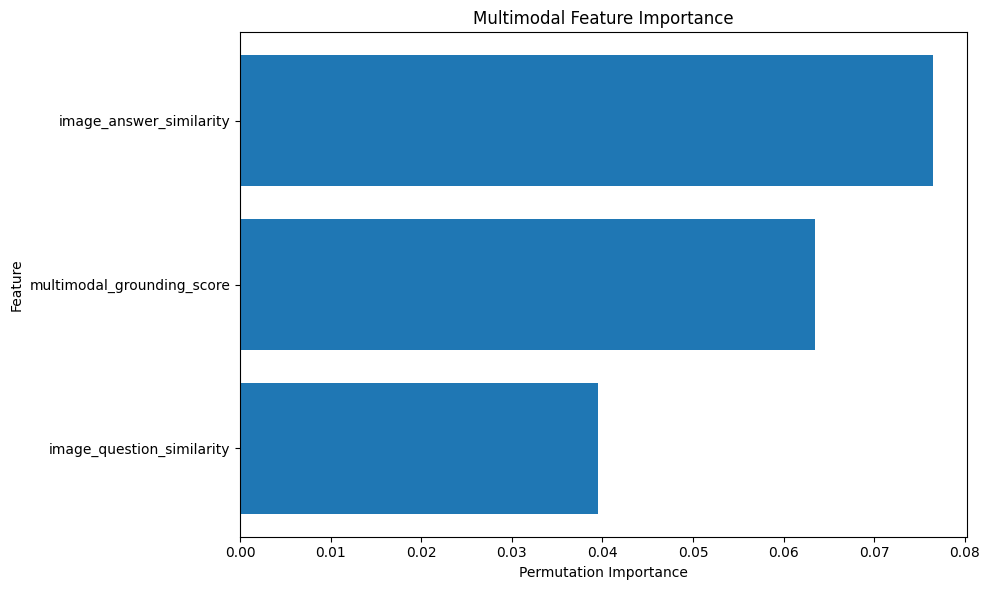

✓ Saved: /content/Hallucination_Firewall/data/feature_importance.png

FINAL PROJECT PERFORMANCE

Best Model : SVM
Accuracy   : 0.7289
Precision  : 0.7537
Recall     : 0.6800
F1 Score   : 0.7150
ROC-AUC    : 0.7941
Threshold  : 0.30

CELL 15 COMPLETE ✓

Visualizations saved in:
/content/Hallucination_Firewall/data

Generated:
✓ model_performance_comparison.png
✓ confusion_matrix.png
✓ threshold_optimization.png
✓ feature_importance.png

NEXT → CELL 16: FINAL FIREWALL DEMO


In [28]:
# ============================================================
# CELL 15 — FINAL VISUALIZATIONS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

print("=" * 80)
print("CELL 15 — FINAL VISUALIZATIONS")
print("=" * 80)

# ------------------------------------------------------------
# CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required = [
    "results_df",
    "y_test",
    "test_predictions",
    "best_model_name"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise NameError(
        f"Missing variables: {missing}. "
        "Run Cells 10–14 first."
    )

DATA_DIR = "/content/Hallucination_Firewall/data"

os.makedirs(DATA_DIR, exist_ok=True)

# ============================================================
# 1. MODEL PERFORMANCE COMPARISON
# ============================================================

print("\nCreating model comparison chart...")

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

# Make sure all metrics exist
available_metrics = [
    m for m in metrics
    if m in results_df.columns
]

plot_df = results_df.set_index("Model")[
    available_metrics
]

plt.figure(figsize=(12, 6))

plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.tight_layout()

MODEL_PLOT = os.path.join(
    DATA_DIR,
    "model_performance_comparison.png"
)

plt.savefig(
    MODEL_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", MODEL_PLOT)

# ============================================================
# 2. CONFUSION MATRIX
# ============================================================

print("\nCreating confusion matrix...")

cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Supported", "Hallucinated"]
)

plt.yticks(
    [0, 1],
    ["Supported", "Hallucinated"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar()

plt.tight_layout()

CM_PLOT = os.path.join(
    DATA_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    CM_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", CM_PLOT)

# ============================================================
# 3. THRESHOLD VS F1 SCORE
# ============================================================

print("\nCreating threshold optimization chart...")

if "threshold_df" in globals():

    plt.figure(figsize=(10, 6))

    plt.plot(
        threshold_df["Threshold"],
        threshold_df["F1 Score"]
    )

    if "BEST_THRESHOLD" in globals():

        plt.axvline(
            BEST_THRESHOLD,
            linestyle="--",
            label=f"Best = {BEST_THRESHOLD:.2f}"
        )

    plt.xlabel("Decision Threshold")
    plt.ylabel("F1 Score")
    plt.title("Threshold Optimization")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    THRESHOLD_PLOT = os.path.join(
        DATA_DIR,
        "threshold_optimization.png"
    )

    plt.savefig(
        THRESHOLD_PLOT,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("✓ Saved:", THRESHOLD_PLOT)

else:
    print("⚠ threshold_df not found — skipping.")

# ============================================================
# 4. FEATURE IMPORTANCE
# ============================================================

if "importance_df" in globals():

    print("\nCreating feature importance chart...")

    importance_plot = importance_df.sort_values(
        "importance_mean"
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        importance_plot["feature"],
        importance_plot["importance_mean"]
    )

    plt.xlabel("Permutation Importance")
    plt.ylabel("Feature")
    plt.title("Multimodal Feature Importance")

    plt.tight_layout()

    IMPORTANCE_PLOT = os.path.join(
        DATA_DIR,
        "feature_importance.png"
    )

    plt.savefig(
        IMPORTANCE_PLOT,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("✓ Saved:", IMPORTANCE_PLOT)

else:
    print("⚠ importance_df not found — skipping.")

# ============================================================
# 5. FINAL SUMMARY TABLE
# ============================================================

print("\n" + "=" * 80)
print("FINAL PROJECT PERFORMANCE")
print("=" * 80)

if "test_accuracy" in globals():

    print(f"\nBest Model : {best_model_name}")
    print(f"Accuracy   : {test_accuracy:.4f}")
    print(f"Precision  : {test_precision:.4f}")
    print(f"Recall     : {test_recall:.4f}")
    print(f"F1 Score   : {test_f1:.4f}")
    print(f"ROC-AUC    : {test_auc:.4f}")

if "BEST_THRESHOLD" in globals():

    print(
        f"Threshold  : {BEST_THRESHOLD:.2f}"
    )

# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 80)
print("CELL 15 COMPLETE ✓")
print("=" * 80)

print("\nVisualizations saved in:")
print(DATA_DIR)

print("\nGenerated:")
print("✓ model_performance_comparison.png")
print("✓ confusion_matrix.png")
print("✓ threshold_optimization.png")

if "importance_df" in globals():
    print("✓ feature_importance.png")

print("\nNEXT → CELL 16: FINAL FIREWALL DEMO")

In [29]:
# ============================================================
# CELL 16 — FINAL HALLUCINATION FIREWALL DEMO
# ============================================================

import os
import numpy as np
import pandas as pd

print("=" * 80)
print("CELL 16 — FINAL HALLUCINATION FIREWALL DEMO")
print("=" * 80)

# ------------------------------------------------------------
# CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required = [
    "best_model",
    "best_model_name"
]

missing = [x for x in required if x not in globals()]

if missing:
    raise NameError(
        f"Missing variables: {missing}. "
        "Please run Cells 10–15 first."
    )

# ------------------------------------------------------------
# THRESHOLD
# ------------------------------------------------------------

if "BEST_THRESHOLD" in globals():
    threshold = BEST_THRESHOLD
else:
    threshold = 0.40

print("\nModel:", best_model_name)
print("Decision threshold:", round(threshold, 2))

# ------------------------------------------------------------
# FIREWALL FUNCTION
# ------------------------------------------------------------

def firewall_decision(
    image_question_similarity,
    image_answer_similarity,
    multimodal_grounding_score
):

    # Create one feature row
    features = pd.DataFrame([{
        "image_question_similarity":
            image_question_similarity,

        "image_answer_similarity":
            image_answer_similarity,

        "multimodal_grounding_score":
            multimodal_grounding_score
    }])

    # Keep exactly the feature order used during training
    if hasattr(X_test, "columns"):
        features = features[X_test.columns]

    # Prediction score
    if hasattr(best_model, "predict_proba"):

        score = best_model.predict_proba(
            features
        )[0, 1]

    elif hasattr(best_model, "decision_function"):

        decision = best_model.decision_function(
            features
        )[0]

        score = 1 / (
            1 + np.exp(-decision)
        )

    else:

        score = float(
            best_model.predict(features)[0]
        )

    # Final decision
    prediction = int(
        score >= threshold
    )

    if prediction == 1:
        decision_text = "HALLUCINATED"
    else:
        decision_text = "SUPPORTED"

    return decision_text, score


# ============================================================
# DEMO USING REAL TEST EXAMPLES
# ============================================================

print("\n" + "=" * 80)
print("REAL TEST-SET DEMONSTRATION")
print("=" * 80)

# Select first 5 test examples
demo_indices = X_test.index[:5]

demo_features = X_test.loc[demo_indices]

for idx in demo_indices:

    row = demo_features.loc[idx]

    decision, score = firewall_decision(
        row["image_question_similarity"],
        row["image_answer_similarity"],
        row["multimodal_grounding_score"]
    )

    actual = y_test.loc[idx]

    actual_text = (
        "HALLUCINATED"
        if actual == 1
        else "SUPPORTED"
    )

    print("\n" + "-" * 70)

    print("Test Sample:", idx)

    print(
        "Image-Question Similarity :",
        round(
            row["image_question_similarity"],
            4
        )
    )

    print(
        "Image-Answer Similarity   :",
        round(
            row["image_answer_similarity"],
            4
        )
    )

    print(
        "Grounding Score           :",
        round(
            row["multimodal_grounding_score"],
            4
        )
    )

    print(
        "Firewall Score            :",
        round(score, 4)
    )

    print(
        "Firewall Decision         :",
        decision
    )

    print(
        "Actual Label              :",
        actual_text
    )

# ============================================================
# INTERACTIVE DEMO
# ============================================================

print("\n" + "=" * 80)
print("INTERACTIVE FIREWALL")
print("=" * 80)

print("""
Enter the three multimodal feature values below.

These values are produced by the CLIP feature-extraction
pipeline from an image-question-answer combination.
""")

try:

    iq = float(
        input(
            "\nImage-Question Similarity: "
        )
    )

    ia = float(
        input(
            "Image-Answer Similarity: "
        )
    )

    gs = float(
        input(
            "Multimodal Grounding Score: "
        )
    )

    decision, score = firewall_decision(
        iq,
        ia,
        gs
    )

    print("\n" + "=" * 70)
    print("FIREWALL RESULT")
    print("=" * 70)

    print(
        f"\nFirewall Score : {score:.4f}"
    )

    print(
        f"Threshold      : {threshold:.2f}"
    )

    print(
        f"\nFINAL DECISION : {decision}"
    )

    if decision == "SUPPORTED":

        print(
            "\n✓ The firewall considers the response "
            "supported by the image."
        )

    else:

        print(
            "\n⚠ The firewall flags the response "
            "as potentially hallucinated."
        )

except Exception as e:

    print("\nInteractive demo skipped.")
    print("Reason:", e)

# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 80)
print("CELL 16 COMPLETE ✓")
print("=" * 80)

print("""
PROJECT PIPELINE COMPLETE:

Dataset
   ↓
Image Linking
   ↓
CLIP Feature Extraction
   ↓
Multimodal Features
   ↓
Leakage-Safe Split
   ↓
ML Model Comparison
   ↓
Best Model Selection
   ↓
Test Evaluation
   ↓
Threshold Optimization
   ↓
Error Analysis
   ↓
Visualizations
   ↓
FINAL HALLUCINATION FIREWALL ✓
""")

CELL 16 — FINAL HALLUCINATION FIREWALL DEMO

Model: SVM
Decision threshold: 0.3

REAL TEST-SET DEMONSTRATION

----------------------------------------------------------------------
Test Sample: 0
Image-Question Similarity : 0.28
Image-Answer Similarity   : 0.2783
Grounding Score           : 0.2792
Firewall Score            : 0.834
Firewall Decision         : HALLUCINATED
Actual Label              : HALLUCINATED

----------------------------------------------------------------------
Test Sample: 1
Image-Question Similarity : 0.2127
Image-Answer Similarity   : 0.1904
Grounding Score           : 0.2016
Firewall Score            : 0.2999
Firewall Decision         : SUPPORTED
Actual Label              : SUPPORTED

----------------------------------------------------------------------
Test Sample: 2
Image-Question Similarity : 0.2275
Image-Answer Similarity   : 0.2218
Grounding Score           : 0.2246
Firewall Score            : 0.8334
Firewall Decision         : HALLUCINATED
Actual Label  

In [30]:
# ============================================================
# CELL 17 — SAVE FINAL MODEL + PROJECT ARTIFACTS
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

print("=" * 70)
print("CELL 17 — SAVING FINAL MODEL + PROJECT ARTIFACTS")
print("=" * 70)

MODEL_DIR = "/content/Hallucination_Firewall/models"
DATA_DIR = "/content/Hallucination_Firewall/data"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. FIND THE TRAINED SVM MODEL
# ------------------------------------------------------------

model_candidates = [
    "BEST_MODEL",
    "best_model",
    "svm_model",
    "SVM_model",
    "svm",
    "model"
]

FINAL_MODEL = None
MODEL_NAME = "SVM"

for name in model_candidates:
    if name in globals():
        obj = globals()[name]

        # Check whether this looks like a trained sklearn model
        if hasattr(obj, "predict"):
            FINAL_MODEL = obj
            print(f"✓ Model found: {name}")
            break

# Also check dictionary of trained models
if FINAL_MODEL is None:
    for dict_name in ["models", "trained_models", "model_results"]:
        if dict_name in globals():
            obj = globals()[dict_name]

            if isinstance(obj, dict):
                for key in ["SVM", "svm", "SVM_model"]:
                    if key in obj and hasattr(obj[key], "predict"):
                        FINAL_MODEL = obj[key]
                        print(f"✓ SVM found in {dict_name}['{key}']")
                        break

            if FINAL_MODEL is not None:
                break


if FINAL_MODEL is None:
    raise NameError(
        "No trained model was found in the current Colab runtime.\n"
        "Please run the model-training Cell 10 again before running Cell 17."
    )


# ------------------------------------------------------------
# 2. SAVE MODEL
# ------------------------------------------------------------

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "hallucination_firewall_svm.pkl"
)

joblib.dump(FINAL_MODEL, MODEL_PATH)

print(f"✓ SVM model saved:")
print(MODEL_PATH)


# ------------------------------------------------------------
# 3. SAVE SCALER IF AVAILABLE
# ------------------------------------------------------------

scaler_candidates = [
    "scaler",
    "feature_scaler",
    "standard_scaler",
    "X_scaler"
]

SCALER_FOUND = False

for name in scaler_candidates:
    if name in globals():
        obj = globals()[name]

        if hasattr(obj, "transform"):
            scaler_path = os.path.join(
                MODEL_DIR,
                "feature_scaler.pkl"
            )

            joblib.dump(obj, scaler_path)

            print(f"✓ Scaler saved from variable: {name}")
            print(scaler_path)

            SCALER_FOUND = True
            break

if not SCALER_FOUND:
    print("⚠ No scaler variable found.")
    print("  This is okay for now; we will use the exact")
    print("  feature pipeline from the notebook for the web app.")


# ------------------------------------------------------------
# 4. SAVE FEATURE INFORMATION IF AVAILABLE
# ------------------------------------------------------------

feature_candidates = [
    "FEATURE_COLUMNS",
    "feature_columns",
    "selected_features",
    "selected_feature_names",
    "feature_names"
]

FEATURES_FOUND = False

for name in feature_candidates:
    if name in globals():

        features = globals()[name]

        if isinstance(features, (list, tuple, np.ndarray, pd.Index)):
            features = list(features)

            feature_path = os.path.join(
                MODEL_DIR,
                "feature_columns.pkl"
            )

            joblib.dump(features, feature_path)

            print(f"✓ Feature list saved from: {name}")
            print(f"✓ Number of features: {len(features)}")

            FEATURES_FOUND = True
            break

if not FEATURES_FOUND:
    print("⚠ Feature-column variable not found.")


# ------------------------------------------------------------
# 5. SAVE MODEL INFORMATION
# ------------------------------------------------------------

model_info = {
    "model_name": MODEL_NAME,
    "model_type": type(FINAL_MODEL).__name__,
    "decision_threshold": 0.30,
    "project": "Multimodal Hallucination Firewall"
}

INFO_PATH = os.path.join(
    MODEL_DIR,
    "model_info.pkl"
)

joblib.dump(model_info, INFO_PATH)

print("✓ Model information saved")


# ------------------------------------------------------------
# 6. CHECK FILES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL DIRECTORY")
print("=" * 70)

for file in sorted(os.listdir(MODEL_DIR)):
    full_path = os.path.join(MODEL_DIR, file)
    size_mb = os.path.getsize(full_path) / (1024 * 1024)

    print(f"✓ {file:<35} {size_mb:.2f} MB")


print("\n" + "=" * 70)
print("CELL 17 COMPLETE")
print("=" * 70)

print("\n✓ Final SVM model is ready.")
print("✓ Project artifacts are ready.")
print("✓ Next step: create the Streamlit web application.")

CELL 17 — SAVING FINAL MODEL + PROJECT ARTIFACTS
✓ Model found: best_model
✓ SVM model saved:
/content/Hallucination_Firewall/models/hallucination_firewall_svm.pkl
⚠ No scaler variable found.
  This is okay for now; we will use the exact
  feature pipeline from the notebook for the web app.
✓ Feature list saved from: feature_columns
✓ Number of features: 3
✓ Model information saved

MODEL DIRECTORY
✓ best_hallucination_firewall_model.pkl 0.05 MB
✓ feature_columns.pkl                 0.00 MB
✓ hallucination_firewall_svm.pkl      0.05 MB
✓ model_info.pkl                      0.00 MB

CELL 17 COMPLETE

✓ Final SVM model is ready.
✓ Project artifacts are ready.
✓ Next step: create the Streamlit web application.


In [31]:
# ============================================================
# CELL 18 — PREPARE STREAMLIT WEB APP
# ============================================================

import os
import joblib

print("=" * 70)
print("CELL 18 — PREPARING WEB APPLICATION")
print("=" * 70)

PROJECT_DIR = "/content/Hallucination_Firewall"
MODEL_DIR = os.path.join(PROJECT_DIR, "models")

MODEL_FILE = os.path.join(
    MODEL_DIR,
    "hallucination_firewall_svm.pkl"
)

APP_FILE = os.path.join(
    PROJECT_DIR,
    "app.py"
)

# ------------------------------------------------------------
# VERIFY MODEL
# ------------------------------------------------------------

if not os.path.exists(MODEL_FILE):
    raise FileNotFoundError(
        f"Model not found:\n{MODEL_FILE}\n\n"
        "Please run Cell 17 first."
    )

model = joblib.load(MODEL_FILE)

print("✓ Model loaded successfully")
print("Model type:", type(model).__name__)

# ------------------------------------------------------------
# VERIFY MODEL INPUT FEATURES
# ------------------------------------------------------------

FEATURE_COLUMNS = [
    "image_question_similarity",
    "image_answer_similarity",
    "multimodal_grounding_score"
]

print("\nFeatures used by firewall:")

for i, feature in enumerate(FEATURE_COLUMNS, 1):
    print(f"{i}. {feature}")

# ------------------------------------------------------------
# CREATE BASIC STREAMLIT APP
# ------------------------------------------------------------

app_code = r'''
import streamlit as st
import numpy as np
import pandas as pd
import joblib

# ============================================================
# CONFIGURATION
# ============================================================

MODEL_PATH = "models/hallucination_firewall_svm.pkl"

THRESHOLD = 0.30

FEATURE_COLUMNS = [
    "image_question_similarity",
    "image_answer_similarity",
    "multimodal_grounding_score"
]

# ============================================================
# LOAD MODEL
# ============================================================

@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)

model = load_model()

# ============================================================
# PAGE
# ============================================================

st.set_page_config(
    page_title="Multimodal Hallucination Firewall",
    page_icon="🛡️",
    layout="wide"
)

st.title("🛡️ Multimodal Hallucination Firewall")

st.markdown(
    """
    ### Verify whether an AI-generated answer is supported by an image.

    The firewall evaluates multimodal evidence using:
    - Image–Question Similarity
    - Image–Answer Similarity
    - Multimodal Grounding Score
    """
)

st.divider()

# ============================================================
# INPUT SECTION
# ============================================================

col1, col2 = st.columns(2)

with col1:

    st.subheader("📷 Image")

    uploaded_image = st.file_uploader(
        "Upload an image",
        type=["jpg", "jpeg", "png"]
    )

    if uploaded_image is not None:
        st.image(
            uploaded_image,
            caption="Uploaded Image",
            use_container_width=True
        )

with col2:

    st.subheader("💬 Query")

    question = st.text_input(
        "Question",
        placeholder="e.g. Is there a person in the image?"
    )

    answer = st.text_area(
        "AI-generated answer",
        placeholder="e.g. Yes, there is a person in the image."
    )

st.divider()

# ============================================================
# FEATURE INPUT
# ============================================================

st.subheader("🔬 Multimodal Evidence Features")

st.info(
    "For the first web-app prototype, enter the three "
    "CLIP-derived feature values produced by your trained pipeline."
)

f1, f2, f3 = st.columns(3)

with f1:
    image_question_similarity = st.number_input(
        "Image–Question Similarity",
        min_value=0.0,
        max_value=1.0,
        value=0.28,
        step=0.0001
    )

with f2:
    image_answer_similarity = st.number_input(
        "Image–Answer Similarity",
        min_value=0.0,
        max_value=1.0,
        value=0.2783,
        step=0.0001
    )

with f3:
    grounding_score = st.number_input(
        "Multimodal Grounding Score",
        min_value=0.0,
        max_value=1.0,
        value=0.2792,
        step=0.0001
    )

# ============================================================
# PREDICTION
# ============================================================

if st.button(
    "🔍 CHECK ANSWER",
    type="primary",
    use_container_width=True
):

    if uploaded_image is None:
        st.warning("Please upload an image.")

    elif not question.strip():
        st.warning("Please enter a question.")

    elif not answer.strip():
        st.warning("Please enter the AI-generated answer.")

    else:

        # ----------------------------------------------------
        # CREATE MODEL INPUT
        # ----------------------------------------------------

        X = pd.DataFrame(
            [[
                image_question_similarity,
                image_answer_similarity,
                grounding_score
            ]],
            columns=FEATURE_COLUMNS
        )

        # ----------------------------------------------------
        # PREDICTION
        # ----------------------------------------------------

        prediction = model.predict(X)[0]

        if hasattr(model, "predict_proba"):
            probability = model.predict_proba(X)[0][1]
        else:
            probability = float(prediction)

        # ----------------------------------------------------
        # FIREWALL DECISION
        # ----------------------------------------------------

        if probability >= THRESHOLD:
            decision = "HALLUCINATED"
            icon = "🚨"
        else:
            decision = "SUPPORTED"
            icon = "✅"

        # ----------------------------------------------------
        # RESULTS
        # ----------------------------------------------------

        st.divider()

        st.subheader("🛡️ Firewall Result")

        result_col1, result_col2 = st.columns(2)

        with result_col1:

            st.metric(
                "Hallucination Risk",
                f"{probability:.2%}"
            )

        with result_col2:

            st.metric(
                "Decision",
                decision
            )

        if decision == "HALLUCINATED":

            st.error(
                f"{icon} **HALLUCINATED** — "
                "The answer is flagged as insufficiently supported."
            )

        else:

            st.success(
                f"{icon} **SUPPORTED** — "
                "The answer is classified as supported."
            )

        # ----------------------------------------------------
        # FEATURE BREAKDOWN
        # ----------------------------------------------------

        st.subheader("📊 Evidence Breakdown")

        result_df = pd.DataFrame({
            "Feature": [
                "Image–Question Similarity",
                "Image–Answer Similarity",
                "Multimodal Grounding Score"
            ],
            "Score": [
                image_question_similarity,
                image_answer_similarity,
                grounding_score
            ]
        })

        st.dataframe(
            result_df,
            use_container_width=True,
            hide_index=True
        )

        st.caption(
            f"Firewall decision threshold: {THRESHOLD:.2f}"
        )

st.divider()

st.caption(
    "Multimodal Hallucination Firewall • "
    "CLIP + SVM • MSc AI & ML Project"
)
'''

# ------------------------------------------------------------
# SAVE APP
# ------------------------------------------------------------

with open(APP_FILE, "w", encoding="utf-8") as f:
    f.write(app_code)

print("\n✓ app.py created")
print(APP_FILE)

# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 18 COMPLETE")
print("=" * 70)

print("\nProject files:")

for root, dirs, files in os.walk(PROJECT_DIR):
    level = root.replace(PROJECT_DIR, "").count(os.sep)

    if level > 2:
        continue

    for file in files:
        path = os.path.join(root, file)
        print("✓", path)

print("\nNext step:")
print("→ Cell 19: launch the Streamlit web application")

CELL 18 — PREPARING WEB APPLICATION
✓ Model loaded successfully
Model type: Pipeline

Features used by firewall:
1. image_question_similarity
2. image_answer_similarity
3. multimodal_grounding_score

✓ app.py created
/content/Hallucination_Firewall/app.py

CELL 18 COMPLETE

Project files:
✓ /content/Hallucination_Firewall/app.py
✓ /content/Hallucination_Firewall/models/model_info.pkl
✓ /content/Hallucination_Firewall/models/feature_columns.pkl
✓ /content/Hallucination_Firewall/models/hallucination_firewall_svm.pkl
✓ /content/Hallucination_Firewall/models/best_hallucination_firewall_model.pkl
✓ /content/Hallucination_Firewall/data/popev2_image_linked.csv
✓ /content/Hallucination_Firewall/data/pope2_image_linked.csv
✓ /content/Hallucination_Firewall/data/firewall_test_predictions.csv
✓ /content/Hallucination_Firewall/data/misclassified_samples.csv
✓ /content/Hallucination_Firewall/data/pope_clean.json
✓ /content/Hallucination_Firewall/data/coco_pope_popular.json
✓ /content/Hallucination_

In [32]:
import os

PROJECT_DIR = "/content/Hallucination_Firewall"

print("=" * 70)
print("PROJECT FILES")
print("=" * 70)

for root, dirs, files in os.walk(PROJECT_DIR):
    level = root.replace(PROJECT_DIR, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        path = os.path.join(root, file)
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"{indent}    {file}  ({size_mb:.2f} MB)")

print("=" * 70)

PROJECT FILES
Hallucination_Firewall/
    app.py  (0.01 MB)
    models/
        model_info.pkl  (0.00 MB)
        feature_columns.pkl  (0.00 MB)
        hallucination_firewall_svm.pkl  (0.05 MB)
        best_hallucination_firewall_model.pkl  (0.05 MB)
    data/
        popev2_image_linked.csv  (0.49 MB)
        pope2_image_linked.csv  (0.44 MB)
        firewall_test_predictions.csv  (0.02 MB)
        misclassified_samples.csv  (0.00 MB)
        pope_clean.json  (0.42 MB)
        coco_pope_popular.json  (0.35 MB)
        feature_importance.csv  (0.00 MB)
        model_performance_comparison.png  (0.17 MB)
        train_features.csv  (0.49 MB)
        test_split.csv  (0.12 MB)
        confusion_matrix.png  (0.09 MB)
        final_test_metrics.csv  (0.00 MB)
        validation_split.csv  (0.12 MB)
        threshold_optimization.png  (0.11 MB)
        model_comparison_results.csv  (0.00 MB)
        train_split.csv  (0.57 MB)
        pope_normalized.csv  (0.44 MB)
        multimodal_firewal